# MyExperiences - Adaptive Schedule & Adherence Analysis

Two-arm study (Arm 1 Supported, Arm 2 Unsupported) of adaptive symptom monitoring. This notebook loads the survey, enrollment, and Oura data; verifies the adaptive-cadence logic against the symptom survey; computes scheduled-questionnaire adherence; and fits the inferential models (segmented GEE, g-computation, sIPTW cadence comparison) for the adherence manuscript.

## Setup and Data Loading

Load survey CSVs, enrollment rosters (Arm 1 = Supported, Arm 2 = Unsupported), and Oura streams; merge enrollment metadata; and add the `study_day` (1-indexed) and `daysSince` (0-indexed) study-time columns.

In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from scipy import stats
import seaborn as sns
import datetime as dt
import ast
import plotly.express as px
import scipy
from datetime import date, timedelta
import statsmodels.api as sm
import statsmodels.formula.api as smf
import json
import os
import ast
import csv
import io
from io import StringIO, BytesIO, TextIOWrapper
import gzip
from datetime import datetime, date

DATA_DIR = os.environ.get("MYEXP_DATA_DIR", "/Volumes/T9/MyExperiences/final_wave_5_12_25")


In [2]:
csv_files = [
    "acquisition_source_feedback.csv",
    "adaptive_schedule_configuration.csv",
    "alcohol_habits.csv",
    "anxiety_questionnaire.csv",
    "childhood_experiences_questionnaire.csv",
    "consent_agreement.csv",
    "demographics_questionnaire.csv",
    "depression_questionnaire.csv",
    "emotional_bias_test.csv",
    "emotional_distress_questionnaire.csv",
    "emotional_support_questionnaire.csv",
    "fatigue_questionnaire.csv",
    "generalized_anxiety_questionnaire.csv",
    "healthcare_utilization_questionnaire.csv",
    "health_history_questionnaire.csv",
    "i've_noticed_questionnaire.csv",
    "lifestyle_questionnaire.csv",
    "lifestyle_survey.csv",
    "mania_questionnaire.csv",
    "medications_baseline.csv",
    "medications.csv",
    "menstrual_cycle_tracking.csv",
    "mindfulness_questionnaire.csv",
    "momentary_assessment.csv",
    "mood_disorder_questionnaire.csv",
    "oura_authorization_task.csv",
    "owned_devices_survey.csv",
    "personality_questionnaire.csv",
    "prodromal_questionnaire.csv",
    "psychomotor_vigilance_test.csv",
    "ptsd_questionnaire.csv",
    "quality_of_life_questionnaire.csv",
    "questionnaire_definitions_2025-05-11.csv",
    "questionnaire_random_schedules_2025-05-11.csv",
    "questionnaire_responses_2025-05-11.csv",
    "questionnaire_schedules_2025-05-11.csv",
    "self-reported_psychiatric_diagnosis.csv",
    "sleep_questionnaire.csv",
    "stress_questionnaire.csv",
    "substance_use.csv",
    "symptom_survey.csv",
    "trauma_questionnaire.csv",
    "video_diary_task.csv"
]

df_dict = {}

for file in csv_files:
    df_name = 'df_' + file.split('.')[0]
    df_name = df_name.replace('-', '_')
    df_dict[df_name] = pd.read_csv(os.path.join(DATA_DIR, 'survey', file))
    globals()[df_name] = df_dict[df_name]

<cell>:56: DtypeWarning: Columns (0: question_id) have mixed types. Specify dtype option on import or set low_memory=False.


In [3]:
df_enrollment_unsupported = pd.read_csv(os.path.join(DATA_DIR, 'ARM2FINAL.csv'))
df_enrollment_supported = pd.read_csv(os.path.join(DATA_DIR, 'ARM1FINAL.csv'))

df_enrollment_unsupported.rename(columns={'4YAM Enroll Date': '4YAM Enroll'}, inplace=True)
df_enrollment_supported.rename(columns={'4YAM Enroll Date': '4YAM Enroll'}, inplace=True)

df_enrollment_unsupported.rename(columns={'MindMed ID': 'mm_id'}, inplace=True)
df_enrollment_supported.rename(columns={'MindMed ID': 'mm_id'}, inplace=True)

df_enrollment_supported['4YAM Enroll'] = pd.to_datetime(df_enrollment_supported['4YAM Enroll']).dt.date
df_enrollment_unsupported['4YAM Enroll'] = pd.to_datetime(df_enrollment_unsupported['4YAM Enroll']).dt.date
df_enrollment = pd.concat([df_enrollment_supported, df_enrollment_unsupported], ignore_index=True)

<cell>:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.


In [4]:
df_activity = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_activity.csv'))
df_activity['date'] = pd.to_datetime(df_activity.summary_date).dt.date

df_sleep = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_sleep.csv'))
df_sleep['date'] = pd.to_datetime(df_sleep.summary_date).dt.date

def secToTime(sec):
    return dt.timedelta(seconds =sec)

df_sleep['duration_time'] = df_sleep['duration'].apply(lambda x: x if pd.isnull(x) else secToTime(x))
df_sleep['duration_min'] = df_sleep['duration'].apply(lambda x: x if pd.isnull(x) else x/60)


df_readiness = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_readiness.csv'))
df_readiness['date'] = pd.to_datetime(df_readiness.summary_date).dt.date
df_hr = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_heartrate.csv'))
df_hr['date'] = pd.to_datetime(df_hr.Date).dt.date
df_sleepsum = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_sleep_summary.csv'), dtype={'movement_30_sec': str, 'sleep_phase_5_min': str})
df_sleepsum['date'] = pd.to_datetime(df_sleepsum.Date).dt.date
df_spo2 = pd.read_csv(os.path.join(DATA_DIR, 'oura', 'oura_spo2.csv'))
df_spo2['date'] = pd.to_datetime(df_spo2.Date).dt.date

In [5]:
df_sleep = pd.merge(df_sleep, df_enrollment[['mm_id', '4YAM Enroll', 'Oura Start', '4YAM End', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))
df_readiness = pd.merge(df_readiness, df_enrollment[['mm_id', '4YAM Enroll', 'Oura Start', '4YAM End', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))
df_activity = pd.merge(df_activity, df_enrollment[['mm_id', '4YAM Enroll', 'Oura Start', '4YAM End', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))
df_hr = pd.merge(df_hr, df_enrollment[['mm_id', '4YAM Enroll', '4YAM End', 'Oura Start', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))
df_sleepsum = pd.merge(df_sleepsum, df_enrollment[['mm_id', '4YAM Enroll', 'Oura Start', '4YAM End', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))
df_spo2 = pd.merge(df_spo2, df_enrollment[['mm_id', '4YAM Enroll', '4YAM End', 'Oura Start', 'STATUS']], left_on='UserID', right_on='mm_id', how='inner', suffixes=('', '_y'))

df_sleep['date'] = pd.to_datetime(df_sleep['date'])
df_sleep['4YAM Enroll'] = pd.to_datetime(df_sleep['4YAM Enroll'])
df_sleep['4YAM End'] = pd.to_datetime(df_sleep['4YAM End'])
df_readiness['date'] = pd.to_datetime(df_readiness['date'])
df_readiness['4YAM Enroll'] = pd.to_datetime(df_readiness['4YAM Enroll'])
df_readiness['4YAM End'] = pd.to_datetime(df_readiness['4YAM End'])
df_activity['date'] = pd.to_datetime(df_activity['date'])
df_activity['4YAM Enroll'] = pd.to_datetime(df_activity['4YAM Enroll'])
df_activity['4YAM End'] = pd.to_datetime(df_activity['4YAM End'])
df_hr['date'] = pd.to_datetime(df_hr['date'])
df_hr['4YAM Enroll'] = pd.to_datetime(df_hr['4YAM Enroll'])
df_hr['4YAM End'] = pd.to_datetime(df_hr['4YAM End'])
df_sleepsum['date'] = pd.to_datetime(df_sleepsum['date'])
df_sleepsum['4YAM Enroll'] = pd.to_datetime(df_sleepsum['4YAM Enroll'])
df_sleepsum['4YAM End'] = pd.to_datetime(df_sleepsum['4YAM End'])
df_spo2['date'] = pd.to_datetime(df_spo2['date'])
df_spo2['4YAM Enroll'] = pd.to_datetime(df_spo2['4YAM Enroll'])
df_spo2['4YAM End'] = pd.to_datetime(df_spo2['4YAM End'])

df_sleep['study_day'] = (df_sleep['date'] - df_sleep['4YAM Enroll']).dt.days + 1
df_readiness['study_day'] = (df_readiness['date'] - df_readiness['4YAM Enroll']).dt.days + 1
df_activity['study_day'] = (df_activity['date'] - df_activity['4YAM Enroll']).dt.days + 1
df_hr['study_day'] = (df_hr['date'] - df_hr['4YAM Enroll']).dt.days + 1
df_sleepsum['study_day'] = (df_sleepsum['date'] - df_sleepsum['4YAM Enroll']).dt.days + 1
df_spo2['study_day'] = (df_spo2['date'] - df_spo2['4YAM Enroll']).dt.days + 1

<cell>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<cell>:27: UserWarning: C

In [6]:

def process_dates_and_merge(df, enrollment_df):
    if 'date' not in df.columns:
        print('SKIP')
        return df  # Skip processing if 'date' column doesn't exist
    df['date'] = pd.to_datetime(df['date'])
    df = pd.merge(df, enrollment_df[['mm_id', '4YAM Enroll']], left_on='mm_id', right_on='mm_id', how='inner', suffixes=('', '_y'))
    df['4YAM Enroll'] = pd.to_datetime(df['4YAM Enroll'])
    df['daysSince'] = (df['date'] - df['4YAM Enroll']).dt.days
    return df

for key in df_dict:
    print(key)
    df_dict[key] = process_dates_and_merge(df_dict[key], df_enrollment)

df_acquisition_source_feedback
df_adaptive_schedule_configuration
df_alcohol_habits
df_anxiety_questionnaire
df_childhood_experiences_questionnaire
df_consent_agreement
df_demographics_questionnaire
df_depression_questionnaire
df_emotional_bias_test
df_emotional_distress_questionnaire
df_emotional_support_questionnaire
df_fatigue_questionnaire
df_generalized_anxiety_questionnaire
df_healthcare_utilization_questionnaire
df_health_history_questionnaire
df_i've_noticed_questionnaire
df_lifestyle_questionnaire
df_lifestyle_survey
df_mania_questionnaire
df_medications_baseline
df_medications
df_menstrual_cycle_tracking
df_mindfulness_questionnaire
df_momentary_assessment
df_mood_disorder_questionnaire
df_oura_authorization_task
df_owned_devices_survey
df_personality_questionnaire
df_prodromal_questionnaire
df_psychomotor_vigilance_test
df_ptsd_questionnaire
df_quality_of_life_questionnaire
df_questionnaire_definitions_2025_05_11
SKIP
df_questionnaire_random_schedules_2025_05_11
SKIP
df_ques

## PHQ-9 Scores and Adaptive-Scheduling Check

Build per-completion PHQ-9 total scores and check observed PHQ-9 response intervals against the expected baseline (biweekly) and adaptive (weekly/monthly) cadences.

In [7]:
df_adaptive_schedule_configuration['response_dict'] = df_adaptive_schedule_configuration['response'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
response_cols = df_adaptive_schedule_configuration['response_dict'].apply(pd.Series)
df_adaptive_schedule_configuration = df_adaptive_schedule_configuration.join(response_cols).drop(columns=['response_dict'])

df_adaptive_schedule_configuration

      mm_id  response_id             questionnaire  ...    OASIS    PHQ-9  EMDISTRESS
0        18          361  FUXP01-ADAPTIVE-SCHEDULE  ...  monthly  monthly     monthly
1        18         5942  FUXP01-ADAPTIVE-SCHEDULE  ...   weekly   weekly     monthly
2        18         7026  FUXP01-ADAPTIVE-SCHEDULE  ...  monthly  monthly     monthly
3        18         8981  FUXP01-ADAPTIVE-SCHEDULE  ...  monthly  monthly     monthly
4        18        11738  FUXP01-ADAPTIVE-SCHEDULE  ...  monthly  monthly     monthly
...     ...          ...                       ...  ...      ...      ...         ...
2365    547        87189  FUXP01-ADAPTIVE-SCHEDULE  ...   weekly   weekly      weekly
2366    547        87451  FUXP01-ADAPTIVE-SCHEDULE  ...   weekly   weekly      weekly
2367    547        87657  FUXP01-ADAPTIVE-SCHEDULE  ...   weekly   weekly      weekly
2368    547        87862  FUXP01-ADAPTIVE-SCHEDULE  ...   weekly   weekly      weekly
2369    547        88017  FUXP01-ADAPTIVE-SCHEDULE  ..

In [8]:
def calculateScore(df, question_id_list):
    all_complete_days_scores = {}

    df_filtered = df[df['question_id'].isin(question_id_list)].copy()

    for (mm_id, date, study_day), group in df_filtered.groupby(['mm_id', 'date', 'study_day']):
        if group['question_id'].nunique() == len(question_id_list):
            score = group['score'].apply(pd.to_numeric, errors='coerce').sum()
            if mm_id not in all_complete_days_scores:
                all_complete_days_scores[mm_id] = []
            all_complete_days_scores[mm_id].append({'date': date, 'total_score': score, 'study_day': study_day})
    return all_complete_days_scores

In [9]:
df_phq9 = calculateScore(df_depression_questionnaire, [1,2,3,4,5,6,7,8,9])

In [10]:
phq9_rows = []
for mm_id, scores in df_phq9.items():
    for entry in scores:
        phq9_rows.append({
            'mm_id': mm_id,
            'date': entry['date'],
            'total_score': entry['total_score'],
            'study_day': entry['study_day']
        })

df_phq9 = pd.DataFrame(phq9_rows)
df_phq9['date'] = pd.to_datetime(df_phq9['date'])
df_phq9

      mm_id       date  total_score  study_day
0        18 2023-06-23         14.0          0
1        18 2023-06-24         13.0          1
2        18 2023-07-24          7.0         15
3        18 2023-08-06          9.0         29
4        18 2023-08-20          6.0         43
...     ...        ...          ...        ...
2102    565 2024-12-24          2.0        141
2103    565 2025-01-21          1.0        169
2104    565 2025-02-18          3.0        197
2105    569 2024-08-05          6.0          0
2106    569 2024-08-07          4.0          1

[2107 rows x 4 columns]

In [11]:
# Analyze if adaptive scheduling is working for PHQ-9
# Rules:
# First 3 months (90 days): PHQ-9 should be biweekly (~14 days)
# After 3 months: Adaptive scheduling kicks in (weekly or monthly based on configuration)

df_phq9_analysis = df_phq9.merge(
    df_enrollment[['mm_id', '4YAM Enroll']], 
    on='mm_id', 
    how='left'
)
df_phq9_analysis['4YAM Enroll'] = pd.to_datetime(df_phq9_analysis['4YAM Enroll'])
df_phq9_analysis['days_since_enroll'] = (df_phq9_analysis['date'] - df_phq9_analysis['4YAM Enroll']).dt.days

df_phq9_analysis['in_baseline'] = df_phq9_analysis['days_since_enroll'] <= 90

def get_schedule_at_date(mm_id, response_date, schedule_df):
    """Get the PHQ-9 schedule setting that was active at the time of the response"""
    user_schedules = schedule_df[schedule_df['mm_id'] == mm_id].copy()
    user_schedules['date'] = pd.to_datetime(user_schedules['date'])
    prior_schedules = user_schedules[user_schedules['date'] <= response_date]
    if len(prior_schedules) == 0:
        return None
    return prior_schedules.sort_values('date').iloc[-1]['PHQ-9']

df_phq9_analysis['active_schedule'] = df_phq9_analysis.apply(
    lambda row: get_schedule_at_date(row['mm_id'], row['date'], df_adaptive_schedule_configuration), 
    axis=1
)

df_phq9_analysis = df_phq9_analysis.sort_values(['mm_id', 'date'])
df_phq9_analysis['days_since_last'] = df_phq9_analysis.groupby('mm_id')['date'].diff().dt.days

def get_expected_schedule(row):
    if row['in_baseline']:
        return 'biweekly'
    else:
        return row['active_schedule']

df_phq9_analysis['expected_schedule'] = df_phq9_analysis.apply(get_expected_schedule, axis=1)

def check_schedule_adherence(row):
    if pd.isna(row['days_since_last']) or pd.isna(row['expected_schedule']):
        return 'N/A'
    days = row['days_since_last']
    schedule = row['expected_schedule']
    if schedule == 'biweekly':
        return 'Correct' if 11 <= days <= 18 else 'Incorrect'
    elif schedule == 'weekly':
        return 'Correct' if 5 <= days <= 10 else 'Incorrect'
    elif schedule == 'monthly':
        return 'Correct' if 21 <= days <= 35 else 'Incorrect'
    return 'Unknown'

df_phq9_analysis['schedule_adherence'] = df_phq9_analysis.apply(check_schedule_adherence, axis=1)

print("Adaptive Scheduling Analysis for PHQ-9 (Depression Questionnaire)")
print("=" * 70)

baseline_data = df_phq9_analysis[(df_phq9_analysis['in_baseline']) & (df_phq9_analysis['schedule_adherence'] != 'N/A')]
print(f"\n--- BASELINE PERIOD (First 90 days - Expected: Biweekly/14 days) ---")
if len(baseline_data) > 0:
    baseline_summary = baseline_data['schedule_adherence'].value_counts()
    print(f"Adherence: {baseline_summary.to_dict()}")
    print(f"Adherence Rate: {baseline_summary.get('Correct', 0) / baseline_summary.sum() * 100:.1f}%")
    print(f"Average interval: {baseline_data['days_since_last'].mean():.1f} days")
else:
    print("No baseline data with intervals available")

adaptive_data = df_phq9_analysis[(~df_phq9_analysis['in_baseline']) & (df_phq9_analysis['schedule_adherence'] != 'N/A')]
print(f"\n--- ADAPTIVE PERIOD (After 90 days - Based on configuration) ---")
if len(adaptive_data) > 0:
    adaptive_summary = adaptive_data['schedule_adherence'].value_counts()
    print(f"Adherence: {adaptive_summary.to_dict()}")
    print(f"Adherence Rate: {adaptive_summary.get('Correct', 0) / adaptive_summary.sum() * 100:.1f}%")
    
    print(f"\nBy Schedule Type:")
    for sched in ['weekly', 'monthly']:
        sched_data = adaptive_data[adaptive_data['expected_schedule'] == sched]
        if len(sched_data) > 0:
            sched_summary = sched_data['schedule_adherence'].value_counts()
            print(f"  {sched.upper()}: {sched_summary.to_dict()}, Avg interval: {sched_data['days_since_last'].mean():.1f} days")
else:
    print("No adaptive period data with intervals available")

df_phq9_analysis[['mm_id', 'date', 'total_score', 'days_since_enroll', 'in_baseline', 'expected_schedule', 'days_since_last', 'schedule_adherence']]

Adaptive Scheduling Analysis for PHQ-9 (Depression Questionnaire)

--- BASELINE PERIOD (First 90 days - Expected: Biweekly/14 days) ---
Adherence: {'Correct': 723, 'Incorrect': 375}
Adherence Rate: 65.8%
Average interval: 14.0 days

--- ADAPTIVE PERIOD (After 90 days - Based on configuration) ---
Adherence: {'Correct': 394, 'Incorrect': 313}
Adherence Rate: 55.7%

By Schedule Type:
  WEEKLY: {'Correct': 226, 'Incorrect': 151}, Avg interval: 16.7 days
  MONTHLY: {'Correct': 168, 'Incorrect': 162}, Avg interval: 38.5 days


      mm_id       date  ...  days_since_last  schedule_adherence
0        18 2023-06-23  ...              NaN                 N/A
1        18 2023-06-24  ...              1.0           Incorrect
2        18 2023-07-24  ...             30.0           Incorrect
3        18 2023-08-06  ...             13.0             Correct
4        18 2023-08-20  ...             14.0             Correct
...     ...        ...  ...              ...                 ...
2102    565 2024-12-24  ...             26.0             Correct
2103    565 2025-01-21  ...             28.0             Correct
2104    565 2025-02-18  ...             28.0             Correct
2105    569 2024-08-05  ...              NaN                 N/A
2106    569 2024-08-07  ...              2.0           Incorrect

[2107 rows x 8 columns]

# Adaptive Schedule Verification: Q1 (Mood) -> PHQ-9
## Rule: If Q1 is "Yes" AND severity is ("moderate" OR "severe" OR "very severe") -> PHQ-9 = weekly, else -> monthly

In [12]:
symptom_questions = df_symptom_survey[['question_id', 'question_text']].drop_duplicates().sort_values('question_id')
print("Symptom Survey Question Structure:")
print("=" * 80)
for _, row in symptom_questions.iterrows():
    text = str(row['question_text'])[:80]
    print(f"  question_id {row['question_id']:>3}: {text}")

print("\n\nMapping to user's Q1-Q10:")
print("  Q1 (Mood)         -> question_id 2: 'Low or depressed mood'")
print("  Q1 severity       -> question_id 3: 'Can you tell us what the severity...'")
print("  Q2 (Mania)        -> question_id 4: 'Elevated mood...'")
print("  Q2 severity       -> question_id 5")
print("  Q3 (Anxiety)      -> question_id 6: 'Anxiety, general worry...'")
print("  Q3 severity       -> question_id 7")
print("  Q4 (Anger)        -> question_id 8")
print("  Q4 severity       -> question_id 9")
print("  Q5 (Irritability) -> question_id 10")
print("  Q5 severity       -> question_id 11")
print("  Q6 (Fatigue)      -> question_id 12")
print("  Q6 severity       -> question_id 13")
print("  Q8 (Sleep)        -> question_id 16: 'Problems with your sleep'")
print("  Q8 severity       -> question_id 17")
print("  Q9 (Delusions)    -> question_id 18: 'Paranoid thoughts...'")
print("  Q9 severity       -> question_id 19")
print("  Q10 (Halluc.)     -> question_id 20: 'Hearing voices...'")
print("  Q10 severity      -> question_id 21")

Symptom Survey Question Structure:
  question_id   1: In the past week, have you noticed any symptoms?
  question_id   2: Low or depressed mood
  question_id   3: Can you tell us what the severity of this symptom was in the past week?
  question_id   4: Elevated mood: feeling more excited, active or talkative than usual, needing les
  question_id   5: Can you tell us what the severity of this symptom was in the past week?
  question_id   6: Anxiety, general worry, nervousness or panic
  question_id   7: Can you tell us what the severity of this symptom was in the past week?
  question_id   8: Anger or hostility
  question_id   9: Can you tell us what the severity of this symptom was in the past week?
  question_id  10: Feeling fatigued, sluggish, or low energy
  question_id  11: Can you tell us what the severity of this symptom was in the past week?
  question_id  12: Irritability (easily annoyed, or on edge)
  question_id  13: Can you tell us what the severity of this symptom was in t

In [13]:
# Extract Q1 (Mood) responses from symptom survey and determine expected PHQ-9 cadence
# For each symptom survey response, extract:
# Gateway (question_id 1): Did user notice symptoms?
# Mood (question_id 2): Low or depressed mood? (Yes/No)
# Severity (question_id 3): Mild/Moderate/Severe/Very severe

symptom_responses = df_symptom_survey.groupby(['mm_id', 'response_id', 'date', 'study_day'])

mood_records = []
for (mm_id, response_id, date_val, study_day), group in symptom_responses:
    gateway = group[group['question_id'] == 1]
    gateway_answer = gateway['answer_text'].values[0] if len(gateway) > 0 else None
    
    mood = group[group['question_id'] == 2]
    mood_answer = mood['answer_text'].values[0] if len(mood) > 0 else None
    
    severity = group[group['question_id'] == 3]
    severity_answer = severity['answer_text'].values[0] if len(severity) > 0 else None
    
    high_severity = ['Moderate', 'Severe', 'Very severe']
    if mood_answer == 'Yes' and severity_answer in high_severity:
        expected_phq9 = 'weekly'
    else:
        expected_phq9 = 'monthly'
    
    mood_records.append({
        'mm_id': mm_id,
        'response_id': response_id,
        'date': date_val,
        'study_day': study_day,
        'gateway': gateway_answer,
        'mood_answer': mood_answer,
        'mood_severity': severity_answer,
        'expected_phq9': expected_phq9
    })

df_mood_responses = pd.DataFrame(mood_records)
df_mood_responses['date'] = pd.to_datetime(df_mood_responses['date'])

print(f"Total symptom survey responses: {len(df_mood_responses)}")
print(f"\nMood answer distribution:")
print(df_mood_responses['mood_answer'].value_counts(dropna=False))
print(f"\nMood severity distribution (when mood=Yes):")
print(df_mood_responses[df_mood_responses['mood_answer'] == 'Yes']['mood_severity'].value_counts(dropna=False))
print(f"\nExpected PHQ-9 cadence distribution:")
print(df_mood_responses['expected_phq9'].value_counts())

Total symptom survey responses: 4193

Mood answer distribution:
mood_answer
NaN    1808
Yes    1742
No      643
Name: count, dtype: int64

Mood severity distribution (when mood=Yes):
mood_severity
Moderate       708
Mild           555
Severe         220
Very mild      189
Very severe     70
Name: count, dtype: int64

Expected PHQ-9 cadence distribution:
expected_phq9
monthly    3195
weekly      998
Name: count, dtype: int64


In [14]:
# Match symptom survey responses with adaptive schedule configurations
# The adaptive schedule config is generated after each symptom survey.
# They should share the same mm_id and date (or very close date).

df_adaptive_schedule_configuration['date'] = pd.to_datetime(df_adaptive_schedule_configuration['date'])

df_verification = df_mood_responses.merge(
    df_adaptive_schedule_configuration[['mm_id', 'date', 'study_day', 'PHQ-9', 'response_id']].rename(
        columns={'PHQ-9': 'actual_phq9', 'study_day': 'config_study_day', 'response_id': 'config_response_id'}
    ),
    on=['mm_id', 'date'],
    how='inner'
)

df_verification['logic_correct'] = df_verification['expected_phq9'] == df_verification['actual_phq9']

print(f"Matched symptom survey -> adaptive schedule config pairs: {len(df_verification)}")
print(f"Unique users in verification: {df_verification['mm_id'].nunique()}")
print(f"\n{'='*70}")
print("VERIFICATION RESULTS: Q1 (Mood) -> PHQ-9 Adaptive Scheduling Logic")
print(f"{'='*70}")

correct = df_verification['logic_correct'].sum()
incorrect = (~df_verification['logic_correct']).sum()
total = len(df_verification)
print(f"\n  Correct:   {correct} / {total} ({correct/total*100:.1f}%)")
print(f"  Incorrect: {incorrect} / {total} ({incorrect/total*100:.1f}%)")

print(f"\n--- Breakdown by Expected Cadence ---")
for cadence in ['weekly', 'monthly']:
    subset = df_verification[df_verification['expected_phq9'] == cadence]
    if len(subset) > 0:
        c = subset['logic_correct'].sum()
        t = len(subset)
        print(f"  Expected {cadence:>7}: {c}/{t} correct ({c/t*100:.1f}%)")
        
        mismatches = subset[~subset['logic_correct']]
        if len(mismatches) > 0:
            print(f"    Mismatches -> actual cadence: {mismatches['actual_phq9'].value_counts().to_dict()}")

print(f"\n--- Cross-tabulation: Expected vs Actual PHQ-9 Cadence ---")
ct = pd.crosstab(df_verification['expected_phq9'], df_verification['actual_phq9'], margins=True)
print(ct)

Matched symptom survey -> adaptive schedule config pairs: 2084
Unique users in verification: 207

VERIFICATION RESULTS: Q1 (Mood) -> PHQ-9 Adaptive Scheduling Logic

  Correct:   2078 / 2084 (99.7%)
  Incorrect: 6 / 2084 (0.3%)

--- Breakdown by Expected Cadence ---
  Expected  weekly: 452/455 correct (99.3%)
    Mismatches -> actual cadence: {'monthly': 3}
  Expected monthly: 1626/1629 correct (99.8%)
    Mismatches -> actual cadence: {'weekly': 3}

--- Cross-tabulation: Expected vs Actual PHQ-9 Cadence ---
actual_phq9    monthly  weekly   All
expected_phq9                       
monthly           1626       3  1629
weekly               3     452   455
All               1629     455  2084


In [15]:

print("=" * 90)
print("EXAMPLE 1: Cases where mood triggered PHQ-9 -> weekly (correctly)")
print("=" * 90)
correct_weekly = df_verification[(df_verification['expected_phq9'] == 'weekly') & (df_verification['logic_correct'])]
if len(correct_weekly) > 0:
    example_user = correct_weekly['mm_id'].value_counts().index[0]
    user_data = df_verification[df_verification['mm_id'] == example_user].sort_values('date')
    print(f"\nUser mm_id={example_user} - Full adaptive schedule history:")
    print(user_data[['mm_id', 'date', 'gateway', 'mood_answer', 'mood_severity', 
                      'expected_phq9', 'actual_phq9', 'logic_correct']].to_string(index=False))
else:
    print("No examples found.")

print(f"\n\n{'='*90}")
print("EXAMPLE 2: Cases where mood did NOT trigger -> PHQ-9 stays monthly (correctly)")
print("=" * 90)
correct_monthly = df_verification[(df_verification['expected_phq9'] == 'monthly') & (df_verification['logic_correct'])]
if len(correct_monthly) > 0:
    monthly_users = correct_monthly.groupby('mm_id').size()
    example_user2 = monthly_users[monthly_users >= 3].index[0] if len(monthly_users[monthly_users >= 3]) > 0 else monthly_users.index[0]
    user_data2 = df_verification[df_verification['mm_id'] == example_user2].sort_values('date')
    print(f"\nUser mm_id={example_user2} - Full adaptive schedule history:")
    print(user_data2[['mm_id', 'date', 'gateway', 'mood_answer', 'mood_severity', 
                       'expected_phq9', 'actual_phq9', 'logic_correct']].to_string(index=False))
else:
    print("No examples found.")

print(f"\n\n{'='*90}")
print("EXAMPLE 3: MISMATCHES - Where actual PHQ-9 cadence didn't match expected")
print("=" * 90)
mismatches = df_verification[~df_verification['logic_correct']]
if len(mismatches) > 0:
    print(f"\nTotal mismatches: {len(mismatches)}")
    print(f"\nSample mismatches:")
    print(mismatches[['mm_id', 'date', 'gateway', 'mood_answer', 'mood_severity', 
                       'expected_phq9', 'actual_phq9']].head(20).to_string(index=False))
    
    mismatch_user = mismatches['mm_id'].value_counts().index[0]
    user_data3 = df_verification[df_verification['mm_id'] == mismatch_user].sort_values('date')
    print(f"\n\nFull timeline for user mm_id={mismatch_user} (has mismatches):")
    print(user_data3[['mm_id', 'date', 'gateway', 'mood_answer', 'mood_severity', 
                       'expected_phq9', 'actual_phq9', 'logic_correct']].to_string(index=False))
else:
    print("No mismatches found! The adaptive scheduling logic is working correctly for all matched responses.")

EXAMPLE 1: Cases where mood triggered PHQ-9 -> weekly (correctly)

User mm_id=272 - Full adaptive schedule history:
 mm_id       date gateway mood_answer mood_severity expected_phq9 actual_phq9  logic_correct
   272 2024-01-26     Yes         Yes        Severe        weekly      weekly           True
   272 2024-02-02     Yes         Yes        Severe        weekly      weekly           True
   272 2024-02-09     Yes         Yes        Severe        weekly      weekly           True
   272 2024-02-16     Yes         Yes        Severe        weekly      weekly           True
   272 2024-02-23     Yes         Yes        Severe        weekly      weekly           True
   272 2024-03-01     Yes         Yes        Severe        weekly      weekly           True
   272 2024-03-14     Yes         Yes        Severe        weekly      weekly           True
   272 2024-03-21     Yes         Yes   Very severe        weekly      weekly           True
   272 2024-03-28     Yes         Yes   Very se

In [16]:

user_id = 18
print(f"DETAILED WALKTHROUGH: User mm_id={user_id}")
print("=" * 100)

user_mood = df_mood_responses[df_mood_responses['mm_id'] == user_id].sort_values('date')

user_config = df_adaptive_schedule_configuration[df_adaptive_schedule_configuration['mm_id'] == user_id][
    ['mm_id', 'date', 'study_day', 'PHQ-9']
].sort_values('date')
user_config['date'] = pd.to_datetime(user_config['date'])

print(f"\nSymptom Survey Mood Responses ({len(user_mood)} total):")
print(user_mood[['date', 'study_day', 'gateway', 'mood_answer', 'mood_severity', 'expected_phq9']].to_string(index=False))

print(f"\n\nAdaptive Schedule Config PHQ-9 ({len(user_config)} total):")
print(user_config[['date', 'study_day', 'PHQ-9']].to_string(index=False))

user_verify = df_verification[df_verification['mm_id'] == user_id].sort_values('date')
if len(user_verify) > 0:
    print(f"\n\nMatched Verification ({len(user_verify)} matched):")
    print(user_verify[['date', 'study_day', 'mood_answer', 'mood_severity', 
                        'expected_phq9', 'actual_phq9', 'logic_correct']].to_string(index=False))
    correct_count = user_verify['logic_correct'].sum()
    print(f"\n  Result: {correct_count}/{len(user_verify)} correct ({correct_count/len(user_verify)*100:.1f}%)")
else:
    print("\n  No matched records (symptom survey dates don't align with adaptive config dates)")

DETAILED WALKTHROUGH: User mm_id=18

Symptom Survey Mood Responses (36 total):
      date  study_day gateway mood_answer mood_severity expected_phq9
2023-06-27          4     Yes         Yes          Mild       monthly
2023-07-04         11      No         NaN           NaN       monthly
2023-07-26         18     Yes         Yes      Moderate        weekly
2023-08-02         25     Yes         Yes      Moderate        weekly
2023-08-09         32     Yes         Yes      Moderate        weekly
2023-08-16         39     Yes         Yes      Moderate        weekly
2023-08-23         46     Yes         Yes      Moderate        weekly
2023-08-30         53      No         NaN           NaN       monthly
2023-09-06         60      No         NaN           NaN       monthly
2023-09-14         67      No         NaN           NaN       monthly
2023-09-20         74      No         NaN           NaN       monthly
2023-09-27         81      No         NaN           NaN       monthly
2023-10-04 

In [17]:
mismatches = df_verification[~df_verification['logic_correct']].sort_values(['mm_id', 'date'])

print("ALL 6 MISMATCHES: Where adaptive schedule PHQ-9 cadence didn't match expected")
print("=" * 110)
print(mismatches[['mm_id', 'date', 'study_day', 'gateway', 'mood_answer', 'mood_severity', 
                   'expected_phq9', 'actual_phq9']].to_string(index=False))

print(f"\n\nParticipants with errors: {sorted(mismatches['mm_id'].unique())}")
print(f"Number of participants with errors: {mismatches['mm_id'].nunique()}")

for mm_id in sorted(mismatches['mm_id'].unique()):
    print(f"\n\n{'='*110}")
    print(f"FULL TIMELINE for mm_id={mm_id} (showing surrounding weeks for context)")
    print(f"{'='*110}")
    
    user_data = df_verification[df_verification['mm_id'] == mm_id].sort_values('date')
    
    user_data = user_data.copy()
    user_data['ERROR'] = user_data['logic_correct'].apply(lambda x: '  <<<' if not x else '')
    
    print(user_data[['date', 'study_day', 'gateway', 'mood_answer', 'mood_severity', 
                      'expected_phq9', 'actual_phq9', 'ERROR']].to_string(index=False))
    
    user_mismatches = mismatches[mismatches['mm_id'] == mm_id]
    for _, row in user_mismatches.iterrows():
        print(f"\n  Error on {row['date'].strftime('%Y-%m-%d')} (study_day {row['study_day']}):")
        print(f"    Mood={row['mood_answer']}, Severity={row['mood_severity']}")
        print(f"    Expected PHQ-9={row['expected_phq9']}, Actual PHQ-9={row['actual_phq9']}")

ALL 6 MISMATCHES: Where adaptive schedule PHQ-9 cadence didn't match expected
 mm_id       date  study_day gateway mood_answer mood_severity expected_phq9 actual_phq9
   143 2024-05-17        215     Yes         Yes          Mild       monthly      weekly
   143 2024-05-17        215     Yes         Yes      Moderate        weekly     monthly
   190 2024-01-14         88      No         NaN           NaN       monthly      weekly
   190 2024-01-14         88     Yes         Yes      Moderate        weekly     monthly
   221 2024-01-30        102      No         NaN           NaN       monthly      weekly
   221 2024-01-30        102     Yes         Yes      Moderate        weekly     monthly


Participants with errors: [np.int64(143), np.int64(190), np.int64(221)]
Number of participants with errors: 3


FULL TIMELINE for mm_id=143 (showing surrounding weeks for context)
      date  study_day gateway mood_answer mood_severity expected_phq9 actual_phq9 ERROR
2024-01-18         95     Yes

In [18]:
# Calculate PHQ-9 Adherence using the adaptive schedule
# For each user, determine expected PHQ-9 schedule windows and check if they were completed.
#
# Schedule rules:
# Baseline (first 85 days / study_day < 85): PHQ-9 is biweekly (every ~14 days)
#     Based on questionnaire_schedules: study_days 1, 15, 29, 43, 57, 71
# Adaptive period (study_day >= 85): Based on adaptive schedule config
# weekly: PHQ-9 expected every 7 days (study_days 85, 92, 99, ...)
# monthly: PHQ-9 expected every 28 days (study_days 85, 113, 141, ...)

phq9_schedule = df_questionnaire_schedules_2025_05_11[
    df_questionnaire_schedules_2025_05_11['questionnaire'] == 'FUXP01-PHQ-9'
]['study_day'].values

baseline_days = sorted([d for d in phq9_schedule if d < 85])
adaptive_weekly_days = sorted([d for d in phq9_schedule if d >= 85 and d <= 253])
adaptive_monthly_days = sorted([d for d in phq9_schedule if d >= 85 and d % 28 == 85 % 28 or d in [85, 113, 141, 169, 197, 225]])

# Derive monthly days from the weekly schedule: every 4th week
# Weekly schedule: 85, 92, 99, 106, 113, 120, 127, 134, 141, ...
# Monthly schedule: 85, 113, 141, 169, 197, 225 (every 28 days)
weekly_adaptive_days = sorted([d for d in phq9_schedule if d >= 85])
monthly_adaptive_days = [d for d in weekly_adaptive_days if (d - 85) % 28 == 0]

print("PHQ-9 Schedule Reference:")
print(f"  Baseline (biweekly): {baseline_days}")
print(f"  Adaptive weekly:     {weekly_adaptive_days}")
print(f"  Adaptive monthly:    {monthly_adaptive_days}")

PHQ-9 Schedule Reference:
  Baseline (biweekly): [np.int64(1), np.int64(15), np.int64(29), np.int64(43), np.int64(57), np.int64(71)]
  Adaptive weekly:     [np.int64(85), np.int64(92), np.int64(99), np.int64(106), np.int64(113), np.int64(120), np.int64(127), np.int64(134), np.int64(141), np.int64(148), np.int64(155), np.int64(162), np.int64(169), np.int64(176), np.int64(183), np.int64(190), np.int64(197), np.int64(204), np.int64(211), np.int64(218), np.int64(225), np.int64(232), np.int64(239), np.int64(246)]
  Adaptive monthly:    [np.int64(85), np.int64(113), np.int64(141), np.int64(169), np.int64(197), np.int64(225)]


In [19]:
# Calculate PHQ-9 adherence per user using the adaptive schedule
# For each user, determine which study_days a PHQ-9 was expected, then check if it was completed.
#
# Notes:
#   1. Cap max_study_day using 4YAM End enrollment date (not just symptom survey max)
#   2. Exclude withdrawn (WITHDREW, DROP OUT) users

EXCLUDED_STATUSES = {'WITHDREW', 'DROP OUT'}

enrollment_lookup = {}
for _, row in df_enrollment.iterrows():
    mm_id = row['mm_id']
    enroll = pd.to_datetime(row['4YAM Enroll'])
    end = pd.to_datetime(row.get('4YAM End'), errors='coerce')
    status = str(row.get('STATUS', '')).strip()
    if pd.notna(end) and pd.notna(enroll):
        enroll_max_day = (end - enroll).days + 1
    else:
        enroll_max_day = None  # still active or unknown
    enrollment_lookup[mm_id] = {
        'enroll': enroll, 'end': end, 'status': status,
        'enroll_max_day': enroll_max_day
    }

all_users = df_enrollment['mm_id'].unique()

df_phq9_dates = df_depression_questionnaire[['mm_id', 'date', 'study_day']].copy()
df_phq9_dates['date'] = pd.to_datetime(df_phq9_dates['date'])

adherence_records = []
excluded_count = 0

for mm_id in sorted(df_phq9_dates['mm_id'].unique()):
    enroll_info = enrollment_lookup.get(mm_id)
    if enroll_info and enroll_info['status'] in EXCLUDED_STATUSES:
        excluded_count += 1
        continue

    user_configs = df_adaptive_schedule_configuration[
        df_adaptive_schedule_configuration['mm_id'] == mm_id
    ][['date', 'study_day', 'PHQ-9']].sort_values('study_day')
    
    user_phq9_days = set(df_phq9_dates[df_phq9_dates['mm_id'] == mm_id]['study_day'].values)
    
    max_study_day = max(user_phq9_days) if user_phq9_days else 0
    user_symptom_max = df_symptom_survey[df_symptom_survey['mm_id'] == mm_id]['study_day'].max()
    if pd.notna(user_symptom_max):
        max_study_day = max(max_study_day, int(user_symptom_max))
    
    if enroll_info and enroll_info['enroll_max_day'] is not None:
        max_study_day = min(max_study_day, enroll_info['enroll_max_day'])
    
    for sched_day in baseline_days:
        if sched_day > max_study_day:
            break
        completed = any(abs(actual_day - sched_day) <= 3 for actual_day in user_phq9_days)
        adherence_records.append({
            'mm_id': mm_id,
            'scheduled_study_day': sched_day,
            'period': 'baseline',
            'cadence': 'biweekly',
            'completed': completed
        })
    
    if len(user_configs) == 0:
        continue
    
    config_list = user_configs.to_dict('records')
    
    for sched_day in weekly_adaptive_days:
        if sched_day > max_study_day:
            break
        
        active_cadence = None
        for cfg in reversed(config_list):
            if cfg['study_day'] <= sched_day:
                active_cadence = cfg['PHQ-9']
                break
        
        if active_cadence is None:
            continue
        
        if active_cadence == 'weekly':
            is_scheduled = True
        elif active_cadence == 'monthly':
            is_scheduled = sched_day in monthly_adaptive_days
        else:
            continue
        
        if not is_scheduled:
            continue
        
        completed = any(abs(actual_day - sched_day) <= 3 for actual_day in user_phq9_days)
        adherence_records.append({
            'mm_id': mm_id,
            'scheduled_study_day': sched_day,
            'period': 'adaptive',
            'cadence': active_cadence,
            'completed': completed
        })

df_adherence = pd.DataFrame(adherence_records)

print("PHQ-9 ADHERENCE RESULTS")
print("=" * 70)
print(f"Excluded {excluded_count} users with status in {EXCLUDED_STATUSES}")

total = len(df_adherence)
completed = df_adherence['completed'].sum()
print(f"\nOverall: {completed}/{total} ({completed/total*100:.1f}%)")

print(f"\n--- By Period ---")
for period in ['baseline', 'adaptive']:
    subset = df_adherence[df_adherence['period'] == period]
    c = subset['completed'].sum()
    t = len(subset)
    if t > 0:
        print(f"  {period.capitalize():>10}: {c}/{t} ({c/t*100:.1f}%)")

print(f"\n--- Adaptive Period by Cadence ---")
adaptive = df_adherence[df_adherence['period'] == 'adaptive']
for cadence in ['weekly', 'monthly']:
    subset = adaptive[adaptive['cadence'] == cadence]
    c = subset['completed'].sum()
    t = len(subset)
    if t > 0:
        print(f"  {cadence.capitalize():>10}: {c}/{t} ({c/t*100:.1f}%)")

print(f"\n--- Per-User Adherence Summary ---")
user_adherence = df_adherence.groupby('mm_id').agg(
    total_scheduled=('completed', 'count'),
    total_completed=('completed', 'sum')
).reset_index()
user_adherence['adherence_pct'] = (user_adherence['total_completed'] / user_adherence['total_scheduled'] * 100).round(1)

print(f"  Users: {len(user_adherence)}")
print(f"  Mean adherence:   {user_adherence['adherence_pct'].mean():.1f}%")
print(f"  Median adherence: {user_adherence['adherence_pct'].median():.1f}%")
print(f"  Min adherence:    {user_adherence['adherence_pct'].min():.1f}%")
print(f"  Max adherence:    {user_adherence['adherence_pct'].max():.1f}%")

bins = [0, 25, 50, 75, 100.1]
labels = ['0-25%', '25-50%', '50-75%', '75-100%']
user_adherence['adherence_bin'] = pd.cut(user_adherence['adherence_pct'], bins=bins, labels=labels, right=False)
print(f"\n  Adherence Distribution:")
for label in labels:
    count = (user_adherence['adherence_bin'] == label).sum()
    print(f"    {label}: {count} users ({count/len(user_adherence)*100:.1f}%)")

PHQ-9 ADHERENCE RESULTS
Excluded 39 users with status in {'DROP OUT', 'WITHDREW'}

Overall: 1669/2489 (67.1%)

--- By Period ---
    Baseline: 997/1368 (72.9%)
    Adaptive: 672/1121 (59.9%)

--- Adaptive Period by Cadence ---
      Weekly: 374/519 (72.1%)
     Monthly: 298/602 (49.5%)

--- Per-User Adherence Summary ---
  Users: 257
  Mean adherence:   67.7%
  Median adherence: 69.2%
  Min adherence:    11.1%
  Max adherence:    100.0%

  Adherence Distribution:
    0-25%: 13 users (5.1%)
    25-50%: 38 users (14.8%)
    50-75%: 88 users (34.2%)
    75-100%: 118 users (45.9%)


In [20]:
user_adherence_detail = df_adherence.groupby(['mm_id', 'period', 'cadence']).agg(
    scheduled=('completed', 'count'),
    completed=('completed', 'sum')
).reset_index()
user_adherence_detail['adherence_pct'] = (user_adherence_detail['completed'] / user_adherence_detail['scheduled'] * 100).round(1)

user_adherence_pivot = df_adherence.pivot_table(
    index='mm_id',
    columns='period',
    values='completed',
    aggfunc=['count', 'sum']
).fillna(0)

user_adherence_pivot.columns = [f'{agg}_{period}' for agg, period in user_adherence_pivot.columns]
user_adherence_pivot = user_adherence_pivot.reset_index()

if 'count_baseline' in user_adherence_pivot.columns:
    user_adherence_pivot['baseline_adherence'] = (
        user_adherence_pivot['sum_baseline'] / user_adherence_pivot['count_baseline'] * 100
    ).round(1)
if 'count_adaptive' in user_adherence_pivot.columns:
    user_adherence_pivot['adaptive_adherence'] = np.where(
        user_adherence_pivot['count_adaptive'] > 0,
        (user_adherence_pivot['sum_adaptive'] / user_adherence_pivot['count_adaptive'] * 100).round(1),
        np.nan
    )

user_adherence_pivot['total_scheduled'] = user_adherence_pivot.filter(like='count_').sum(axis=1)
user_adherence_pivot['total_completed'] = user_adherence_pivot.filter(like='sum_').sum(axis=1)
user_adherence_pivot['overall_adherence'] = (
    user_adherence_pivot['total_completed'] / user_adherence_pivot['total_scheduled'] * 100
).round(1)

print("Per-User PHQ-9 Adherence (sorted by overall adherence):")
display_cols = ['mm_id']
if 'baseline_adherence' in user_adherence_pivot.columns:
    display_cols.append('baseline_adherence')
if 'adaptive_adherence' in user_adherence_pivot.columns:
    display_cols.append('adaptive_adherence')
display_cols.extend(['total_scheduled', 'total_completed', 'overall_adherence'])

user_adherence_pivot.sort_values('overall_adherence').head(20)

Per-User PHQ-9 Adherence (sorted by overall adherence):


     mm_id  count_adaptive  ...  total_completed  overall_adherence
173    440             3.0  ...              1.0               11.1
247    552             2.0  ...              1.0               12.5
155    403             2.0  ...              1.0               12.5
138    381             2.0  ...              1.0               12.5
249    558             1.0  ...              1.0               14.3
142    385             1.0  ...              1.0               14.3
36      80             1.0  ...              1.0               14.3
28      62             1.0  ...              1.0               14.3
24      57             1.0  ...              1.0               14.3
256    569             0.0  ...              1.0               20.0
214    492             0.0  ...              1.0               20.0
143    386             0.0  ...              1.0               20.0
163    413            18.0  ...              5.0               20.8
192    465             2.0  ...              2.0

# Adaptive Schedule Verification: Q2–Q10
## All remaining symptom questions and their linked questionnaires

In [21]:
# Configuration: symptom question_ids -> adaptive schedule config columns
# Each entry: (symptom question_id, severity question_id, config column in df_adaptive_schedule_configuration)
# Q4 + Q5 both drive EMDISTRESS; Q9 + Q10 both drive PQ-B (OR logic)

HIGH_SEVERITY = {'Moderate', 'Severe', 'Very severe'}

SINGLE_Q_MAP = {
    'Q2_Mania':         {'sym_qid': 4,  'sev_qid': 5,  'cfg_col': 'ASRM'},
    'Q3_Anxiety':       {'sym_qid': 6,  'sev_qid': 7,  'cfg_col': 'OASIS'},
    'Q6_Fatigue':       {'sym_qid': 10, 'sev_qid': 11, 'cfg_col': 'FAS'},
    'Q8_Sleep':         {'sym_qid': 16, 'sev_qid': 17, 'cfg_col': 'PSQI'},
}

MULTI_Q_MAP = {
    'EMDISTRESS': [
        {'label': 'Q4_Anger',       'sym_qid': 8,  'sev_qid': 9},
        {'label': 'Q5_Irritability','sym_qid': 12, 'sev_qid': 13},
    ],
    'PQ-B': [
        {'label': 'Q9_Delusions',       'sym_qid': 18, 'sev_qid': 19},
        {'label': 'Q10_Hallucinations', 'sym_qid': 20, 'sev_qid': 21},
    ],
}

sym_records = []
for (mm_id, response_id, date_val, study_day), group in df_symptom_survey.groupby(
        ['mm_id', 'response_id', 'date', 'study_day']):

    row = {'mm_id': mm_id, 'response_id': response_id,
           'date': date_val, 'study_day': study_day}

    gw = group[group['question_id'] == 1]['answer_text']
    row['gateway'] = gw.values[0] if len(gw) else None

    for qid in [4,5,6,7,8,9,10,11,12,13,16,17,18,19,20,21]:
        ans = group[group['question_id'] == qid]['answer_text']
        row[f'q{qid}'] = ans.values[0] if len(ans) else None

    def trigger(sym_ans, sev_ans):
        return sym_ans == 'Yes' and sev_ans in HIGH_SEVERITY

    for key, cfg in SINGLE_Q_MAP.items():
        sym = row.get(f"q{cfg['sym_qid']}")
        sev = row.get(f"q{cfg['sev_qid']}")
        row[f"expected_{cfg['cfg_col']}"] = 'weekly' if trigger(sym, sev) else 'monthly'

    for cfg_col, qs in MULTI_Q_MAP.items():
        fired = any(trigger(row.get(f"q{q['sym_qid']}"), row.get(f"q{q['sev_qid']}")) for q in qs)
        row[f'expected_{cfg_col}'] = 'weekly' if fired else 'monthly'

    sym_records.append(row)

df_sym = pd.DataFrame(sym_records)
df_sym['date'] = pd.to_datetime(df_sym['date'])

print(f"Extracted {len(df_sym)} symptom survey responses across {df_sym['mm_id'].nunique()} users")

cfg_cols = ['ASRM', 'OASIS', 'EMDISTRESS', 'FAS', 'PSQI', 'PQ-B']
print("\nExpected cadence distributions:")
for col in cfg_cols:
    vc = df_sym[f'expected_{col}'].value_counts()
    print(f"  {col:>12}: weekly={vc.get('weekly',0):>4}, monthly={vc.get('monthly',0):>4}")

Extracted 4193 symptom survey responses across 293 users

Expected cadence distributions:
          ASRM: weekly= 117, monthly=4076
         OASIS: weekly=1421, monthly=2772
    EMDISTRESS: weekly= 668, monthly=3525
           FAS: weekly=1528, monthly=2665
          PSQI: weekly=1011, monthly=3182
          PQ-B: weekly=  42, monthly=4151


In [22]:

df_adaptive_schedule_configuration['date'] = pd.to_datetime(df_adaptive_schedule_configuration['date'])

cfg_keep = ['mm_id', 'date', 'study_day', 'response_id'] + cfg_cols
df_cfg_slim = df_adaptive_schedule_configuration[cfg_keep].rename(
    columns={**{c: f'actual_{c}' for c in cfg_cols}, 'study_day': 'config_study_day'}
)

df_verif_all = df_sym.merge(df_cfg_slim, on=['mm_id', 'date'], how='inner')

for col in cfg_cols:
    df_verif_all[f'correct_{col}'] = df_verif_all[f'expected_{col}'] == df_verif_all[f'actual_{col}']

print(f"Matched pairs: {len(df_verif_all)}  |  Unique users: {df_verif_all['mm_id'].nunique()}")
print()
print(f"{'='*70}")
print("VERIFICATION RESULTS: Q2–Q10 Adaptive Scheduling Logic")
print(f"{'='*70}")

Q_LABELS = {
    'ASRM':       'Q2  Mania         -> ASRM',
    'OASIS':      'Q3  Anxiety       -> OASIS',
    'EMDISTRESS': 'Q4+5 Anger/Irrit. -> EMDISTRESS',
    'FAS':        'Q6  Fatigue       -> FAS',
    'PSQI':       'Q8  Sleep         -> PSQI',
    'PQ-B':       'Q9+10 Del/Halluc. -> PQ-B',
}

summary_rows = []
for col in cfg_cols:
    correct = df_verif_all[f'correct_{col}'].sum()
    total   = len(df_verif_all)
    pct     = correct / total * 100

    for cadence in ['weekly', 'monthly']:
        sub = df_verif_all[df_verif_all[f'expected_{col}'] == cadence]
        c2  = sub[f'correct_{col}'].sum()
        t2  = len(sub)
        summary_rows.append({'config_col': col, 'cadence': cadence,
                             'correct': c2, 'total': t2})

    mismatches = df_verif_all[~df_verif_all[f'correct_{col}']]
    print(f"\n  {Q_LABELS[col]}")
    print(f"    Overall:   {correct}/{total} ({pct:.1f}% correct)  |  Errors: {total-correct}")

    for cadence in ['weekly', 'monthly']:
        sub = df_verif_all[df_verif_all[f'expected_{col}'] == cadence]
        c2  = sub[f'correct_{col}'].sum()
        t2  = len(sub)
        errs = sub[~sub[f'correct_{col}']][f'actual_{col}'].value_counts().to_dict()
        mismatch_str = f"  mismatches->{errs}" if errs else ""
        print(f"    Expected {cadence:>7}: {c2}/{t2} ({c2/t2*100:.1f}%){mismatch_str}")

print(f"\n{'='*70}")

Matched pairs: 2084  |  Unique users: 207

VERIFICATION RESULTS: Q2–Q10 Adaptive Scheduling Logic

  Q2  Mania         -> ASRM
    Overall:   2084/2084 (100.0% correct)  |  Errors: 0
    Expected  weekly: 47/47 (100.0%)
    Expected monthly: 2037/2037 (100.0%)

  Q3  Anxiety       -> OASIS
    Overall:   2080/2084 (99.8% correct)  |  Errors: 4
    Expected  weekly: 644/646 (99.7%)  mismatches->{'monthly': 2}
    Expected monthly: 1436/1438 (99.9%)  mismatches->{'weekly': 2}

  Q4+5 Anger/Irrit. -> EMDISTRESS
    Overall:   2084/2084 (100.0% correct)  |  Errors: 0
    Expected  weekly: 330/330 (100.0%)
    Expected monthly: 1754/1754 (100.0%)

  Q6  Fatigue       -> FAS
    Overall:   2078/2084 (99.7% correct)  |  Errors: 6
    Expected  weekly: 705/708 (99.6%)  mismatches->{'monthly': 3}
    Expected monthly: 1373/1376 (99.8%)  mismatches->{'weekly': 3}

  Q8  Sleep         -> PSQI
    Overall:   2084/2084 (100.0% correct)  |  Errors: 0
    Expected  weekly: 467/467 (100.0%)
    Expect

In [23]:

for col in cfg_cols:
    errors = df_verif_all[~df_verif_all[f'correct_{col}']].sort_values(['mm_id', 'date'])
    if len(errors) == 0:
        print(f"\n{Q_LABELS[col]}: NO ERRORS ")
        continue

    print(f"\n{'='*100}")
    print(f"ERRORS — {Q_LABELS[col]}  ({len(errors)} mismatches, "
          f"{errors['mm_id'].nunique()} participant(s))")
    print(f"{'='*100}")

    if col == 'EMDISTRESS':
        sym_cols = ['q8', 'q9',  'q10', 'q11']   # anger sym/sev + irrit sym/sev
        col_labels = ['anger_ans','anger_sev','irrit_ans','irrit_sev']
    elif col == 'PQ-B':
        sym_cols = ['q18','q19','q20','q21']
        col_labels = ['delus_ans','delus_sev','halluc_ans','halluc_sev']
    elif col == 'ASRM':
        sym_cols = ['q4','q5']
        col_labels = ['mania_ans','mania_sev']
    elif col == 'OASIS':
        sym_cols = ['q6','q7']
        col_labels = ['anxiety_ans','anxiety_sev']
    elif col == 'FAS':
        sym_cols = ['q12','q13']
        col_labels = ['fatigue_ans','fatigue_sev']
    elif col == 'PSQI':
        sym_cols = ['q16','q17']
        col_labels = ['sleep_ans','sleep_sev']
    else:
        sym_cols, col_labels = [], []

    rename_map = dict(zip(sym_cols, col_labels))
    disp_cols = (['mm_id', 'date', 'study_day', 'gateway']
                 + sym_cols
                 + [f'expected_{col}', f'actual_{col}'])
    print(errors[disp_cols].rename(columns=rename_map).to_string(index=False))

    for mm_id in sorted(errors['mm_id'].unique()):
        user_all = df_verif_all[df_verif_all['mm_id'] == mm_id].sort_values('date').copy()
        user_all['ERR'] = user_all[f'correct_{col}'].apply(lambda x: '  <<<' if not x else '')
        timeline_cols = (['date', 'study_day', 'gateway']
                         + sym_cols
                         + [f'expected_{col}', f'actual_{col}', 'ERR'])
        print(f"\n  Full timeline for mm_id={mm_id}:")
        print(user_all[timeline_cols].rename(columns=rename_map).to_string(index=False))


Q2  Mania         -> ASRM: NO ERRORS 

ERRORS — Q3  Anxiety       -> OASIS  (4 mismatches, 2 participant(s))
 mm_id       date  study_day gateway anxiety_ans anxiety_sev expected_OASIS actual_OASIS
   190 2024-01-14         88      No         NaN         NaN        monthly       weekly
   190 2024-01-14         88     Yes         Yes    Moderate         weekly      monthly
   565 2025-01-31        179      No         NaN         NaN        monthly       weekly
   565 2025-01-31        179     Yes         Yes      Severe         weekly      monthly

  Full timeline for mm_id=190:
      date  study_day gateway anxiety_ans anxiety_sev expected_OASIS actual_OASIS   ERR
2024-01-14         88      No         NaN         NaN        monthly      monthly      
2024-01-14         88      No         NaN         NaN        monthly       weekly   <<<
2024-01-14         88     Yes         Yes    Moderate         weekly      monthly   <<<
2024-01-14         88     Yes         Yes    Moderate        

In [24]:

print("All symptom survey question_ids and their texts:")
print("=" * 80)
q_map = (df_symptom_survey[['question_id','question_text']]
         .drop_duplicates()
         .sort_values('question_id'))
for _, r in q_map.iterrows():
    print(f"  qid {r['question_id']:>3}: {str(r['question_text'])[:80]}")

print("\n\nFrequency of each question_id (0 = conditional/rare):")
print("=" * 80)
qid_counts = df_symptom_survey.groupby('question_id')['response_id'].nunique().sort_index()
total_responses = df_symptom_survey['response_id'].nunique()
for qid, cnt in qid_counts.items():
    bar = '█' * int(cnt / total_responses * 40)
    print(f"  qid {qid:>3}: {cnt:>4} / {total_responses}  ({cnt/total_responses*100:>5.1f}%)  {bar}")

print("\n\nAssumed mappings:")
assumed = {
    'Q4 Anger':        (8,  9),
    'Q5 Irritability': (10, 11),
    'Q6 Fatigue':      (12, 13),
}
for label, (sym_qid, sev_qid) in assumed.items():
    sym_text = q_map[q_map['question_id'] == sym_qid]['question_text'].values
    sev_text = q_map[q_map['question_id'] == sev_qid]['question_text'].values
    print(f"\n  {label}:")
    print(f"    sym qid {sym_qid}: {sym_text[0][:70] if len(sym_text) else 'NOT FOUND'}")
    print(f"    sev qid {sev_qid}: {sev_text[0][:70] if len(sev_text) else 'NOT FOUND'}")

All symptom survey question_ids and their texts:
  qid   1: In the past week, have you noticed any symptoms?
  qid   2: Low or depressed mood
  qid   3: Can you tell us what the severity of this symptom was in the past week?
  qid   4: Elevated mood: feeling more excited, active or talkative than usual, needing les
  qid   5: Can you tell us what the severity of this symptom was in the past week?
  qid   6: Anxiety, general worry, nervousness or panic
  qid   7: Can you tell us what the severity of this symptom was in the past week?
  qid   8: Anger or hostility
  qid   9: Can you tell us what the severity of this symptom was in the past week?
  qid  10: Feeling fatigued, sluggish, or low energy
  qid  11: Can you tell us what the severity of this symptom was in the past week?
  qid  12: Irritability (easily annoyed, or on edge)
  qid  13: Can you tell us what the severity of this symptom was in the past week?
  qid  14: Problems with your concentration or remembering things
  qid  15:

In [25]:

for col in ['EMDISTRESS', 'FAS']:
    errors = df_verif_all[~df_verif_all[f'correct_{col}']].sort_values(['mm_id','date'])
    if errors.empty:
        print(f"{col}: no errors\n"); continue

    print(f"\n{'='*90}")
    print(f"ERROR INSPECTION — {col}  ({len(errors)} mismatches)")
    print(f"{'='*90}")

    q_cols = [c for c in errors.columns if c.startswith('q') and c[1:].isdigit()]
    print(f"\nExtracted symptom values for error rows (first 5):")
    print(errors[['mm_id','date','study_day'] + q_cols +
                  [f'expected_{col}', f'actual_{col}']].head(5).to_string(index=False))

    print(f"\nRaw symptom survey rows for first 3 error response_ids:")
    for _, err_row in errors.head(3).iterrows():
        raw = df_symptom_survey[
            (df_symptom_survey['mm_id']     == err_row['mm_id']) &
            (df_symptom_survey['date']      == err_row['date'])
        ][['question_id','question_text','answer_text']].sort_values('question_id')
        print(f"\n  mm_id={err_row['mm_id']}, date={err_row['date'].date()}, "
              f"expected={err_row[f'expected_{col}']}, actual={err_row[f'actual_{col}']}")
        print(raw.to_string(index=False))

EMDISTRESS: no errors


ERROR INSPECTION — FAS  (6 mismatches)

Extracted symptom values for error rows (first 5):
 mm_id       date  study_day  q4  q5  q6       q7  q8  q9 q10      q11 q12      q13 q16       q17 q18 q19 q20 q21 expected_FAS actual_FAS
   190 2024-01-14         88 NaN NaN NaN      NaN NaN NaN NaN      NaN NaN      NaN NaN       NaN NaN NaN NaN NaN      monthly     weekly
   190 2024-01-14         88  No NaN Yes Moderate  No NaN Yes Moderate  No      NaN Yes Very mild  No NaN  No NaN       weekly    monthly
   221 2024-01-30        102 NaN NaN NaN      NaN NaN NaN NaN      NaN NaN      NaN NaN       NaN NaN NaN NaN NaN      monthly     weekly
   221 2024-01-30        102  No NaN Yes     Mild  No NaN Yes   Severe  No      NaN  No       NaN  No NaN  No NaN       weekly    monthly
   454 2024-10-24         88  No NaN Yes Moderate  No NaN Yes     Mild Yes Moderate Yes      Mild  No NaN  No NaN      monthly     weekly

Raw symptom survey rows for first 3 error response_ids:


In [26]:

QUESTIONNAIRE_MAP = {
    'ASRM':       {'sched_id': 'FUXP01-ASRM',       'response_df': df_mania_questionnaire},
    'OASIS':      {'sched_id': 'FUXP01-OASIS',       'response_df': df_anxiety_questionnaire},
    'EMDISTRESS': {'sched_id': 'FUXP01-EMDISTRESS',  'response_df': df_emotional_distress_questionnaire},
    'FAS':        {'sched_id': 'FUXP01-FAS',         'response_df': df_fatigue_questionnaire},
    'PSQI':       {'sched_id': 'FUXP01-PSQI',        'response_df': df_sleep_questionnaire},
    'PQ-B':       {'sched_id': 'FUXP01-PQ-B',        'response_df': df_prodromal_questionnaire},
}

sched_days_cache = {}
for col, info in QUESTIONNAIRE_MAP.items():
    all_days = sorted(
        df_questionnaire_schedules_2025_05_11[
            df_questionnaire_schedules_2025_05_11['questionnaire'] == info['sched_id']
        ]['study_day'].values
    )
    baseline_d  = [d for d in all_days if d < 85]
    adaptive_all = [d for d in all_days if d >= 85]
    # Monthly days: maintain the 28-day cadence anchored to the schedule start (all_days[0]),
    # BUT the first real monthly prompt fires at least 28 days after the fixed-baseline
    # period ends (study day 84). Empirically, the app does not issue a monthly prompt in
    # the week immediately after baseline (days 85-91), even though the 28-day cycle formula
    # would nominally include such a day. Excluding those phantom days keeps the denominator
    # aligned with what participants actually received.
    first_day       = all_days[0] if all_days else 0
    BASELINE_END_DS = 84
    monthly_d = [d for d in adaptive_all
                 if (d - first_day) % 28 == 0 and d >= BASELINE_END_DS + 28]
    sched_days_cache[col] = {
        'baseline': baseline_d,
        'adaptive_all': adaptive_all,
        'monthly': monthly_d,
    }
    print(f"{col:>12}  baseline={baseline_d}  monthly_adaptive={monthly_d}")

print()

        ASRM  baseline=[np.int64(2), np.int64(9), np.int64(16), np.int64(23), np.int64(30), np.int64(37), np.int64(44), np.int64(51), np.int64(58), np.int64(65), np.int64(72), np.int64(79)]  monthly_adaptive=[np.int64(114), np.int64(142), np.int64(170), np.int64(198), np.int64(226)]
       OASIS  baseline=[np.int64(3), np.int64(10), np.int64(17), np.int64(24), np.int64(31), np.int64(38), np.int64(45), np.int64(52), np.int64(59), np.int64(66), np.int64(73), np.int64(80)]  monthly_adaptive=[np.int64(115), np.int64(143), np.int64(171), np.int64(199), np.int64(227)]
  EMDISTRESS  baseline=[np.int64(5), np.int64(12), np.int64(19), np.int64(26), np.int64(33), np.int64(40), np.int64(47), np.int64(54), np.int64(61), np.int64(68), np.int64(75), np.int64(82)]  monthly_adaptive=[np.int64(117), np.int64(145), np.int64(173), np.int64(201), np.int64(229)]
         FAS  baseline=[np.int64(0), np.int64(7), np.int64(14), np.int64(21), np.int64(28), np.int64(35), np.int64(42), np.int64(49), np.int64(56)

In [27]:
# Compute adherence per questionnaire
# Notes:
#   1. Cap max_day using 4YAM End enrollment date (not just symptom survey max)
#   2. Exclude withdrawn (WITHDREW, DROP OUT) users
# Uses enrollment_lookup built in the PHQ-9 adherence cell above.

all_adherence = {}   # col -> df_adherence for that questionnaire

for col, info in QUESTIONNAIRE_MAP.items():
    sched   = sched_days_cache[col]
    resp_df = info['response_df']

    if 'study_day' not in resp_df.columns:
        print(f"WARNING: {col} response df has no study_day column, skipping.")
        continue

    actual_completions = (
        resp_df[resp_df.get('complete', pd.Series(True, index=resp_df.index)) == True]
        .groupby('mm_id')['study_day']
        .apply(set)
        .to_dict()
    )

    adherence_rows = []

    for mm_id in sorted(actual_completions.keys()):
        enroll_info = enrollment_lookup.get(mm_id)
        if enroll_info and enroll_info['status'] in EXCLUDED_STATUSES:
            continue

        user_days = actual_completions[mm_id]

        user_sym_max = df_symptom_survey[df_symptom_survey['mm_id'] == mm_id]['study_day'].max()
        max_day = int(user_sym_max) if pd.notna(user_sym_max) else max(user_days, default=0)

        if enroll_info and enroll_info['enroll_max_day'] is not None:
            max_day = min(max_day, enroll_info['enroll_max_day'])

        user_cfg = df_adaptive_schedule_configuration[
            df_adaptive_schedule_configuration['mm_id'] == mm_id
        ][['study_day', col]].sort_values('study_day').to_dict('records')

        for sched_day in sched['baseline']:
            if sched_day > max_day:
                break
            completed = any(abs(d - sched_day) <= 3 for d in user_days)
            adherence_rows.append({
                'mm_id': mm_id, 'scheduled_day': sched_day,
                'period': 'baseline', 'cadence': 'biweekly', 'completed': completed
            })

        if not user_cfg:
            continue

        for sched_day in sched['adaptive_all']:
            if sched_day > max_day:
                break
            active = None
            for cfg in reversed(user_cfg):
                if cfg['study_day'] <= sched_day:
                    active = cfg[col]
                    break
            if active is None:
                continue

            if active == 'weekly':
                is_scheduled = True
            elif active == 'monthly':
                is_scheduled = sched_day in sched['monthly']
            else:
                continue

            if not is_scheduled:
                continue

            completed = any(abs(d - sched_day) <= 3 for d in user_days)
            adherence_rows.append({
                'mm_id': mm_id, 'scheduled_day': sched_day,
                'period': 'adaptive', 'cadence': active, 'completed': completed
            })

    df_adh = pd.DataFrame(adherence_rows)
    all_adherence[col] = df_adh

print("Adherence DataFrames built for:", list(all_adherence.keys()))
print(f"(Excluded users with status in {EXCLUDED_STATUSES}; max_study_day capped by 4YAM End)")

Adherence DataFrames built for: ['ASRM', 'OASIS', 'EMDISTRESS', 'FAS', 'PSQI', 'PQ-B']
(Excluded users with status in {'DROP OUT', 'WITHDREW'}; max_study_day capped by 4YAM End)


In [28]:

all_adherence['PHQ-9'] = df_adherence   # from earlier

LABEL_MAP = {
    'ASRM':       'Q2  Mania         -> ASRM',
    'OASIS':      'Q3  Anxiety       -> OASIS',
    'EMDISTRESS': 'Q4+5 Anger/Irrit. -> EMDISTRESS',
    'FAS':        'Q6  Fatigue       -> FAS',
    'PHQ-9':      'Q1  Mood          -> PHQ-9',
    'PSQI':       'Q8  Sleep         -> PSQI',
    'PQ-B':       'Q9+10 Del/Halluc. -> PQ-B',
}

DISPLAY_ORDER = ['PHQ-9','ASRM','OASIS','EMDISTRESS','FAS','PSQI','PQ-B']

print("=" * 90)
print("ADHERENCE SUMMARY — All Adaptive Questionnaires")
print("=" * 90)
print(f"\n{'Questionnaire':<32} {'Overall':>8}  {'Baseline':>9}  {'Adap-Weekly':>11}  {'Adap-Monthly':>12}  {'Users':>6}")
print("-" * 90)

user_tables = {}

for col in DISPLAY_ORDER:
    if col not in all_adherence:
        continue
    df_adh = all_adherence[col]
    if df_adh.empty:
        continue

    def pct(sub):
        c = sub['completed'].sum(); t = len(sub)
        return f"{c}/{t} ({c/t*100:.1f}%)" if t else "—"

    overall_str     = pct(df_adh)
    baseline_str    = pct(df_adh[df_adh['period'] == 'baseline'])
    adapt_w_str     = pct(df_adh[(df_adh['period'] == 'adaptive') & (df_adh['cadence'] == 'weekly')])
    adapt_m_str     = pct(df_adh[(df_adh['period'] == 'adaptive') & (df_adh['cadence'] == 'monthly')])
    n_users         = df_adh['mm_id'].nunique()

    print(f"{LABEL_MAP.get(col, col):<32} {overall_str:>18}  {baseline_str:>20}  {adapt_w_str:>20}  {adapt_m_str:>20}  {n_users:>6}")

    u = df_adh.groupby('mm_id').agg(
            scheduled=('completed','count'),
            completed=('completed','sum')).reset_index()
    u['adherence_pct'] = (u['completed'] / u['scheduled'] * 100).round(1)

    for period, cadence, suffix in [
            ('baseline', 'biweekly', 'base'),
            ('adaptive', 'weekly',   'adap_w'),
            ('adaptive', 'monthly',  'adap_m')]:
        sub = df_adh[(df_adh['period']==period) & (df_adh['cadence']==cadence)]
        sg = sub.groupby('mm_id').agg(
                **{f'sched_{suffix}': ('completed','count'),
                   f'comp_{suffix}':  ('completed','sum')}).reset_index()
        u = u.merge(sg, on='mm_id', how='left')

    for s in ['base','adap_w','adap_m']:
        u[f'pct_{s}'] = np.where(
            u.get(f'sched_{s}', 0) > 0,
            (u[f'comp_{s}'] / u[f'sched_{s}'] * 100).round(1), np.nan)

    user_tables[col] = u

print()
print("=" * 90)
print("\nPer-questionnaire per-user tables stored in user_tables dict.")
print("Example: user_tables['ASRM'] — run user_tables['ASRM'] to view")

ADHERENCE SUMMARY — All Adaptive Questionnaires

Questionnaire                     Overall   Baseline  Adap-Weekly  Adap-Monthly   Users
------------------------------------------------------------------------------------------
Q1  Mood          -> PHQ-9        1669/2489 (67.1%)      997/1368 (72.9%)       374/519 (72.1%)       298/602 (49.5%)     257
Q2  Mania         -> ASRM         2101/3176 (66.2%)     1719/2600 (66.1%)         41/69 (59.4%)       341/507 (67.3%)     254
Q3  Anxiety       -> OASIS        2472/3698 (66.8%)     1708/2601 (65.7%)       529/733 (72.2%)       235/364 (64.6%)     252
Q4+5 Anger/Irrit. -> EMDISTRESS   2232/3346 (66.7%)     1687/2527 (66.8%)       257/391 (65.7%)       288/428 (67.3%)     247
Q6  Fatigue       -> FAS          2649/3951 (67.0%)     1846/2806 (65.8%)       563/801 (70.3%)       240/344 (69.8%)     256
Q8  Sleep         -> PSQI         1483/2236 (66.3%)      849/1302 (65.2%)       358/533 (67.2%)       276/401 (68.8%)     246
Q9+10 Del/Halluc

# Adherence by Arm — All Adaptive Questionnaires

In [29]:
arm1_ids = set(df_enrollment_supported['mm_id'].unique())
arm2_ids = set(df_enrollment_unsupported['mm_id'].unique())

def get_arm(mm_id):
    if mm_id in arm1_ids:
        return 'Supported'
    elif mm_id in arm2_ids:
        return 'Unsupported'
    return 'Unknown'

all_adherence['PHQ-9'] = df_adherence

DISPLAY_ORDER = ['PHQ-9', 'ASRM', 'OASIS', 'EMDISTRESS', 'FAS', 'PSQI', 'PQ-B']
LABEL_MAP = {
    'PHQ-9':      'Q1  Mood          -> PHQ-9',
    'ASRM':       'Q2  Mania         -> ASRM',
    'OASIS':      'Q3  Anxiety       -> OASIS',
    'EMDISTRESS': 'Q4+5 Anger/Irrit. -> EMDISTRESS',
    'FAS':        'Q6  Fatigue       -> FAS',
    'PSQI':       'Q8  Sleep         -> PSQI',
    'PQ-B':       'Q9+10 Del/Halluc. -> PQ-B',
}

print("=" * 110)
print("ADHERENCE BY ARM — All Adaptive Questionnaires")
print("=" * 110)
print(f"\n{'Questionnaire':<32} {'Arm':<14} {'Overall':>18}  {'Baseline':>18}  {'Adap-Weekly':>18}  {'Adap-Monthly':>18}")
print("-" * 110)

arm_adherence_tables = {}

for col in DISPLAY_ORDER:
    if col not in all_adherence or all_adherence[col].empty:
        continue

    df_adh = all_adherence[col].copy()
    df_adh['arm'] = df_adh['mm_id'].apply(get_arm)

    def pct(sub):
        c = int(sub['completed'].sum()); t = len(sub)
        return f"{c}/{t} ({c/t*100:.1f}%)" if t else "---"

    for arm in ['Supported', 'Unsupported']:
        arm_data = df_adh[df_adh['arm'] == arm]
        if arm_data.empty:
            continue

        overall  = pct(arm_data)
        baseline = pct(arm_data[arm_data['period'] == 'baseline'])
        adap_w   = pct(arm_data[(arm_data['period'] == 'adaptive') & (arm_data['cadence'] == 'weekly')])
        adap_m   = pct(arm_data[(arm_data['period'] == 'adaptive') & (arm_data['cadence'] == 'monthly')])
        label    = LABEL_MAP.get(col, col) if arm == 'Supported' else ''

        print(f"{label:<32} {arm:<14} {overall:>18}  {baseline:>18}  {adap_w:>18}  {adap_m:>18}")

    print()  # blank line between questionnaires

    arm_adherence_tables[col] = df_adh

print("Per-questionnaire arm-split data stored in arm_adherence_tables dict.")

ADHERENCE BY ARM — All Adaptive Questionnaires

Questionnaire                    Arm                       Overall            Baseline         Adap-Weekly        Adap-Monthly
--------------------------------------------------------------------------------------------------------------
Q1  Mood          -> PHQ-9       Supported        982/1404 (69.9%)     542/693 (78.2%)     247/350 (70.6%)     193/361 (53.5%)
                                 Unsupported      687/1085 (63.3%)     455/675 (67.4%)     127/169 (75.1%)     105/241 (43.6%)

Q2  Mania         -> ASRM        Supported       1217/1718 (70.8%)    968/1334 (72.6%)       36/56 (64.3%)     213/328 (64.9%)
                                 Unsupported      884/1458 (60.6%)    751/1266 (59.3%)        5/13 (38.5%)     128/179 (71.5%)

Q3  Anxiety       -> OASIS       Supported       1417/2052 (69.1%)    940/1332 (70.6%)     332/486 (68.3%)     145/234 (62.0%)
                                 Unsupported     1055/1646 (64.1%)    768/126

In [30]:

print("=== FAS Schedule Days ===")
print(sched_days_cache['FAS'])

print("\n=== FAS adherence record counts by period/cadence ===")
fas_adh = all_adherence.get('FAS', pd.DataFrame())
if fas_adh.empty:
    print("  all_adherence['FAS'] is EMPTY")
else:
    print(fas_adh.groupby(['period','cadence']).agg(
        records=('completed','count'),
        completed=('completed','sum')
    ))

print("\n=== FAS adaptive config distribution across all users ===")
if 'FAS' in df_adaptive_schedule_configuration.columns:
    print(df_adaptive_schedule_configuration['FAS'].value_counts())
else:
    print("  'FAS' column not found in df_adaptive_schedule_configuration")

print("\n=== Sample of raw FAS scheduled days from questionnaire_schedules ===")
fas_sched = df_questionnaire_schedules_2025_05_11[
    df_questionnaire_schedules_2025_05_11['questionnaire'] == 'FUXP01-FAS'
]
print(fas_sched[['study_day','schedule_type']].to_string(index=False))

print("\n=== Sample actual FAS completions for a user who has FAS=monthly in config ===")
monthly_fas_users = df_adaptive_schedule_configuration[
    df_adaptive_schedule_configuration['FAS'] == 'monthly'
]['mm_id'].unique()
print(f"Users with FAS=monthly in config at some point: {len(monthly_fas_users)}")

if len(monthly_fas_users) > 0:
    sample_user = monthly_fas_users[0]
    print(f"\nUser mm_id={sample_user}:")
    print("  Config FAS schedule:")
    print(df_adaptive_schedule_configuration[
        df_adaptive_schedule_configuration['mm_id'] == sample_user
    ][['date','study_day','FAS']].to_string(index=False))
    
    print(f"\n  Actual FAS completions (from df_fatigue_questionnaire):")
    user_fas = df_fatigue_questionnaire[df_fatigue_questionnaire['mm_id'] == sample_user]
    print(user_fas[['date','study_day','complete']].drop_duplicates('study_day').sort_values('study_day').to_string(index=False))

=== FAS Schedule Days ===
{'baseline': [np.int64(0), np.int64(7), np.int64(14), np.int64(21), np.int64(28), np.int64(35), np.int64(42), np.int64(49), np.int64(56), np.int64(63), np.int64(70), np.int64(77), np.int64(84)], 'adaptive_all': [np.int64(91), np.int64(98), np.int64(105), np.int64(112), np.int64(119), np.int64(126), np.int64(133), np.int64(140), np.int64(147), np.int64(154), np.int64(161), np.int64(168), np.int64(175), np.int64(182), np.int64(189), np.int64(196), np.int64(203), np.int64(210), np.int64(217), np.int64(224), np.int64(231), np.int64(238), np.int64(245)], 'monthly': [np.int64(112), np.int64(140), np.int64(168), np.int64(196), np.int64(224)]}

=== FAS adherence record counts by period/cadence ===
                   records  completed
period   cadence                     
adaptive monthly       344        240
         weekly        801        563
baseline biweekly     2806       1846

=== FAS adaptive config distribution across all users ===
FAS
monthly    1669
weekly

# Adaptive Adherence (daysSince, count-based, capped at 4YAM End)

Adherence definition used in the analysis below:
- Uses **daysSince** (0-indexed, date-derived) instead of study_day (app-assigned)
- **Count-based**: any completion counts, no ±3 day window matching
- **max_days_since** capped at `4YAM End` only — no symptom survey extension
- Excludes withdrawn (WITHDREW, DROP OUT) users

In [31]:

EXCLUDED_STATUSES = {'WITHDREW', 'DROP OUT'}

enrollment_lookup_v2 = {}
for _, row in df_enrollment.iterrows():
    mm_id = row['mm_id']
    enroll = pd.to_datetime(row['4YAM Enroll'])
    end = pd.to_datetime(row.get('4YAM End'), errors='coerce')
    status = str(row.get('STATUS', '')).strip()
    if pd.notna(end) and pd.notna(enroll):
        max_days_since = (end - enroll).days  # 0-indexed
    else:
        max_days_since = None
    enrollment_lookup_v2[mm_id] = {
        'enroll': enroll, 'end': end, 'status': status,
        'max_days_since': max_days_since
    }

baseline_days_ds = [d - 1 for d in baseline_days]
weekly_adaptive_days_ds = [d - 1 for d in weekly_adaptive_days]
monthly_adaptive_days_ds = [d - 1 for d in monthly_adaptive_days]
adaptive_cutoff_ds = 84  # study_day 85 -> daysSince 84

user_adherence_v2 = {}
excluded_count_v2 = 0

for mm_id in df_depression_questionnaire['mm_id'].unique():
    enroll_info = enrollment_lookup_v2.get(mm_id)
    if enroll_info and enroll_info['status'] in EXCLUDED_STATUSES:
        excluded_count_v2 += 1
        continue
    if enroll_info is None or enroll_info['max_days_since'] is None:
        continue

    max_ds = enroll_info['max_days_since']

    user_resp = df_depression_questionnaire[
        (df_depression_questionnaire['mm_id'] == mm_id) &
        (df_depression_questionnaire['complete'] != False) &
        (df_depression_questionnaire['daysSince'] >= 0) &
        (df_depression_questionnaire['daysSince'] <= max_ds)
    ]
    all_completion_days = set(user_resp['daysSince'].dropna().astype(int).unique())

    baseline_completions = len([d for d in all_completion_days if d < adaptive_cutoff_ds])

    baseline_expected = len([d for d in baseline_days_ds if d <= max_ds])

    user_configs = df_adaptive_schedule_configuration[
        df_adaptive_schedule_configuration['mm_id'] == mm_id
    ][['study_day', 'PHQ-9']].sort_values('study_day').to_dict('records')

    adaptive_weekly_expected = 0
    adaptive_monthly_expected = 0

    weekly_day_ranges = []  # list of (start_ds, end_ds) when user was on weekly
    monthly_day_ranges = []

    for i, cfg in enumerate(user_configs):
        cfg_start_ds = cfg['study_day'] - 1  # convert to daysSince
        if i + 1 < len(user_configs):
            cfg_end_ds = user_configs[i + 1]['study_day'] - 2  # day before next config
        else:
            cfg_end_ds = max_ds
        if cfg['PHQ-9'] == 'weekly':
            weekly_day_ranges.append((cfg_start_ds, cfg_end_ds))
        elif cfg['PHQ-9'] == 'monthly':
            monthly_day_ranges.append((cfg_start_ds, cfg_end_ds))

    for d in weekly_adaptive_days_ds:
        if d > max_ds:
            break
        active = None
        for cfg in reversed(user_configs):
            if cfg['study_day'] <= d + 1:
                active = cfg['PHQ-9']
                break
        if active is None:
            continue
        if active == 'weekly':
            adaptive_weekly_expected += 1
        elif active == 'monthly' and d in monthly_adaptive_days_ds:
            adaptive_monthly_expected += 1

    adaptive_completion_days = [d for d in all_completion_days if d >= adaptive_cutoff_ds]
    weekly_comp = 0
    monthly_comp = 0
    for d in adaptive_completion_days:
        in_weekly = any(s <= d <= e for s, e in weekly_day_ranges)
        in_monthly = any(s <= d <= e for s, e in monthly_day_ranges)
        if in_weekly:
            weekly_comp += 1
        elif in_monthly:
            monthly_comp += 1

    total_expected = baseline_expected + adaptive_weekly_expected + adaptive_monthly_expected
    total_completions = len(all_completion_days)

    if total_expected > 0:
        user_adherence_v2[mm_id] = {
            'completions': total_completions,
            'expected': total_expected,
            'adherence_pct': round(total_completions / total_expected * 100, 1),
            'baseline_comp': baseline_completions,
            'baseline_exp': baseline_expected,
            'adaptive_weekly_comp': weekly_comp,
            'adaptive_weekly_exp': adaptive_weekly_expected,
            'adaptive_monthly_comp': monthly_comp,
            'adaptive_monthly_exp': adaptive_monthly_expected,
        }

df_adherence_v2 = pd.DataFrame.from_dict(user_adherence_v2, orient='index')
df_adherence_v2.index.name = 'mm_id'
df_adherence_v2 = df_adherence_v2.reset_index()

total_comp = df_adherence_v2['completions'].sum()
total_exp = df_adherence_v2['expected'].sum()

print("REVISED PHQ-9 ADHERENCE (daysSince, count-based, capped at 4YAM End)")
print("=" * 70)
print(f"Excluded {excluded_count_v2} users with status in {EXCLUDED_STATUSES}")
print(f"\nOverall: {total_comp}/{total_exp} ({total_comp/total_exp*100:.1f}%)")
print(f"\n--- Per-User Summary ---")
print(f"  Users: {len(df_adherence_v2)}")
print(f"  Mean adherence:   {df_adherence_v2['adherence_pct'].mean():.1f}%")
print(f"  Median adherence: {df_adherence_v2['adherence_pct'].median():.1f}%")
print(f"  Min adherence:    {df_adherence_v2['adherence_pct'].min():.1f}%")
print(f"  Max adherence:    {df_adherence_v2['adherence_pct'].max():.1f}%")

REVISED PHQ-9 ADHERENCE (daysSince, count-based, capped at 4YAM End)
Excluded 39 users with status in {'DROP OUT', 'WITHDREW'}

Overall: 1505/2951 (51.0%)

--- Per-User Summary ---
  Users: 263
  Mean adherence:   47.1%
  Median adherence: 50.0%
  Min adherence:    0.0%
  Max adherence:    100.0%


In [32]:

all_adherence_v2 = {}

for col, info in QUESTIONNAIRE_MAP.items():
    sched = sched_days_cache[col]
    resp_df = info['response_df']

    if 'daysSince' not in resp_df.columns:
        print(f"WARNING: {col} response df has no daysSince column, skipping.")
        continue

    baseline_sched_ds = [d - 1 for d in sched['baseline']]
    adaptive_all_ds = [d - 1 for d in sched['adaptive_all']]
    monthly_ds = [d - 1 for d in sched['monthly']]
    adaptive_cutoff_ds = 84

    adherence_rows = []

    for mm_id in sorted(resp_df['mm_id'].unique()):
        enroll_info = enrollment_lookup_v2.get(mm_id)
        if enroll_info and enroll_info['status'] in EXCLUDED_STATUSES:
            continue
        if enroll_info is None or enroll_info['max_days_since'] is None:
            continue

        max_ds = enroll_info['max_days_since']

        user_resp = resp_df[
            (resp_df['mm_id'] == mm_id) &
            (resp_df['complete'] != False) &
            (resp_df['daysSince'] >= 0) &
            (resp_df['daysSince'] <= max_ds)
        ]
        all_completion_days = set(user_resp['daysSince'].dropna().astype(int).unique())
        completions = len(all_completion_days)

        baseline_comp = len([d for d in all_completion_days if d < adaptive_cutoff_ds])

        baseline_exp = len([d for d in baseline_sched_ds if d <= max_ds])

        user_cfg = df_adaptive_schedule_configuration[
            df_adaptive_schedule_configuration['mm_id'] == mm_id
        ][['study_day', col]].sort_values('study_day').to_dict('records')

        weekly_day_ranges = []
        monthly_day_ranges = []
        for i, cfg in enumerate(user_cfg):
            cfg_start_ds = cfg['study_day'] - 1
            if i + 1 < len(user_cfg):
                cfg_end_ds = user_cfg[i + 1]['study_day'] - 2
            else:
                cfg_end_ds = max_ds
            if cfg[col] == 'weekly':
                weekly_day_ranges.append((cfg_start_ds, cfg_end_ds))
            elif cfg[col] == 'monthly':
                monthly_day_ranges.append((cfg_start_ds, cfg_end_ds))

        adaptive_weekly_exp = 0
        adaptive_monthly_exp = 0

        for d in adaptive_all_ds:
            if d > max_ds:
                break
            active = None
            for cfg in reversed(user_cfg):
                if cfg['study_day'] <= d + 1:
                    active = cfg[col]
                    break
            if active is None:
                continue
            if active == 'weekly':
                adaptive_weekly_exp += 1
            elif active == 'monthly' and d in monthly_ds:
                adaptive_monthly_exp += 1

        adaptive_completion_days = [d for d in all_completion_days if d >= adaptive_cutoff_ds]
        weekly_comp = 0
        monthly_comp = 0
        for d in adaptive_completion_days:
            in_weekly = any(s <= d <= e for s, e in weekly_day_ranges)
            in_monthly = any(s <= d <= e for s, e in monthly_day_ranges)
            if in_weekly:
                weekly_comp += 1
            elif in_monthly:
                monthly_comp += 1

        expected = baseline_exp + adaptive_weekly_exp + adaptive_monthly_exp

        if expected > 0:
            adherence_rows.append({
                'mm_id': mm_id,
                'completions': completions,
                'expected': expected,
                'adherence_pct': round(completions / expected * 100, 1),
                'baseline_comp': baseline_comp,
                'baseline_exp': baseline_exp,
                'adaptive_weekly_comp': weekly_comp,
                'adaptive_weekly_exp': adaptive_weekly_exp,
                'adaptive_monthly_comp': monthly_comp,
                'adaptive_monthly_exp': adaptive_monthly_exp,
            })

    all_adherence_v2[col] = pd.DataFrame(adherence_rows)

print("Revised adherence DataFrames built for:", list(all_adherence_v2.keys()))
print(f"(daysSince, count-based, capped at 4YAM End, excluded {EXCLUDED_STATUSES})")

Revised adherence DataFrames built for: ['ASRM', 'OASIS', 'EMDISTRESS', 'FAS', 'PSQI', 'PQ-B']
(daysSince, count-based, capped at 4YAM End, excluded {'DROP OUT', 'WITHDREW'})


In [33]:

all_adherence_v2['PHQ-9'] = df_adherence_v2

DISPLAY_ORDER = ['PHQ-9', 'ASRM', 'OASIS', 'EMDISTRESS', 'FAS', 'PSQI', 'PQ-B']
LABEL_MAP = {
    'PHQ-9':      'Q1  Mood          -> PHQ-9',
    'ASRM':       'Q2  Mania         -> ASRM',
    'OASIS':      'Q3  Anxiety       -> OASIS',
    'EMDISTRESS': 'Q4+5 Anger/Irrit. -> EMDISTRESS',
    'FAS':        'Q6  Fatigue       -> FAS',
    'PSQI':       'Q8  Sleep         -> PSQI',
    'PQ-B':       'Q9+10 Del/Halluc. -> PQ-B',
}

print("=" * 90)
print("REVISED ADHERENCE SUMMARY — All Adaptive Questionnaires")
print("(daysSince, count-based, capped at 4YAM End)")
print("=" * 90)
print(f"\n{'Questionnaire':<32} {'Overall':>18}  {'Mean%':>8}  {'Median%':>9}  {'Users':>6}")
print("-" * 90)

for col in DISPLAY_ORDER:
    if col not in all_adherence_v2 or all_adherence_v2[col].empty:
        continue
    df_adh = all_adherence_v2[col]

    total_comp = int(df_adh['completions'].sum())
    total_exp = int(df_adh['expected'].sum())
    overall_pct = total_comp / total_exp * 100 if total_exp > 0 else 0
    mean_pct = df_adh['adherence_pct'].mean()
    median_pct = df_adh['adherence_pct'].median()
    n_users = len(df_adh)

    label = LABEL_MAP.get(col, col)
    print(f"{label:<32} {total_comp}/{total_exp} ({overall_pct:.1f}%)  {mean_pct:>7.1f}  {median_pct:>8.1f}  {n_users:>6}")

print("-" * 90)

arm1_ids = set(df_enrollment_supported['mm_id'].unique())
arm2_ids = set(df_enrollment_unsupported['mm_id'].unique())

def get_arm(mm_id):
    if mm_id in arm1_ids:
        return 'Supported'
    elif mm_id in arm2_ids:
        return 'Unsupported'
    return 'Unknown'

print(f"\n{'='*110}")
print("REVISED ADHERENCE BY ARM — All Adaptive Questionnaires")
print(f"{'='*110}")
print(f"\n{'Questionnaire':<32} {'Arm':<14} {'Overall':>18}  {'Mean%':>8}  {'Median%':>9}  {'Users':>6}")
print("-" * 110)

for col in DISPLAY_ORDER:
    if col not in all_adherence_v2 or all_adherence_v2[col].empty:
        continue
    df_adh = all_adherence_v2[col].copy()
    df_adh['arm'] = df_adh['mm_id'].apply(get_arm)

    for arm in ['Supported', 'Unsupported']:
        arm_data = df_adh[df_adh['arm'] == arm]
        if arm_data.empty:
            continue

        total_comp = int(arm_data['completions'].sum())
        total_exp = int(arm_data['expected'].sum())
        overall_pct = total_comp / total_exp * 100 if total_exp > 0 else 0
        mean_pct = arm_data['adherence_pct'].mean()
        median_pct = arm_data['adherence_pct'].median()
        n_users = len(arm_data)

        label = LABEL_MAP.get(col, col) if arm == 'Supported' else ''
        print(f"{label:<32} {arm:<14} {total_comp}/{total_exp} ({overall_pct:.1f}%)  {mean_pct:>7.1f}  {median_pct:>8.1f}  {n_users:>6}")

    print()

print("-" * 110)

REVISED ADHERENCE SUMMARY — All Adaptive Questionnaires
(daysSince, count-based, capped at 4YAM End)

Questionnaire                               Overall     Mean%    Median%   Users
------------------------------------------------------------------------------------------
Q1  Mood          -> PHQ-9       1505/2951 (51.0%)     47.1      50.0     263
Q2  Mania         -> ASRM        2061/3739 (55.1%)     52.9      53.8     255
Q3  Anxiety       -> OASIS       2490/4299 (57.9%)     53.6      54.5     252
Q4+5 Anger/Irrit. -> EMDISTRESS  2289/3960 (57.8%)     54.9      54.5     249
Q6  Fatigue       -> FAS         2556/4669 (54.7%)     51.4      55.6     257
Q8  Sleep         -> PSQI        1437/2580 (55.7%)     51.0      50.0     246
Q9+10 Del/Halluc. -> PQ-B        1269/2236 (56.8%)     53.0      50.0     263
------------------------------------------------------------------------------------------

REVISED ADHERENCE BY ARM — All Adaptive Questionnaires

Questionnaire                   

## Other Adherence Measures

In [34]:
arm1Demo = df_enrollment_supported
arm2Demo = df_enrollment_unsupported

In [35]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind

arm1Full = arm1Demo[arm1Demo['STATUS'] == 'FULL (≥8M)'].copy()
arm2Full = arm2Demo[arm2Demo['STATUS'] == 'FULL (≥8M)'].copy()

print(f"Arm 1 Full participants: {len(arm1Full)}")
print(f"Arm 2 Full participants: {len(arm2Full)}")
print(f"Total Full participants: {len(arm1Full) + len(arm2Full)}")

ADAPTIVE_QUESTIONNAIRES = {
    'FUXP01-PHQ-9':      'PHQ-9',
    'FUXP01-ASRM':       'ASRM',
    'FUXP01-OASIS':      'OASIS',
    'FUXP01-EMDISTRESS':  'EMDISTRESS',
    'FUXP01-FAS':         'FAS',
    'FUXP01-PSQI':        'PSQI',
    'FUXP01-PQ-B':        'PQ-B',
}

print(f"\nAdaptive questionnaires ({len(ADAPTIVE_QUESTIONNAIRES)}):")
for sched_id, cfg_col in ADAPTIVE_QUESTIONNAIRES.items():
    print(f"  {sched_id:<25} -> config column: {cfg_col}")
print(f"\nAll other scheduled questionnaires use a FIXED schedule (no adaptive config).")

def calculate_adherence_for_datasource(enrollment_df, data_df, 
                                       data_source_name,
                                       use_oura_start=False,
                                       user_id_col='UserID',
                                       date_col='Date'):
    """
    Calculate adherence rate for each participant for a given daily data source.
    Denominator = number of days between start and end date.
    Numerator = number of unique days with data.
    """
    adherence_dict = {}
    start_col = 'Oura Start' if use_oura_start else '4YAM Enroll'
    
    for idx, row in enrollment_df.iterrows():
        mm_id = row['mm_id']
        start_date = pd.to_datetime(row[start_col])
        end_date = pd.to_datetime(row['4YAM End'])
        
        if pd.isna(start_date) or pd.isna(end_date):
            adherence_dict[mm_id] = np.nan
            continue
        
        expected_days = (end_date - start_date).days + 1
        user_data = data_df[
            (data_df[user_id_col] == mm_id) &
            (pd.to_datetime(data_df[date_col]).between(start_date, end_date))
        ]
        actual_days = pd.to_datetime(user_data[date_col]).nunique()
        adherence_pct = (actual_days / expected_days * 100) if expected_days > 0 else 0
        adherence_dict[mm_id] = adherence_pct
    
    return pd.Series(adherence_dict, name=data_source_name)

def calculate_oura_combined_adherence(enrollment_df, sleep_df, activity_df):
    """
    Adherence for days with EITHER sleep OR activity data (any Oura ring wear).
    """
    adherence_dict = {}
    
    for idx, row in enrollment_df.iterrows():
        mm_id = row['mm_id']
        start_date = pd.to_datetime(row['Oura Start'])
        end_date = pd.to_datetime(row['4YAM End'])
        
        if pd.isna(start_date) or pd.isna(end_date):
            adherence_dict[mm_id] = np.nan
            continue
        
        expected_days = (end_date - start_date).days + 1
        
        user_sleep = sleep_df[
            (sleep_df['UserID'] == mm_id) &
            (pd.to_datetime(sleep_df['Date']).between(start_date, end_date))
        ]
        user_activity = activity_df[
            (activity_df['UserID'] == mm_id) &
            (pd.to_datetime(activity_df['Date']).between(start_date, end_date))
        ]
        
        sleep_days = set(pd.to_datetime(user_sleep['Date']).dt.date)
        activity_days = set(pd.to_datetime(user_activity['Date']).dt.date)
        any_data_days = sleep_days.union(activity_days)
        
        actual_days = len(any_data_days)
        adherence_pct = (actual_days / expected_days * 100) if expected_days > 0 else 0
        adherence_dict[mm_id] = adherence_pct
    
    return pd.Series(adherence_dict, name='Oura Any Day (Sleep OR Activity)')

def calculate_scheduled_questionnaire_adherence(enrollment_df, questionnaire_df, 
                                                schedule_df, questionnaire_id,
                                                adaptive_config_df=None,
                                                config_col=None):
    """
    Calculate adherence for scheduled questionnaires using simple count-based approach.
    
    Uses daysSince (days since 4YAM Enroll) for counting completions.
    Only counts completions on or between 4YAM Enroll and 4YAM End.
    
    Denominator = number of scheduled days within enrollment period.
      - Schedule uses study_day (1-indexed); converted to daysSince (0-indexed) via -1.
      - For ADAPTIVE: only days matching user's cadence count.
      - For FIXED: all scheduled days count.
    
    Numerator = number of unique daysSince values with a completion within enrollment period.
    """
    adherence_dict = {}
    
    all_sched_study_days = sorted(schedule_df[
        schedule_df['questionnaire'] == questionnaire_id
    ]['study_day'].unique())
    
    if len(all_sched_study_days) == 0:
        print(f"  Warning: No scheduled days found for {questionnaire_id}")
        return pd.Series(adherence_dict, name=questionnaire_id)
    
    all_sched_days = [d - 1 for d in all_sched_study_days]
    
    is_adaptive = (adaptive_config_df is not None and config_col is not None)
    
    adaptive_cutoff = 84  # study_day 85 - 1
    baseline_sched = [d for d in all_sched_days if d < adaptive_cutoff]
    adaptive_sched = [d for d in all_sched_days if d >= adaptive_cutoff]
    first_day = all_sched_days[0] if all_sched_days else 0
    monthly_sched = [d for d in adaptive_sched if (d - first_day) % 28 == 0]
    
    for idx, row in enrollment_df.iterrows():
        mm_id = row['mm_id']
        start_date = pd.to_datetime(row['4YAM Enroll'])
        end_date = pd.to_datetime(row['4YAM End'])
        
        if pd.isna(start_date) or pd.isna(end_date):
            adherence_dict[mm_id] = np.nan
            continue
        
        max_days_since = (end_date - start_date).days
        
        user_responses = questionnaire_df[
            (questionnaire_df['mm_id'] == mm_id) &
            (questionnaire_df['complete'] != False) &
            (questionnaire_df['daysSince'] >= 0) &
            (questionnaire_df['daysSince'] <= max_days_since)
        ]
        completions = user_responses['daysSince'].nunique()
        
        if is_adaptive:
            expected = len([d for d in baseline_sched if d <= max_days_since])
            
            # Adaptive: depends on user's config
            # Note: adaptive_config uses study_day, so convert back for lookup
            user_cfg = adaptive_config_df[
                adaptive_config_df['mm_id'] == mm_id
            ][['study_day', config_col]].sort_values('study_day').to_dict('records')
            
            for d in adaptive_sched:
                if d > max_days_since:
                    break
                study_day_val = d + 1
                active = None
                for cfg in reversed(user_cfg):
                    if cfg['study_day'] <= study_day_val:
                        active = cfg[config_col]
                        break
                if active is None:
                    continue
                if active == 'weekly':
                    expected += 1
                elif active == 'monthly' and d in monthly_sched:
                    expected += 1
        else:
            expected = len([d for d in all_sched_days if d <= max_days_since])
        
        if expected == 0:
            adherence_dict[mm_id] = np.nan
            continue
        
        adherence_pct = (completions / expected * 100)
        adherence_dict[mm_id] = adherence_pct
    
    return pd.Series(adherence_dict, name=questionnaire_id)

print("\nAll adherence functions defined.")
print(f"\ncalculate_scheduled_questionnaire_adherence — count-based, daysSince approach:")
print(f"  Numerator: unique daysSince completions between 4YAM Enroll and 4YAM End")
print(f"  Denominator: scheduled days (converted to daysSince) within enrollment period")
print(f"    - Adaptive: only days matching user's cadence (weekly/monthly)")
print(f"    - Fixed: all scheduled days")
print(f"  daysSince = (date - 4YAM Enroll).days, 0-indexed")
print(f"  study_day = daysSince + 1, 1-indexed (used by schedule table)")

Arm 1 Full participants: 68
Arm 2 Full participants: 56
Total Full participants: 124

Adaptive questionnaires (7):
  FUXP01-PHQ-9              -> config column: PHQ-9
  FUXP01-ASRM               -> config column: ASRM
  FUXP01-OASIS              -> config column: OASIS
  FUXP01-EMDISTRESS         -> config column: EMDISTRESS
  FUXP01-FAS                -> config column: FAS
  FUXP01-PSQI               -> config column: PSQI
  FUXP01-PQ-B               -> config column: PQ-B

All other scheduled questionnaires use a FIXED schedule (no adaptive config).

All adherence functions defined.

calculate_scheduled_questionnaire_adherence — count-based, daysSince approach:
  Numerator: unique daysSince completions between 4YAM Enroll and 4YAM End
  Denominator: scheduled days (converted to daysSince) within enrollment period
    - Adaptive: only days matching user's cadence (weekly/monthly)
    - Fixed: all scheduled days
  daysSince = (date - 4YAM Enroll).days, 0-indexed
  study_day = daysSince

In [36]:
from scipy.stats import mannwhitneyu

full_ids = set(arm1Full['mm_id'].unique()) | set(arm2Full['mm_id'].unique())

all_adherence_v2['PHQ-9'] = df_adherence_v2

def pct_str(comp, exp):
    if exp == 0:
        return '---'
    return f"{comp}/{exp} ({comp/exp*100:.1f}%)"

print("=" * 130)
print("REVISED ADHERENCE — FULL Completers Only (≥8M)")
print("(daysSince, count-based, capped at 4YAM End)")
print("=" * 130)
print(f"Full completers: Arm 1 = {len(arm1Full)}, Arm 2 = {len(arm2Full)}, Total = {len(full_ids)}")

print(f"\n{'Questionnaire':<32} {'Overall':>18}  {'Baseline':>18}  {'Adap-Weekly':>18}  {'Adap-Monthly':>18}  {'Users':>6}")
print("-" * 130)

for col in DISPLAY_ORDER:
    if col not in all_adherence_v2 or all_adherence_v2[col].empty:
        continue
    df_adh = all_adherence_v2[col]
    df_full = df_adh[df_adh['mm_id'].isin(full_ids)]
    if df_full.empty:
        continue

    t_comp = int(df_full['completions'].sum())
    t_exp = int(df_full['expected'].sum())
    b_comp = int(df_full['baseline_comp'].sum())
    b_exp = int(df_full['baseline_exp'].sum())
    aw_comp = int(df_full['adaptive_weekly_comp'].sum())
    aw_exp = int(df_full['adaptive_weekly_exp'].sum())
    am_comp = int(df_full['adaptive_monthly_comp'].sum())
    am_exp = int(df_full['adaptive_monthly_exp'].sum())
    n_users = len(df_full)

    label = LABEL_MAP.get(col, col)
    print(f"{label:<32} {pct_str(t_comp, t_exp):>18}  {pct_str(b_comp, b_exp):>18}  "
          f"{pct_str(aw_comp, aw_exp):>18}  {pct_str(am_comp, am_exp):>18}  {n_users:>6}")

print("-" * 130)

print(f"\n{'='*150}")
print("REVISED ADHERENCE BY ARM — FULL Completers Only (≥8M)")
print(f"{'='*150}")
print(f"\n{'Questionnaire':<32} {'Arm':<14} {'Overall':>18}  {'Baseline':>18}  {'Adap-Weekly':>18}  {'Adap-Monthly':>18}  {'U-stat':>10}  {'p-value':>10}")
print("-" * 150)

for col in DISPLAY_ORDER:
    if col not in all_adherence_v2 or all_adherence_v2[col].empty:
        continue
    df_adh = all_adherence_v2[col].copy()
    df_full = df_adh[df_adh['mm_id'].isin(full_ids)].copy()
    if df_full.empty:
        continue
    df_full['arm'] = df_full['mm_id'].apply(get_arm)

    arm1_data = df_full[df_full['arm'] == 'Supported']
    arm2_data = df_full[df_full['arm'] == 'Unsupported']

    u_str, p_str, sig = '---', '---', ''
    if len(arm1_data) >= 2 and len(arm2_data) >= 2:
        u_stat, u_p = mannwhitneyu(
            arm1_data['adherence_pct'], arm2_data['adherence_pct'],
            alternative='two-sided'
        )
        u_str = f"{u_stat:.1f}"
        p_str = f"{u_p:.5f}"
        sig = ' *' if u_p < 0.05 else ''

    for arm_label, arm_sub in [('Supported', arm1_data), ('Unsupported', arm2_data)]:
        if arm_sub.empty:
            continue
        t_comp = int(arm_sub['completions'].sum())
        t_exp = int(arm_sub['expected'].sum())
        b_comp = int(arm_sub['baseline_comp'].sum())
        b_exp = int(arm_sub['baseline_exp'].sum())
        aw_comp = int(arm_sub['adaptive_weekly_comp'].sum())
        aw_exp = int(arm_sub['adaptive_weekly_exp'].sum())
        am_comp = int(arm_sub['adaptive_monthly_comp'].sum())
        am_exp = int(arm_sub['adaptive_monthly_exp'].sum())

        label = LABEL_MAP.get(col, col) if arm_label == 'Supported' else ''
        u_col = u_str if arm_label == 'Supported' else ''
        p_col = (p_str + sig) if arm_label == 'Supported' else ''

        print(f"{label:<32} {arm_label:<14} {pct_str(t_comp, t_exp):>18}  {pct_str(b_comp, b_exp):>18}  "
              f"{pct_str(aw_comp, aw_exp):>18}  {pct_str(am_comp, am_exp):>18}  "
              f"{u_col:>10}  {p_col:>10}")

    print()

print("-" * 150)
print("Mann-Whitney U test on overall adherence % (two-sided).  * = p < 0.05")

REVISED ADHERENCE — FULL Completers Only (≥8M)
(daysSince, count-based, capped at 4YAM End)
Full completers: Arm 1 = 68, Arm 2 = 56, Total = 124

Questionnaire                               Overall            Baseline         Adap-Weekly        Adap-Monthly   Users
----------------------------------------------------------------------------------------------------------------------------------
Q1  Mood          -> PHQ-9        1126/1947 (57.8%)     499/744 (67.1%)     328/588 (55.8%)     299/615 (48.6%)     124
Q2  Mania         -> ASRM         1436/2164 (66.4%)   1070/1488 (71.9%)       36/75 (48.0%)     330/601 (54.9%)     124
Q3  Anxiety       -> OASIS        1853/2734 (67.8%)   1069/1488 (71.8%)     502/800 (62.7%)     282/446 (63.2%)     124
Q4+5 Anger/Irrit. -> EMDISTRESS   1655/2458 (67.3%)   1099/1488 (73.9%)     218/449 (48.6%)     338/521 (64.9%)     124
Q6  Fatigue       -> FAS          1838/2915 (63.1%)   1059/1612 (65.7%)     498/878 (56.7%)     281/425 (66.1%)     124
Q8 

In [37]:

print("=" * 90)
print("DENOMINATOR VERIFICATION — Adaptive Questionnaire Scheduling")
print("=" * 90)

phq9_all_days = sorted(df_questionnaire_schedules_2025_05_11[
    df_questionnaire_schedules_2025_05_11['questionnaire'] == 'FUXP01-PHQ-9'
]['study_day'].unique())
phq9_baseline = [d for d in phq9_all_days if d < 85]
phq9_adaptive = [d for d in phq9_all_days if d >= 85]
phq9_monthly = [d for d in phq9_adaptive if (d - phq9_all_days[0]) % 28 == 0]

print(f"\nPHQ-9 schedule reference:")
print(f"  Baseline days ({len(phq9_baseline)}): {phq9_baseline}")
print(f"  Adaptive weekly days ({len(phq9_adaptive)}): {phq9_adaptive}")
print(f"  Adaptive monthly days ({len(phq9_monthly)}): {phq9_monthly}")

all_full = pd.concat([arm1Full, arm2Full], ignore_index=True)
sample_configs = df_adaptive_schedule_configuration[
    df_adaptive_schedule_configuration['mm_id'].isin(all_full['mm_id'])
]

weekly_heavy = sample_configs.groupby('mm_id')['PHQ-9'].apply(
    lambda x: (x == 'weekly').sum()
).sort_values(ascending=False)

monthly_heavy = sample_configs.groupby('mm_id')['PHQ-9'].apply(
    lambda x: (x == 'monthly').sum()
).sort_values(ascending=False)

for label, mm_id in [('WEEKLY-heavy', weekly_heavy.index[0] if len(weekly_heavy) > 0 else None),
                      ('MONTHLY-heavy', monthly_heavy.index[0] if len(monthly_heavy) > 0 else None)]:
    if mm_id is None:
        continue
    
    print(f"\n{'-'*90}")
    print(f"  Sample user mm_id={mm_id} ({label})")
    print(f"{'-'*90}")
    
    user_enroll = all_full[all_full['mm_id'] == mm_id].iloc[0]
    start = pd.to_datetime(user_enroll['4YAM Enroll'])
    end = pd.to_datetime(user_enroll['4YAM End'])
    max_day = (end - start).days + 1
    print(f"  Enrolled: {start.date()} -> {end.date()} (max_study_day = {max_day})")
    
    user_cfg = df_adaptive_schedule_configuration[
        df_adaptive_schedule_configuration['mm_id'] == mm_id
    ][['study_day', 'PHQ-9']].sort_values('study_day')
    print(f"\n  Adaptive config history ({len(user_cfg)} entries):")
    for _, cfg in user_cfg.iterrows():
        print(f"    study_day {int(cfg['study_day']):>4}: PHQ-9 = {cfg['PHQ-9']}")
    
    expected_baseline = [d for d in phq9_baseline if d <= max_day]
    expected_adaptive = []
    cfg_list = user_cfg.to_dict('records')
    
    for d in phq9_adaptive:
        if d > max_day:
            break
        active = None
        for cfg in reversed(cfg_list):
            if cfg['study_day'] <= d:
                active = cfg['PHQ-9']
                break
        if active == 'weekly':
            expected_adaptive.append((d, 'weekly'))
        elif active == 'monthly' and d in phq9_monthly:
            expected_adaptive.append((d, 'monthly'))
    
    user_phq9 = df_depression_questionnaire[
        df_depression_questionnaire['mm_id'] == mm_id
    ]['study_day'].dropna().astype(int).unique()
    
    print(f"\n  Expected baseline days ({len(expected_baseline)}): {expected_baseline}")
    print(f"  Expected adaptive days ({len(expected_adaptive)}):")
    for d, cadence in expected_adaptive:
        matched = any(abs(c - d) <= 3 for c in user_phq9)
        status = 'COMPLETED' if matched else 'MISSED'
        print(f"    day {d:>4} ({cadence:>7}) -> {status}")
    
    total_expected = len(expected_baseline) + len(expected_adaptive)
    baseline_completed = sum(1 for d in expected_baseline if any(abs(c - d) <= 3 for c in user_phq9))
    adaptive_completed = sum(1 for d, _ in expected_adaptive if any(abs(c - d) <= 3 for c in user_phq9))
    total_completed = baseline_completed + adaptive_completed
    
    print(f"\n  SUMMARY:")
    print(f"    Baseline: {baseline_completed}/{len(expected_baseline)}")
    print(f"    Adaptive: {adaptive_completed}/{len(expected_adaptive)}")
    print(f"    Overall:  {total_completed}/{total_expected} ({total_completed/total_expected*100:.1f}%)")

print(f"\n{'='*90}")
print("If the above matches expectations, the adaptive denominators are working correctly.")
print("Key check: monthly users should have ~6 adaptive days, weekly users should have ~24.")

DENOMINATOR VERIFICATION — Adaptive Questionnaire Scheduling

PHQ-9 schedule reference:
  Baseline days (6): [np.int64(1), np.int64(15), np.int64(29), np.int64(43), np.int64(57), np.int64(71)]
  Adaptive weekly days (24): [np.int64(85), np.int64(92), np.int64(99), np.int64(106), np.int64(113), np.int64(120), np.int64(127), np.int64(134), np.int64(141), np.int64(148), np.int64(155), np.int64(162), np.int64(169), np.int64(176), np.int64(183), np.int64(190), np.int64(197), np.int64(204), np.int64(211), np.int64(218), np.int64(225), np.int64(232), np.int64(239), np.int64(246)]
  Adaptive monthly days (6): [np.int64(85), np.int64(113), np.int64(141), np.int64(169), np.int64(197), np.int64(225)]

------------------------------------------------------------------------------------------
  Sample user mm_id=547 (WEEKLY-heavy)
------------------------------------------------------------------------------------------
  Enrolled: 2024-08-06 -> 2025-04-11 (max_study_day = 249)

  Adaptive config h

In [38]:
from scipy.stats import mannwhitneyu

all_full = pd.concat([arm1Full, arm2Full], ignore_index=True)

DATA_SOURCES = [
    {
        'label': 'Oura Ring (Any Day)',
        'type': 'oura_combined',
    },
    {
        'label': 'Daily Stress Survey',
        'type': 'scheduled',
        'questionnaire_id': 'FUXP01-STRESS',
        'response_df': df_stress_questionnaire,
        'adaptive': False,
    },
    {
        'label': 'Weekly Symptom Survey',
        'type': 'scheduled',
        'questionnaire_id': 'FUXP01-SYMPTOM',
        'response_df': df_symptom_survey,
        'adaptive': False,
    },
    {
        'label': 'PHQ-9',
        'type': 'scheduled',
        'questionnaire_id': 'FUXP01-PHQ-9',
        'response_df': df_depression_questionnaire,
        'adaptive': True,
        'config_col': 'PHQ-9',
    },
    {
        'label': 'OASIS',
        'type': 'scheduled',
        'questionnaire_id': 'FUXP01-OASIS',
        'response_df': df_anxiety_questionnaire,
        'adaptive': True,
        'config_col': 'OASIS',
    },
    {
        'label': 'ASRM',
        'type': 'scheduled',
        'questionnaire_id': 'FUXP01-ASRM',
        'response_df': df_mania_questionnaire,
        'adaptive': True,
        'config_col': 'ASRM',
    },
    {
        'label': 'EBT',
        'type': 'scheduled',
        'questionnaire_id': 'FUXP01-EBT',
        'response_df': df_emotional_bias_test,
        'adaptive': False,
    },
    {
        'label': 'PVT',
        'type': 'scheduled',
        'questionnaire_id': 'FUXP01-PVT',
        'response_df': df_psychomotor_vigilance_test,
        'adaptive': False,
    },
]

results = []

for ds in DATA_SOURCES:
    label = ds['label']
    print(f"Computing: {label}...")

    if ds['type'] == 'oura_combined':
        arm1_series = calculate_oura_combined_adherence(arm1Full, df_sleep, df_activity)
        arm2_series = calculate_oura_combined_adherence(arm2Full, df_sleep, df_activity)
    elif ds['type'] == 'scheduled':
        kwargs = {}
        if ds.get('adaptive'):
            kwargs['adaptive_config_df'] = df_adaptive_schedule_configuration
            kwargs['config_col'] = ds['config_col']

        arm1_series = calculate_scheduled_questionnaire_adherence(
            arm1Full, ds['response_df'],
            df_questionnaire_schedules_2025_05_11, ds['questionnaire_id'],
            **kwargs
        )
        arm2_series = calculate_scheduled_questionnaire_adherence(
            arm2Full, ds['response_df'],
            df_questionnaire_schedules_2025_05_11, ds['questionnaire_id'],
            **kwargs
        )

    arm1_vals = arm1_series.dropna()
    arm2_vals = arm2_series.dropna()

    u_stat, u_p = (np.nan, np.nan)
    if len(arm1_vals) >= 2 and len(arm2_vals) >= 2:
        u_stat, u_p = mannwhitneyu(arm1_vals, arm2_vals, alternative='two-sided')

    results.append({
        'Data Source': label,
        'Schedule': 'Adaptive' if ds.get('adaptive') else ('Daily' if 'Daily' in label or 'Oura' in label else 'Fixed'),
        'Arm 1 Mean (%)': arm1_vals.mean(),
        'Arm 1 SD': arm1_vals.std(),
        'Arm 1 n': len(arm1_vals),
        'Arm 2 Mean (%)': arm2_vals.mean(),
        'Arm 2 SD': arm2_vals.std(),
        'Arm 2 n': len(arm2_vals),
        'U-stat': u_stat,
        'p-value': u_p,
    })

df_summary = pd.DataFrame(results)

df_display = df_summary.copy()
df_display['Arm 1'] = df_display.apply(
    lambda r: f"{r['Arm 1 Mean (%)']:.1f} ± {r['Arm 1 SD']:.1f}  (n={int(r['Arm 1 n'])})", axis=1)
df_display['Arm 2'] = df_display.apply(
    lambda r: f"{r['Arm 2 Mean (%)']:.1f} ± {r['Arm 2 SD']:.1f}  (n={int(r['Arm 2 n'])})", axis=1)
df_display['U-stat'] = df_display['U-stat'].apply(
    lambda u: f"{u:.1f}" if pd.notna(u) else "---")
df_display['p-value'] = df_display['p-value'].apply(
    lambda p: f"{p:.5f}" if pd.notna(p) else "---")
df_display['Sig'] = df_summary['p-value'].apply(
    lambda p: '*' if pd.notna(p) and p < 0.05 else '')

print("\n" + "=" * 130)
print("ADHERENCE SUMMARY — Retained Participants (FULL ≥8M) by Study Arm")
print("=" * 130)
print(f"\n{'Data Source':<26} {'Schedule':<10} {'Arm 1 (Supported)':<28} {'Arm 2 (Unsupported)':<28} {'U-stat':>10} {'p-value':>10} {'':>4}")
print("-" * 130)

for _, row in df_display.iterrows():
    print(f"{row['Data Source']:<26} {row['Schedule']:<10} {row['Arm 1']:<28} {row['Arm 2']:<28} {row['U-stat']:>10} {row['p-value']:>10} {row['Sig']:>4}")

print("-" * 130)
print("Values shown as Mean% ± SD.  Mann-Whitney U test (two-sided).  * = p < 0.05")
print(f"Arm 1 retained: {len(arm1Full)}   Arm 2 retained: {len(arm2Full)}")

Computing: Oura Ring (Any Day)...
Computing: Daily Stress Survey...
Computing: Weekly Symptom Survey...
Computing: PHQ-9...
Computing: OASIS...
Computing: ASRM...
Computing: EBT...
Computing: PVT...

ADHERENCE SUMMARY — Retained Participants (FULL ≥8M) by Study Arm

Data Source                Schedule   Arm 1 (Supported)            Arm 2 (Unsupported)              U-stat    p-value     
----------------------------------------------------------------------------------------------------------------------------------
Oura Ring (Any Day)        Daily      89.6 ± 17.0  (n=68)          73.8 ± 27.8  (n=53)              2329.0    0.00561    *
Daily Stress Survey        Daily      42.3 ± 16.3  (n=68)          34.9 ± 21.8  (n=56)              2393.5    0.01408    *
Weekly Symptom Survey      Fixed      71.1 ± 18.0  (n=68)          55.0 ± 27.5  (n=56)              2578.0    0.00072    *
PHQ-9                      Adaptive   63.0 ± 17.6  (n=68)          50.5 ± 26.9  (n=56)              2460.5    

In [39]:
arm2_oura = calculate_oura_combined_adherence(arm2Full, df_sleep, df_activity)
missing = arm2_oura[arm2_oura.isna()]

print(f"Arm 2 retained: {len(arm2Full)}")
print(f"Arm 2 with Oura adherence: {arm2_oura.notna().sum()}")
print(f"Arm 2 missing (NaN): {len(missing)}")
print(f"\nMissing mm_ids: {list(missing.index)}")

for mm_id in missing.index:
    row = arm2Full[arm2Full['mm_id'] == mm_id].iloc[0]
    oura_start = row.get('Oura Start', 'N/A')
    yam_end = row.get('4YAM End', 'N/A')
    print(f"\n  mm_id={mm_id}:")
    print(f"    Oura Start = {oura_start}")
    print(f"    4YAM End   = {yam_end}")
    print(f"    STATUS     = {row.get('STATUS', 'N/A')}")
    
    sleep_count = len(df_sleep[df_sleep['UserID'] == mm_id])
    activity_count = len(df_activity[df_activity['UserID'] == mm_id])
    print(f"    Sleep records: {sleep_count}")
    print(f"    Activity records: {activity_count}")

Arm 2 retained: 56
Arm 2 with Oura adherence: 53
Arm 2 missing (NaN): 3

Missing mm_ids: [447, 504, 518]

  mm_id=447:
    Oura Start = nan
    4YAM End   = 4/3/25
    STATUS     = FULL (≥8M)
    Sleep records: 0
    Activity records: 0

  mm_id=504:
    Oura Start = nan
    4YAM End   = 4/9/25
    STATUS     = FULL (≥8M)
    Sleep records: 12
    Activity records: 7

  mm_id=518:
    Oura Start = nan
    4YAM End   = 4/9/25
    STATUS     = FULL (≥8M)
    Sleep records: 7
    Activity records: 4


In [40]:
df_symptom_survey

       mm_id  response_id  ...  answer_text score
0         18          389  ...          Yes   NaN
1         18          389  ...          Yes   NaN
2         18          389  ...         Mild   NaN
3         18          389  ...           No   NaN
4         18          389  ...          Yes   NaN
...      ...          ...  ...          ...   ...
40899    547        88016  ...       Severe   NaN
40900    547        88016  ...          Yes   NaN
40901    547        88016  ...  Very severe   NaN
40902    547        88016  ...           No   NaN
40903    547        88016  ...           No   NaN

[40904 rows x 19 columns]

In [41]:
df_symptom_survey[['study_day', 'daysSince', 'date', '4YAM Enroll']]

       study_day  daysSince       date 4YAM Enroll
0              4        -11 2023-06-27  2023-07-08
1              4        -11 2023-06-27  2023-07-08
2              4        -11 2023-06-27  2023-07-08
3              4        -11 2023-06-27  2023-07-08
4              4        -11 2023-06-27  2023-07-08
...          ...        ...        ...         ...
40899        249        246 2025-04-09  2024-08-06
40900        249        246 2025-04-09  2024-08-06
40901        249        246 2025-04-09  2024-08-06
40902        249        246 2025-04-09  2024-08-06
40903        249        246 2025-04-09  2024-08-06

[40904 rows x 4 columns]

## Component A — Long-format completion table

In [42]:
# Component A: Long-format completion table
# One row per (participant × instrument × scheduled instance), within enrollment window.
# This single table is the source of truth for both descriptive rates (Component B)
# and inferential models (Component C). Aggregating it back to per-participant rates
# must reproduce `all_adherence_v2` within rounding (verified at end of cell).
#
# Reuses from earlier cells: enrollment_lookup_v2, sched_days_cache, QUESTIONNAIRE_MAP,
# df_adaptive_schedule_configuration, df_symptom_survey, EXCLUDED_STATUSES, df_enrollment_supported,
# df_enrollment_unsupported, arm1Full, arm2Full, df_depression_questionnaire and other
# response DataFrames referenced via QUESTIONNAIRE_MAP.

from pathlib import Path

INSTRUMENT_MAP = dict(QUESTIONNAIRE_MAP)  # ASRM, OASIS, EMDISTRESS, FAS, PSQI, PQ-B
INSTRUMENT_MAP['PHQ-9'] = {
    'sched_id': 'FUXP01-PHQ-9',
    'response_df': df_depression_questionnaire,
}

phq9_all = sorted(
    df_questionnaire_schedules_2025_05_11[
        df_questionnaire_schedules_2025_05_11['questionnaire'] == 'FUXP01-PHQ-9'
    ]['study_day'].values
)
phq9_baseline = [d for d in phq9_all if d < 85]
phq9_adaptive = [d for d in phq9_all if d >= 85]
phq9_first = phq9_all[0] if phq9_all else 0
phq9_monthly = [d for d in phq9_adaptive
                if (d - phq9_first) % 28 == 0 and d >= 84 + 28]
sched_days_all = dict(sched_days_cache)
sched_days_all['PHQ-9'] = {
    'baseline': phq9_baseline,
    'adaptive_all': phq9_adaptive,
    'monthly': phq9_monthly,
}

config_by_user = {
    mm_id: g[['study_day'] + list(INSTRUMENT_MAP.keys())].sort_values('study_day').to_dict('records')
    for mm_id, g in df_adaptive_schedule_configuration.groupby('mm_id')
}

sym_by_user = {
    mm_id: g[['study_day', 'q5', 'q7', 'q9', 'q11', 'q13', 'q17', 'q19', 'q21']]
            .sort_values('study_day')
            .to_dict('records')
    for mm_id, g in df_sym.assign(study_day=df_sym['study_day'].astype(int)).groupby('mm_id')
}

SEVERITY_QID = {
    'PHQ-9':      [3],          # Q1 mood severity
    'ASRM':       [5],
    'OASIS':      [7],
    'FAS':        [11],
    'PSQI':       [17],
    'EMDISTRESS': [9, 13],      # max severity across anger / irritability
    'PQ-B':       [19, 21],
}

SEVERITY_RANK = {None: 0, 'None': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3, 'Very severe': 4}

def latest_severity_for(mm_id, instrument, sched_day_ds):
    '''Severity (numeric) at the most recent symptom survey on/before sched_day_ds.'''
    sym_hist = sym_by_user.get(mm_id, [])
    sched_sd = sched_day_ds + 1  # convert daysSince -> study_day
    latest = None
    for rec in sym_hist:
        if rec['study_day'] <= sched_sd:
            latest = rec
        else:
            break
    if latest is None:
        return np.nan
    qids = SEVERITY_QID[instrument]
    cols = [f'q{q-2}' if False else f'q{q}' for q in qids]  # df_sym columns are q{question_id}
    vals = [SEVERITY_RANK.get(latest.get(f'q{q}'), 0) for q in qids]
    return max(vals) if vals else np.nan

arm1_ids = set(df_enrollment_supported['mm_id'].unique())
arm2_ids = set(df_enrollment_unsupported['mm_id'].unique())
arm_of = lambda m: 'Supported' if m in arm1_ids else ('Unsupported' if m in arm2_ids else 'Unknown')

full_ids = set(arm1Full['mm_id'].unique()) | set(arm2Full['mm_id'].unique())

# Build the long-format table
# Matching rule: NEAREST-PROMPT ASSIGNMENT (no fixed window).
# Filter completion days to [0, max_days_since] (drops pre-enrollment and
#     post-end records — fixes the negative-daysSince leak).
# Within each period (baseline / adaptive), assign each unique completion
#     day to the nearest scheduled prompt in the same period.
# Mark assigned scheduled instances as completed=1; others as 0.
# This aligns the strict per-instance binary outcome with the v2 count-based
# definition (any in-period completion counts), modulo a small per-user binary
# cap that floors at 100% adherence per user.
ADAPTIVE_CUTOFF_DS = 84   # study_day 85 -> daysSince 84
ADAPTIVE_CADENCES = {'weekly', 'monthly'}

rows = []

for instrument, info in INSTRUMENT_MAP.items():
    sched = sched_days_all[instrument]
    resp_df = info['response_df']

    if 'daysSince' not in resp_df.columns:
        print(f"  WARNING: {instrument} response df has no daysSince column — skipping")
        continue

    # Per-user set of unique completion days (deduplicates question-level rows).
    # NOTE: we apply the per-user [0, max_ds] filter inside the user loop so that
    # the bounds depend on each participant's enrollment window.
    completed_by_user = (
        resp_df[resp_df.get('complete', pd.Series(True, index=resp_df.index)) != False]
        .dropna(subset=['daysSince', 'mm_id'])
        .assign(_d=lambda d: d['daysSince'].astype(int))
        .groupby('mm_id')['_d'].apply(set).to_dict()
    )

    monthly_ds = set(d - 1 for d in sched['monthly'])

    for mm_id, enroll_info in enrollment_lookup_v2.items():
        if enroll_info['status'] in EXCLUDED_STATUSES:
            continue
        if enroll_info['max_days_since'] is None:
            continue
        max_ds = enroll_info['max_days_since']

        user_completions = {c for c in completed_by_user.get(mm_id, set())
                            if 0 <= c <= max_ds}
        user_cfg = config_by_user.get(mm_id, [])

        baseline_dss = [d - 1 for d in sched['baseline'] if (d - 1) <= max_ds]

        # Adaptive: walk through schedule applying current cadence config + monthly filter.
        # Also accumulate per-cadence time RANGES for cadence-range-aware completion
        # attribution (mirrors v2 logic: a completion in a monthly range counts toward
        # monthly even if it happens near a weekly slot from before the transition).
        adaptive_entries = []   # list of (d_ds, sd, active_cadence, last_change_ds)
        weekly_ranges = []      # [(start_ds, end_ds), ...] when this user was on weekly
        monthly_ranges = []
        prev_active = None
        last_change = 0
        for i, cfg in enumerate(user_cfg):
            cfg_start_ds = int(cfg['study_day']) - 1
            cfg_end_ds = (int(user_cfg[i + 1]['study_day']) - 2
                          if i + 1 < len(user_cfg) else max_ds)
            cfg_end_ds = min(cfg_end_ds, max_ds)
            if cfg_start_ds > max_ds:
                continue
            cad = cfg.get(instrument)
            if cad == 'weekly':
                weekly_ranges.append((cfg_start_ds, cfg_end_ds))
            elif cad == 'monthly':
                monthly_ranges.append((cfg_start_ds, cfg_end_ds))

        for sd in sched['adaptive_all']:
            d_ds = sd - 1
            if d_ds > max_ds:
                break
            active = None
            for cfg in reversed(user_cfg):
                if cfg['study_day'] <= sd:
                    active = cfg.get(instrument)
                    break
            if active not in ADAPTIVE_CADENCES:
                continue
            if active == 'monthly' and d_ds not in monthly_ds:
                continue
            if active != prev_active:
                last_change = d_ds
                prev_active = active
            adaptive_entries.append((d_ds, sd, active, last_change))

        adaptive_weekly_slots  = [e[0] for e in adaptive_entries if e[2] == 'weekly']
        adaptive_monthly_slots = [e[0] for e in adaptive_entries if e[2] == 'monthly']

        # Cadence-range-aware nearest-prompt assignment (COUNT, no binary cap)
        # Each unique completion day in the period is attributed to its nearest
        # scheduled prompt *within the same cadence range*. The prompt's `completed`
        # value is the count of assigned completion days.
        #
        # Orphan rescue: when a completion falls inside a cadence range that
        # contains no qualifying scheduled slots (a known edge case under rapid
        # cadence switching where short monthly windows don't contain a 28-day
        # cycle slot), the completion is rescued by attribution to the nearest
        # scheduled slot of any cadence. This preserves the count under the
        # study mechanism where pending slots are transformed across cadence
        # transitions rather than dropped. The receiving row is flagged via
        # `orphan_rescued = True` for auditability.
        baseline_counts = {}
        adaptive_counts = {}
        adaptive_orphan_counts = {}   # rows that received ≥1 orphan-rescued completion

        for c in user_completions:
            if c < ADAPTIVE_CUTOFF_DS:
                if baseline_dss:
                    nearest = min(baseline_dss, key=lambda d: abs(d - c))
                    baseline_counts[nearest] = baseline_counts.get(nearest, 0) + 1
                continue
            in_weekly  = any(s <= c <= e for s, e in weekly_ranges)
            in_monthly = any(s <= c <= e for s, e in monthly_ranges)
            if in_weekly and adaptive_weekly_slots:
                nearest = min(adaptive_weekly_slots, key=lambda d: abs(d - c))
                adaptive_counts[nearest] = adaptive_counts.get(nearest, 0) + 1
            elif in_monthly and adaptive_monthly_slots:
                nearest = min(adaptive_monthly_slots, key=lambda d: abs(d - c))
                adaptive_counts[nearest] = adaptive_counts.get(nearest, 0) + 1
            elif adaptive_weekly_slots or adaptive_monthly_slots:
                # Orphan: cadence range has no qualifying slots -> rescue to
                # nearest scheduled slot of either cadence.
                all_slots = adaptive_weekly_slots + adaptive_monthly_slots
                nearest = min(all_slots, key=lambda d: abs(d - c))
                adaptive_counts[nearest] = adaptive_counts.get(nearest, 0) + 1
                adaptive_orphan_counts[nearest] = adaptive_orphan_counts.get(nearest, 0) + 1

        for d_ds in baseline_dss:
            sd = d_ds + 1
            rows.append({
                'mm_id': mm_id,
                'instrument': instrument,
                'study_day': sd,
                'days_since': d_ds,
                'period': 'baseline',
                'assigned_cadence': 'biweekly',
                'completed': baseline_counts.get(d_ds, 0),
                'orphan_rescued': False,
                'arm': arm_of(mm_id),
                'severity_at_assignment': np.nan,
                'cadence_tenure_days': d_ds,
                'is_full_completer': mm_id in full_ids,
            })

        for d_ds, sd, active, last_change in adaptive_entries:
            severity = latest_severity_for(mm_id, instrument, d_ds)
            rows.append({
                'mm_id': mm_id,
                'instrument': instrument,
                'study_day': sd,
                'days_since': d_ds,
                'period': 'adaptive',
                'assigned_cadence': active,
                'completed': adaptive_counts.get(d_ds, 0),
                'orphan_rescued': bool(adaptive_orphan_counts.get(d_ds, 0) > 0),
                'arm': arm_of(mm_id),
                'severity_at_assignment': severity,
                'cadence_tenure_days': d_ds - last_change,
                'is_full_completer': mm_id in full_ids,
            })

df_long = pd.DataFrame(rows)
df_long['instrument'] = pd.Categorical(
    df_long['instrument'],
    categories=['PHQ-9', 'ASRM', 'OASIS', 'EMDISTRESS', 'FAS', 'PSQI', 'PQ-B'],
    ordered=True,
)
df_long['period'] = pd.Categorical(df_long['period'], categories=['baseline', 'adaptive'])
df_long['assigned_cadence'] = pd.Categorical(
    df_long['assigned_cadence'], categories=['biweekly', 'weekly', 'monthly']
)

out_path = Path('analytic_completion_long.parquet')
try:
    df_long.to_parquet(out_path, index=False)
    print(f"Saved -> {out_path.resolve()}")
except Exception as e:
    out_path = Path('analytic_completion_long.csv.gz')
    df_long.to_csv(out_path, index=False, compression='gzip')
    print(f"(parquet unavailable: {e}); saved CSV -> {out_path.resolve()}")

print("\n" + "=" * 78)
print("COMPONENT A — Long-format completion table")
print("=" * 78)
print(f"Rows: {len(df_long):,}   Participants: {df_long['mm_id'].nunique():,}   "
      f"Instruments: {df_long['instrument'].nunique()}")
print(f"\nRows by instrument × period × cadence:")
print(df_long.groupby(['instrument', 'period', 'assigned_cadence'], observed=True)
              .size().unstack(fill_value=0))

print(f"\nMissingness in severity_at_assignment (adaptive period only):")
adaptive_only = df_long[df_long['period'] == 'adaptive']
print(f"  {adaptive_only['severity_at_assignment'].isna().mean()*100:.1f}% missing"
      f" of {len(adaptive_only):,} adaptive-period rows")

# Orphan-rescue audit: how often did the rescue fallback fire?
n_rescued_rows = int(df_long['orphan_rescued'].sum())
n_rescued_completions = int(df_long.loc[df_long['orphan_rescued'], 'completed'].sum())
print(f"\nOrphan-rescued rows (completions credited via cross-cadence fallback): "
      f"{n_rescued_rows} rows / ~{n_rescued_completions} completions")
if n_rescued_rows:
    by_inst = (df_long[df_long['orphan_rescued']]
               .groupby('instrument', observed=True).size())
    for inst, n in by_inst.items():
        print(f"  {inst:>10}: {int(n)} rescued rows")

print(f"\n--- Internal consistency check vs all_adherence_v2 ---")
agg = (df_long.groupby(['mm_id', 'instrument', 'period', 'assigned_cadence'], observed=True)
              ['completed'].agg(['sum', 'count']).reset_index())
mismatches = []
for inst in INSTRUMENT_MAP:
    if inst not in all_adherence_v2 or all_adherence_v2[inst].empty:
        continue
    v2 = all_adherence_v2[inst].set_index('mm_id')
    sub = agg[agg['instrument'] == inst]
    by_user = sub.pivot_table(index='mm_id', columns=['period', 'assigned_cadence'],
                              values=['sum', 'count'], fill_value=0, observed=True)
    user_total_completions = sub.groupby('mm_id')['sum'].sum()
    user_total_expected    = sub.groupby('mm_id')['count'].sum()
    for mm_id in v2.index:
        a_comp = int(user_total_completions.get(mm_id, 0))
        a_exp  = int(user_total_expected.get(mm_id, 0))
        b_comp = int(v2.loc[mm_id, 'completions'])
        b_exp  = int(v2.loc[mm_id, 'expected'])
        if a_exp != b_exp:
            mismatches.append((inst, mm_id, 'expected', a_exp, b_exp))
        if abs(a_comp - b_comp) > 2:
            mismatches.append((inst, mm_id, 'completions', a_comp, b_comp))

if not mismatches:
    print("  Aggregated long-table denominators match all_adherence_v2 within tolerance.")
else:
    print(f"  {len(mismatches)} mismatches (showing first 10):")
    for m in mismatches[:10]:
        print(f"    {m[0]:>10}  user={m[1]}  field={m[2]}  long={m[3]}  v2={m[4]}")
    print("  Investigate before running Components B/C — denominator path inconsistency.")

(parquet unavailable: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.); saved CSV -> /private/tmp/analytic_completion_long.csv.gz

COMPONENT A — Long-format completion table
Rows: 24,780   Participants: 263   Instruments: 7

Rows by instrument × period × cadence:
assigned_cadence     biweekly  weekly  monthly
instrument period                             
PHQ-9      baseline      1560       0        0
           adaptive         0     623      534
ASRM       baseline      3103       0        0
           adaptive         0      83      648
OASIS      baseline      3099       0        0
     

In [43]:

mm_id = 191
inst = 'FAS'
enroll = enrollment_lookup_v2.get(mm_id)
max_ds = enroll['max_days_since']
print(f"User {mm_id}, FAS — enrollment {enroll['enroll'].date()} -> {enroll['end'].date()} (max_ds={max_ds})")

fas_raw = df_fatigue_questionnaire[
    (df_fatigue_questionnaire['mm_id'] == mm_id) &
    (df_fatigue_questionnaire.get('complete', pd.Series(True, index=df_fatigue_questionnaire.index)) != False)
]
fas_days = sorted({int(d) for d in fas_raw['daysSince'].dropna() if 0 <= int(d) <= max_ds})
print(f"\nUnique FAS completion days in [0, {max_ds}]: {len(fas_days)}")
print(f"  {fas_days}")

cfg = df_adaptive_schedule_configuration[
    df_adaptive_schedule_configuration['mm_id'] == mm_id
][['study_day', 'FAS']].sort_values('study_day').to_dict('records')
print(f"\nFAS cadence config history ({len(cfg)} entries):")
for c in cfg:
    print(f"  study_day {int(c['study_day']):>4}: FAS = {c['FAS']}")

weekly_ranges, monthly_ranges = [], []
for i, c in enumerate(cfg):
    s = int(c['study_day']) - 1
    e = int(cfg[i+1]['study_day']) - 2 if i+1 < len(cfg) else max_ds
    e = min(e, max_ds)
    if s > max_ds: continue
    if c.get('FAS') == 'weekly':
        weekly_ranges.append((s, e))
    elif c.get('FAS') == 'monthly':
        monthly_ranges.append((s, e))
print(f"\nWeekly ranges: {weekly_ranges}")
print(f"Monthly ranges: {monthly_ranges}")

user_long = df_long[(df_long['mm_id'] == mm_id) & (df_long['instrument'] == inst)]
weekly_slots = sorted(user_long[(user_long['period']=='adaptive') &
                                 (user_long['assigned_cadence']=='weekly')]['days_since'].astype(int))
monthly_slots = sorted(user_long[(user_long['period']=='adaptive') &
                                  (user_long['assigned_cadence']=='monthly')]['days_since'].astype(int))
print(f"\nAdaptive weekly slots in df_long: {weekly_slots}")
print(f"Adaptive monthly slots in df_long: {monthly_slots}")

print(f"\nPer-completion attribution:")
attributed, dropped = 0, []
for c in fas_days:
    if c < 84:
        attributed += 1
        continue
    in_w = any(s <= c <= e for s, e in weekly_ranges)
    in_m = any(s <= c <= e for s, e in monthly_ranges)
    if in_w and weekly_slots:
        n = min(weekly_slots, key=lambda d: abs(d - c))
        attributed += 1
        print(f"  day {c:>3}: in weekly_range, -> weekly slot {n} (dist {abs(n-c)})")
    elif in_m and monthly_slots:
        n = min(monthly_slots, key=lambda d: abs(d - c))
        attributed += 1
        print(f"  day {c:>3}: in monthly_range, -> monthly slot {n} (dist {abs(n-c)})")
    else:
        dropped.append((c, in_w, in_m))
        reason = ('in weekly_range, NO weekly slots' if in_w
                  else 'in monthly_range, NO monthly slots' if in_m
                  else 'NO cadence range covers this day')
        print(f"  day {c:>3}: DROPPED — {reason}")

print(f"\nSummary: {attributed} attributed, {len(dropped)} dropped")
print(f"Component A's df_long completion sum for this user × FAS: "
      f"{int(user_long['completed'].sum())}  (should = {attributed})")
print(f"v2's reported completion count: 18  (would have included the {len(dropped)} dropped)")


User 191, FAS — enrollment 2023-10-23 -> 2024-06-25 (max_ds=246)

Unique FAS completion days in [0, 246]: 18
  [17, 23, 30, 43, 50, 57, 65, 106, 113, 120, 128, 135, 149, 177, 185, 204, 211, 232]

FAS cadence config history (15 entries):
  study_day    0: FAS = monthly
  study_day   95: FAS = monthly
  study_day  102: FAS = monthly
  study_day  110: FAS = weekly
  study_day  117: FAS = weekly
  study_day  123: FAS = weekly
  study_day  145: FAS = weekly
  study_day  172: FAS = monthly
  study_day  179: FAS = weekly
  study_day  201: FAS = monthly
  study_day  207: FAS = weekly
  study_day  221: FAS = weekly
  study_day  235: FAS = weekly
  study_day  242: FAS = weekly
  study_day  249: FAS = weekly

Weekly ranges: [(109, 115), (116, 121), (122, 143), (144, 170), (178, 199), (206, 219), (220, 233), (234, 240), (241, 246)]
Monthly ranges: [(-1, 93), (94, 100), (101, 108), (171, 177), (200, 205)]

Adaptive weekly slots in df_long: [111, 118, 125, 132, 139, 146, 153, 160, 167, 181, 188, 195

Raw per-slot rates for PHQ-9 baseline (FULL completers, n=124):
 study_day  sum  count     rate
         1   36    124 0.290323
        15  103    124 0.830645
        29  107    124 0.862903
        43   96    124 0.774194
        57   83    124 0.669355
        71   74    124 0.596774

Distribution of unique completion days across all FULL users (baseline only):
  Total completion-day entries: 499
  Mean: 35.4  Median: 36

Voronoi-cell widths for PHQ-9 baseline (the structural exposure window per slot):
  slot daysSince=  0 (study_day=  1): cell [0.0, 7.0)  width = 7.0 days
  slot daysSince= 14 (study_day= 15): cell [7.0, 21.0)  width = 14.0 days
  slot daysSince= 28 (study_day= 29): cell [21.0, 35.0)  width = 14.0 days
  slot daysSince= 42 (study_day= 43): cell [35.0, 49.0)  width = 14.0 days
  slot daysSince= 56 (study_day= 57): cell [49.0, 63.0)  width = 14.0 days
  slot daysSince= 70 (study_day= 71): cell [63.0, 84.0)  width = 21.0 days

Calculation-artifact check:
  If hump is j

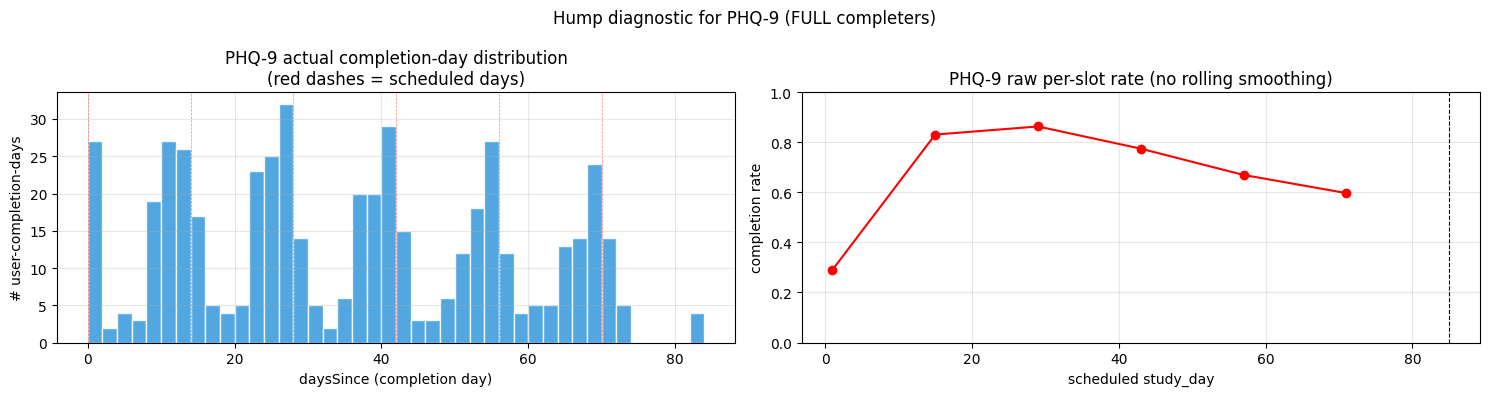

In [44]:
# Diagnostic: is the baseline hump real or an artifact?
# Three tests in increasing order of "this is a calculation bug":
#   1. Raw per-slot rates (un-smoothed) — does the hump exist without the rolling mean?
#   2. Completion-day histogram across baseline — does user behavior actually show a hump?
#   3. Voronoi-cell width audit — does the day-1 cell capture systematically less?

import matplotlib.pyplot as plt
import numpy as np

INST = 'PHQ-9'  # change to inspect a different instrument

sub = df_long[(df_long['instrument'] == INST) &
              (df_long['is_full_completer']) &
              (df_long['period'] == 'baseline')]
raw = (sub.groupby('study_day', observed=True)
          ['completed'].agg(['sum', 'count']).reset_index())
raw['rate'] = raw['sum'] / raw['count']
print(f"Raw per-slot rates for {INST} baseline (FULL completers, n={sub['mm_id'].nunique()}):")
print(raw.to_string(index=False))
print()

# Test 2: completion-day histogram (user behavior, no Voronoi)
# What days did FULL users actually complete PHQ-9 in baseline? If user behavior
# shows a peak around day 30-40, the hump is real. If completion days are uniform,
# the hump is a calculation artifact.
resp_df = INSTRUMENT_MAP[INST]['response_df']
phq9_comp_days = []
for mm_id in df_long.loc[df_long['is_full_completer'], 'mm_id'].unique():
    enroll = enrollment_lookup_v2.get(mm_id)
    if enroll is None or enroll['max_days_since'] is None: continue
    max_ds = enroll['max_days_since']
    user_resp = resp_df[(resp_df['mm_id'] == mm_id) &
                        (resp_df.get('complete', pd.Series(True, index=resp_df.index)) != False)]
    days = {int(d) for d in user_resp['daysSince'].dropna() if 0 <= int(d) <= max_ds and int(d) < 84}
    phq9_comp_days.extend(days)

phq9_comp_days = np.array(phq9_comp_days)
print(f"Distribution of unique completion days across all FULL users (baseline only):")
print(f"  Total completion-day entries: {len(phq9_comp_days):,}")
print(f"  Mean: {phq9_comp_days.mean():.1f}  Median: {np.median(phq9_comp_days):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(phq9_comp_days, bins=np.arange(0, 85, 2), color='#3498db', alpha=0.85, edgecolor='white')
for sd in raw['study_day']:
    axes[0].axvline(sd - 1, color='red', lw=0.5, ls='--', alpha=0.5)
axes[0].set_xlabel('daysSince (completion day)')
axes[0].set_ylabel('# user-completion-days')
axes[0].set_title(f'{INST} actual completion-day distribution\n(red dashes = scheduled days)')
axes[0].grid(alpha=0.3)

axes[1].plot(raw['study_day'], raw['rate'], 'ro-', label='raw per-slot rate')
axes[1].set_xlabel('scheduled study_day')
axes[1].set_ylabel('completion rate')
axes[1].set_title(f'{INST} raw per-slot rate (no rolling smoothing)')
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].axvline(85, color='k', lw=0.8, ls='--')

plt.suptitle(f'Hump diagnostic for {INST} (FULL completers)', fontsize=12)
plt.tight_layout()
plt.show()

# Test 3: Voronoi-cell width audit
# For PHQ-9 biweekly schedule [1, 15, 29, 43, 57, 71] (study_day):
#   day 1's cell: [-inf, 8)  -> clipped to [0, 8)  = 8 days
#   day 15's cell: [8, 22)   = 14 days
#   day 29's cell: [22, 36)  = 14 days
#   day 43's cell: [36, 50)  = 14 days
#   day 57's cell: [50, 64)  = 14 days
#   day 71's cell: [64, 84)  = 20 days   <- extends into period boundary
print()
print("Voronoi-cell widths for PHQ-9 baseline (the structural exposure window per slot):")
slot_dss = sorted(d - 1 for d in sched_days_all[INST]['baseline'])
widths = []
for i, d in enumerate(slot_dss):
    lo = (slot_dss[i-1] + d) / 2 if i > 0 else 0
    hi = (d + slot_dss[i+1]) / 2 if i + 1 < len(slot_dss) else 84
    width = hi - lo
    widths.append(width)
    print(f"  slot daysSince={d:>3} (study_day={d+1:>3}): cell [{lo:.1f}, {hi:.1f})  width = {width:.1f} days")

# If the rate at day 71 is lower than middle slots despite a wider cell, the
# hump shape is REAL user behavior — late-baseline disengagement. If day 71's
# rate scales proportionally with its cell width (compared to middle slots),
# the hump is a Voronoi-width artifact.
print()
print("Calculation-artifact check:")
print("  If hump is just from Voronoi widths, expect rate ∝ cell_width:")
for d, w, r in zip(raw['study_day'], widths, raw['rate']):
    print(f"    day {d:>3}: width={w:>4.1f}d  rate={r:.3f}  rate/width = {r/w:.4f}")
print()
print("  Rate / cell_width should be ~constant if the hump is purely a Voronoi-width effect.")
print("  If rate/width varies systematically (e.g., higher in middle), it's real user behavior.")


## Component B — Descriptive layer

**B.0** (count-based engagement, matches v2/cell-37 logic) is the manuscript descriptive table. **B.1+** use the per-instance binary outcome from `df_long` for visualizations consistent with the inferential models. Rates differ slightly between B.0 and B.1 on monthly-cadence cells due to the binary cap; this is by design.

In [45]:
# Component B.0: Count-based descriptive table (manuscript Table 1)
# Reproduces the v2 / cell-37 'count-based' adherence definition:
#   numerator   = # unique daysSince values with any in-period completion
#   denominator = # scheduled instances in that (period × cadence) range
# This is the *engagement* definition. Does not require per-instance binary
# output, so users who over-complete (e.g., respond weekly while assigned monthly)
# get full credit instead of being capped.
#
# Use this table for the descriptive section of the manuscript. The inferential
# models (M2, M2b, M3) continue to use df_long's per-instance binary, which is
# necessary for fitting per-day slopes but slightly attenuates monthly-cadence
# numerators relative to this table.
#
# Caveat: PHQ-9 adaptive-monthly denominator differs from cell 37 by 124 slots
# (one phantom day-85 slot per FULL completer that cell 37's cell-18 logic
# included but Component A's cell-27 logic correctly excludes — see comment in
# cell 27). All other cells should match cell 37 numbers very closely.

print("=" * 110)
print("COMPONENT B.0 — Count-based descriptive table (matches v2 logic)")
print("=" * 110)

def cadence_at_day(mm_id, instrument, day_ds):
    '''Return assigned cadence at this daysSince for this user/instrument.'''
    user_cfg = config_by_user.get(mm_id, [])
    for cfg in reversed(user_cfg):
        if cfg['study_day'] <= day_ds + 1:
            return cfg.get(instrument)
    return None

count_rows = []
for instrument, info in INSTRUMENT_MAP.items():
    resp_df = info['response_df']
    if 'daysSince' not in resp_df.columns:
        continue
    comp_by_user = (
        resp_df[resp_df.get('complete', pd.Series(True, index=resp_df.index)) != False]
        .dropna(subset=['daysSince', 'mm_id'])
        .assign(_d=lambda d: d['daysSince'].astype(int))
        .groupby('mm_id')['_d'].apply(set).to_dict()
    )
    for mm_id, enroll in enrollment_lookup_v2.items():
        if enroll['status'] in EXCLUDED_STATUSES: continue
        if enroll['max_days_since'] is None: continue
        max_ds = enroll['max_days_since']
        user_days = {c for c in comp_by_user.get(mm_id, set()) if 0 <= c <= max_ds}

        baseline_comp = sum(1 for d in user_days if d < 84)
        weekly_comp   = sum(1 for d in user_days
                            if d >= 84 and cadence_at_day(mm_id, instrument, d) == 'weekly')
        monthly_comp  = sum(1 for d in user_days
                            if d >= 84 and cadence_at_day(mm_id, instrument, d) == 'monthly')

        user_long = df_long[(df_long['mm_id'] == mm_id) & (df_long['instrument'] == instrument)]
        baseline_exp = int((user_long['period'] == 'baseline').sum())
        weekly_exp   = int(((user_long['period'] == 'adaptive') &
                            (user_long['assigned_cadence'] == 'weekly')).sum())
        monthly_exp  = int(((user_long['period'] == 'adaptive') &
                            (user_long['assigned_cadence'] == 'monthly')).sum())

        count_rows.append({
            'mm_id': mm_id, 'instrument': instrument, 'arm': arm_of(mm_id),
            'is_full': mm_id in full_ids,
            'baseline_comp': baseline_comp, 'baseline_exp': baseline_exp,
            'weekly_comp':   weekly_comp,   'weekly_exp':   weekly_exp,
            'monthly_comp':  monthly_comp,  'monthly_exp':  monthly_exp,
        })

df_count = pd.DataFrame(count_rows)
df_count['overall_comp'] = df_count['baseline_comp'] + df_count['weekly_comp'] + df_count['monthly_comp']
df_count['overall_exp']  = df_count['baseline_exp']  + df_count['weekly_exp']  + df_count['monthly_exp']

def fmt(c, e):
    return f"{int(c)}/{int(e)} ({c/e*100:.1f}%)" if e else "0/0"

DISPLAY_ORDER = ['PHQ-9', 'ASRM', 'OASIS', 'EMDISTRESS', 'FAS', 'PSQI', 'PQ-B']

df_full = df_count[df_count['is_full']]
print(f"\nFULL completers (n={df_full['mm_id'].nunique()}) — pooled across arms")
print("-" * 110)
print(f"{'Instrument':<12}  {'Overall':>22}  {'Baseline':>22}  {'Adap-Weekly':>22}  {'Adap-Monthly':>22}")
print("-" * 110)
for inst in DISPLAY_ORDER:
    sub = df_full[df_full['instrument'] == inst]
    if sub.empty: continue
    print(f"{inst:<12}  "
          f"{fmt(sub['overall_comp'].sum(),  sub['overall_exp'].sum()):>22}  "
          f"{fmt(sub['baseline_comp'].sum(), sub['baseline_exp'].sum()):>22}  "
          f"{fmt(sub['weekly_comp'].sum(),   sub['weekly_exp'].sum()):>22}  "
          f"{fmt(sub['monthly_comp'].sum(),  sub['monthly_exp'].sum()):>22}")

print()
print("FULL completers — by arm")
print("-" * 130)
print(f"{'Instrument':<12}  {'Arm':<12}  {'Overall':>22}  {'Baseline':>22}  {'Adap-Weekly':>22}  {'Adap-Monthly':>22}")
print("-" * 130)
for inst in DISPLAY_ORDER:
    for arm_label in ['Supported', 'Unsupported']:
        sub = df_full[(df_full['instrument'] == inst) & (df_full['arm'] == arm_label)]
        if sub.empty: continue
        print(f"{inst if arm_label == 'Supported' else '':<12}  "
              f"{arm_label:<12}  "
              f"{fmt(sub['overall_comp'].sum(),  sub['overall_exp'].sum()):>22}  "
              f"{fmt(sub['baseline_comp'].sum(), sub['baseline_exp'].sum()):>22}  "
              f"{fmt(sub['weekly_comp'].sum(),   sub['weekly_exp'].sum()):>22}  "
              f"{fmt(sub['monthly_comp'].sum(),  sub['monthly_exp'].sum()):>22}")

print()
print(f"mITT cohort (n={df_count['mm_id'].nunique()}) — pooled across arms")
print("-" * 110)
print(f"{'Instrument':<12}  {'Overall':>22}  {'Baseline':>22}  {'Adap-Weekly':>22}  {'Adap-Monthly':>22}")
print("-" * 110)
for inst in DISPLAY_ORDER:
    sub = df_count[df_count['instrument'] == inst]
    if sub.empty: continue
    print(f"{inst:<12}  "
          f"{fmt(sub['overall_comp'].sum(),  sub['overall_exp'].sum()):>22}  "
          f"{fmt(sub['baseline_comp'].sum(), sub['baseline_exp'].sum()):>22}  "
          f"{fmt(sub['weekly_comp'].sum(),   sub['weekly_exp'].sum()):>22}  "
          f"{fmt(sub['monthly_comp'].sum(),  sub['monthly_exp'].sum()):>22}")

print()
print("Note: this is the count-based descriptive definition (engagement). The per-instance")
print("binary version in B.1 is used for inferential models — small differences are expected,")
print("particularly on adaptive-monthly cells where engaged users contribute 2+ completions")
print("per scheduled monthly prompt.")

COMPONENT B.0 — Count-based descriptive table (matches v2 logic)

FULL completers (n=124) — pooled across arms
--------------------------------------------------------------------------------------------------------------
Instrument                   Overall                Baseline             Adap-Weekly            Adap-Monthly
--------------------------------------------------------------------------------------------------------------
PHQ-9              1126/1823 (61.8%)         499/744 (67.1%)         328/588 (55.8%)         299/491 (60.9%)
ASRM               1436/2164 (66.4%)       1070/1488 (71.9%)           36/75 (48.0%)         330/601 (54.9%)
OASIS              1853/2734 (67.8%)       1069/1488 (71.8%)         502/800 (62.7%)         282/446 (63.2%)
EMDISTRESS         1655/2458 (67.3%)       1099/1488 (73.9%)         218/449 (48.6%)         338/521 (64.9%)
FAS                1838/2915 (63.1%)       1059/1612 (65.7%)         498/878 (56.7%)         281/425 (66.1%)
PSQI         

In [46]:
# Component B.1: Adherence summary table with Wilson 95% CI
# Per (instrument × period × cadence). Reported on TWO cohorts:
#   * mITT (primary, n=263): all enrolled, not WITHDREW/DROP OUT
#   * FULL completers (sensitivity, n=124): retained ≥8 months
# Wilson score interval for proportions (handles small Ns and rates near 0/1).

from statsmodels.stats.proportion import proportion_confint

def fmt_rate(k, n):
    # k may now exceed n (count outcome with multi-completion clustering on monthly
    # cadence). Wilson CI requires 0 ≤ k ≤ n, so we clip k for the CI computation
    # while reporting the true rate (which can exceed 100%).
    if n == 0:
        return '-- (0)'
    p = k / n
    k_for_ci = min(k, n)
    lo, hi = proportion_confint(k_for_ci, n, alpha=0.05, method='wilson')
    return f"{p*100:.1f}% [{lo*100:.1f}, {hi*100:.1f}]  (n={n})"

B1_COHORTS = {
    'mITT':  df_long,
    'FULL':  df_long[df_long['is_full_completer']],
}

for label, source in B1_COHORTS.items():
    n_part = source['mm_id'].nunique()
    print("=" * 100)
    print(f"COMPONENT B.1 — Adherence rate (Wilson 95% CI)  |  {label} (n={n_part})  |  by arm")
    print("=" * 100)
    summary = (source
        .groupby(['instrument', 'period', 'assigned_cadence', 'arm'], observed=True)
        ['completed'].agg(['sum', 'count']).reset_index()
        .rename(columns={'sum': 'k', 'count': 'n'}))
    summary['rate_str'] = summary.apply(lambda r: fmt_rate(int(r['k']), int(r['n'])), axis=1)
    pivot = summary.pivot_table(
        index=['instrument', 'period', 'assigned_cadence'],
        columns='arm', values='rate_str', aggfunc='first', observed=True)
    print(pivot.fillna('--'))

    pooled = (source
        .groupby(['instrument', 'period', 'assigned_cadence'], observed=True)
        ['completed'].agg(['sum', 'count']).reset_index())
    pooled['rate'] = pooled.apply(lambda r: fmt_rate(int(r['sum']), int(r['count'])), axis=1)
    print(f"\nPooled across arms ({label}):")
    print(pooled.pivot_table(index='instrument',
                             columns=['period', 'assigned_cadence'],
                             values='rate', aggfunc='first', observed=True).fillna('--'))
    print()

COMPONENT B.1 — Adherence rate (Wilson 95% CI)  |  mITT (n=263)  |  by arm
arm                                                      Supported                   Unsupported
instrument period   assigned_cadence                                                            
PHQ-9      baseline biweekly           58.7% [55.2, 62.2]  (n=744)   49.3% [45.8, 52.7]  (n=816)
           adaptive weekly             63.1% [58.0, 67.9]  (n=360)   48.3% [42.3, 54.3]  (n=263)
                    monthly            74.6% [69.1, 79.3]  (n=279)   40.8% [34.9, 46.9]  (n=255)
ASRM       baseline biweekly          62.9% [60.4, 65.3]  (n=1471)  45.5% [43.1, 48.0]  (n=1632)
           adaptive weekly              60.3% [47.5, 71.9]  (n=58)     20.0% [8.9, 39.1]  (n=25)
                    monthly            64.4% [59.2, 69.3]  (n=340)   43.5% [38.1, 49.1]  (n=308)
OASIS      baseline biweekly          61.3% [58.8, 63.8]  (n=1467)  46.6% [44.2, 49.0]  (n=1632)
           adaptive weekly             66.7% [62.5, 

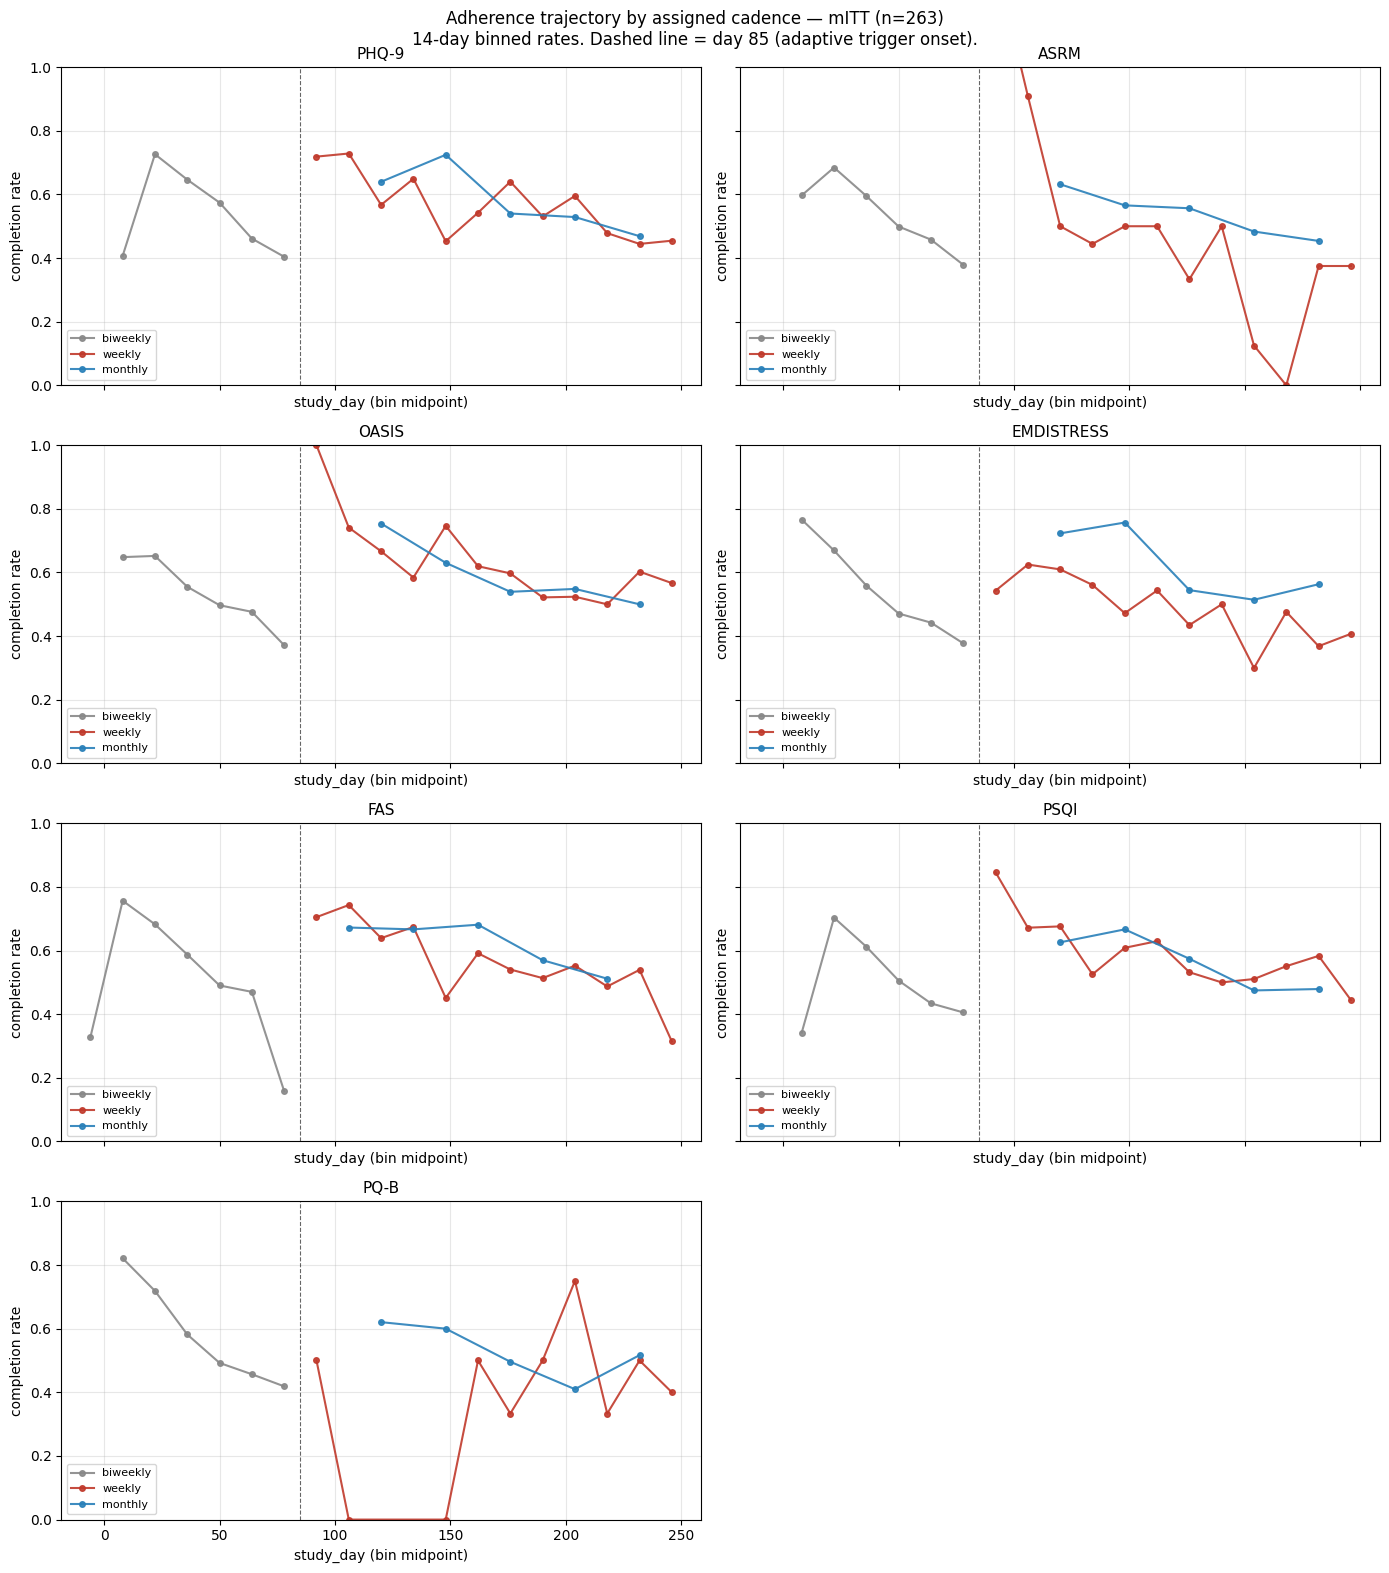

In [47]:
# Component B.2: Adherence trajectory by cadence (14-day binned rates)
# X: bin midpoint (study day). Y: cohort completion rate within bin.
# Each bin aggregates sum(completed)/count(rows) across the 14 days inside it,
# giving more stable rates than per-slot raw values for low-N cells.

BIN_WIDTH = 14

# Period-aware binning: baseline bins anchored at day 1, adaptive bins anchored
# at day 85. Prevents instruments whose baseline schedule extends to day 84
# (FAS et al.) from sharing a bin with early adaptive slots.
dfl = df_long.copy()
dfl['bin'] = np.where(
    dfl['period'] == 'baseline',
    ((dfl['study_day'] - 1) // BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH // 2 + 1,
    ((dfl['study_day'] - 85) // BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH // 2 + 85,
).astype(int)

g = (dfl.groupby(['instrument', 'bin', 'assigned_cadence'], observed=True)
        ['completed'].agg(['sum', 'count']).reset_index())
g['rate'] = g['sum'] / g['count']
g = g.sort_values(['instrument', 'assigned_cadence', 'bin'])

instruments = list(df_long['instrument'].cat.categories)
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True, sharey=True)
axes = axes.flatten()
cadence_colors = {'biweekly': '#888', 'weekly': '#c0392b', 'monthly': '#2980b9'}

for ax, inst in zip(axes, instruments):
    sub = g[g['instrument'] == inst]
    for cad, c in cadence_colors.items():
        s = sub[sub['assigned_cadence'] == cad]
        if not s.empty:
            ax.plot(s['bin'], s['rate'], color=c, label=cad, lw=1.5,
                    marker='o', markersize=4, alpha=0.9)
    ax.axvline(85, color='k', lw=0.8, ls='--', alpha=0.6)
    ax.set_title(inst, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_xlabel('study_day (bin midpoint)')
    ax.set_ylabel('completion rate')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(alpha=0.3)

for ax in axes[len(instruments):]:
    ax.set_visible(False)

fig.suptitle(f'Adherence trajectory by assigned cadence — mITT (n=263)\n'
             f'{BIN_WIDTH}-day binned rates. Dashed line = day 85 (adaptive trigger onset).',
             fontsize=12)
fig.tight_layout()
plt.show()

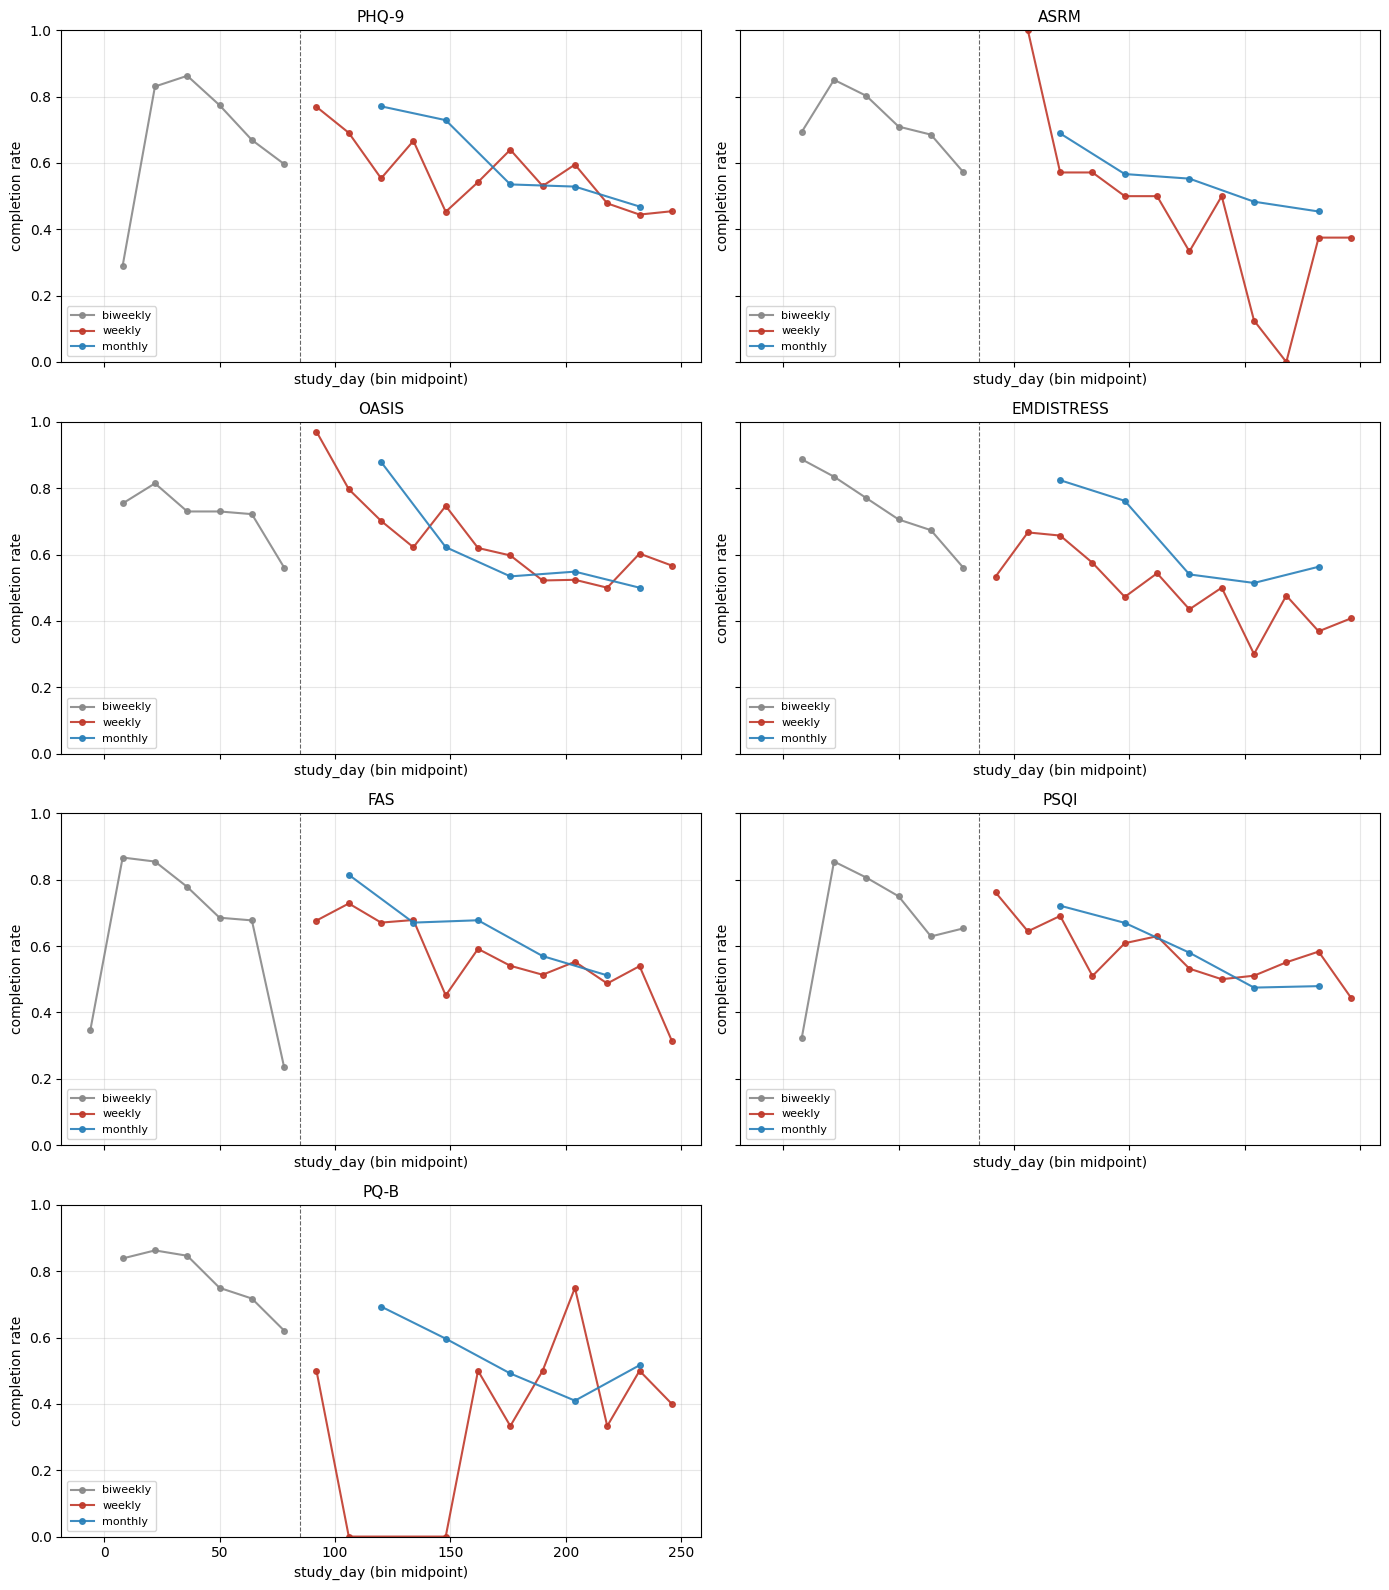

In [48]:

BIN_WIDTH = 14

df_long_full = df_long[df_long['is_full_completer']].copy()
df_long_full['bin'] = np.where(
    df_long_full['period'] == 'baseline',
    ((df_long_full['study_day'] - 1) // BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH // 2 + 1,
    ((df_long_full['study_day'] - 85) // BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH // 2 + 85,
).astype(int)

g_full = (df_long_full
          .groupby(['instrument', 'bin', 'assigned_cadence'], observed=True)
          ['completed'].agg(['sum', 'count']).reset_index())
g_full['rate'] = g_full['sum'] / g_full['count']
g_full = g_full.sort_values(['instrument', 'assigned_cadence', 'bin'])

instruments = list(df_long['instrument'].cat.categories)
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True, sharey=True)
axes = axes.flatten()
cadence_colors = {'biweekly': '#888', 'weekly': '#c0392b', 'monthly': '#2980b9'}

for ax, inst in zip(axes, instruments):
    sub = g_full[g_full['instrument'] == inst]
    for cad, c in cadence_colors.items():
        s = sub[sub['assigned_cadence'] == cad]
        if not s.empty:
            ax.plot(s['bin'], s['rate'], color=c, label=cad, lw=1.5,
                    marker='o', markersize=4, alpha=0.9)
    ax.axvline(85, color='k', lw=0.8, ls='--', alpha=0.6)
    ax.set_title(inst, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_xlabel('study_day (bin midpoint)')
    ax.set_ylabel('completion rate')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(alpha=0.3)

for ax in axes[len(instruments):]:
    ax.set_visible(False)

n_full = df_long_full['mm_id'].nunique()
# fig.suptitle(f'Adherence trajectory by assigned cadence — FULL completers (n={n_full})\n'
#              f'{BIN_WIDTH}-day binned rates. Dashed line = day 85 (adaptive trigger onset).',
            #  fontsize=12)
fig.tight_layout()
plt.show()

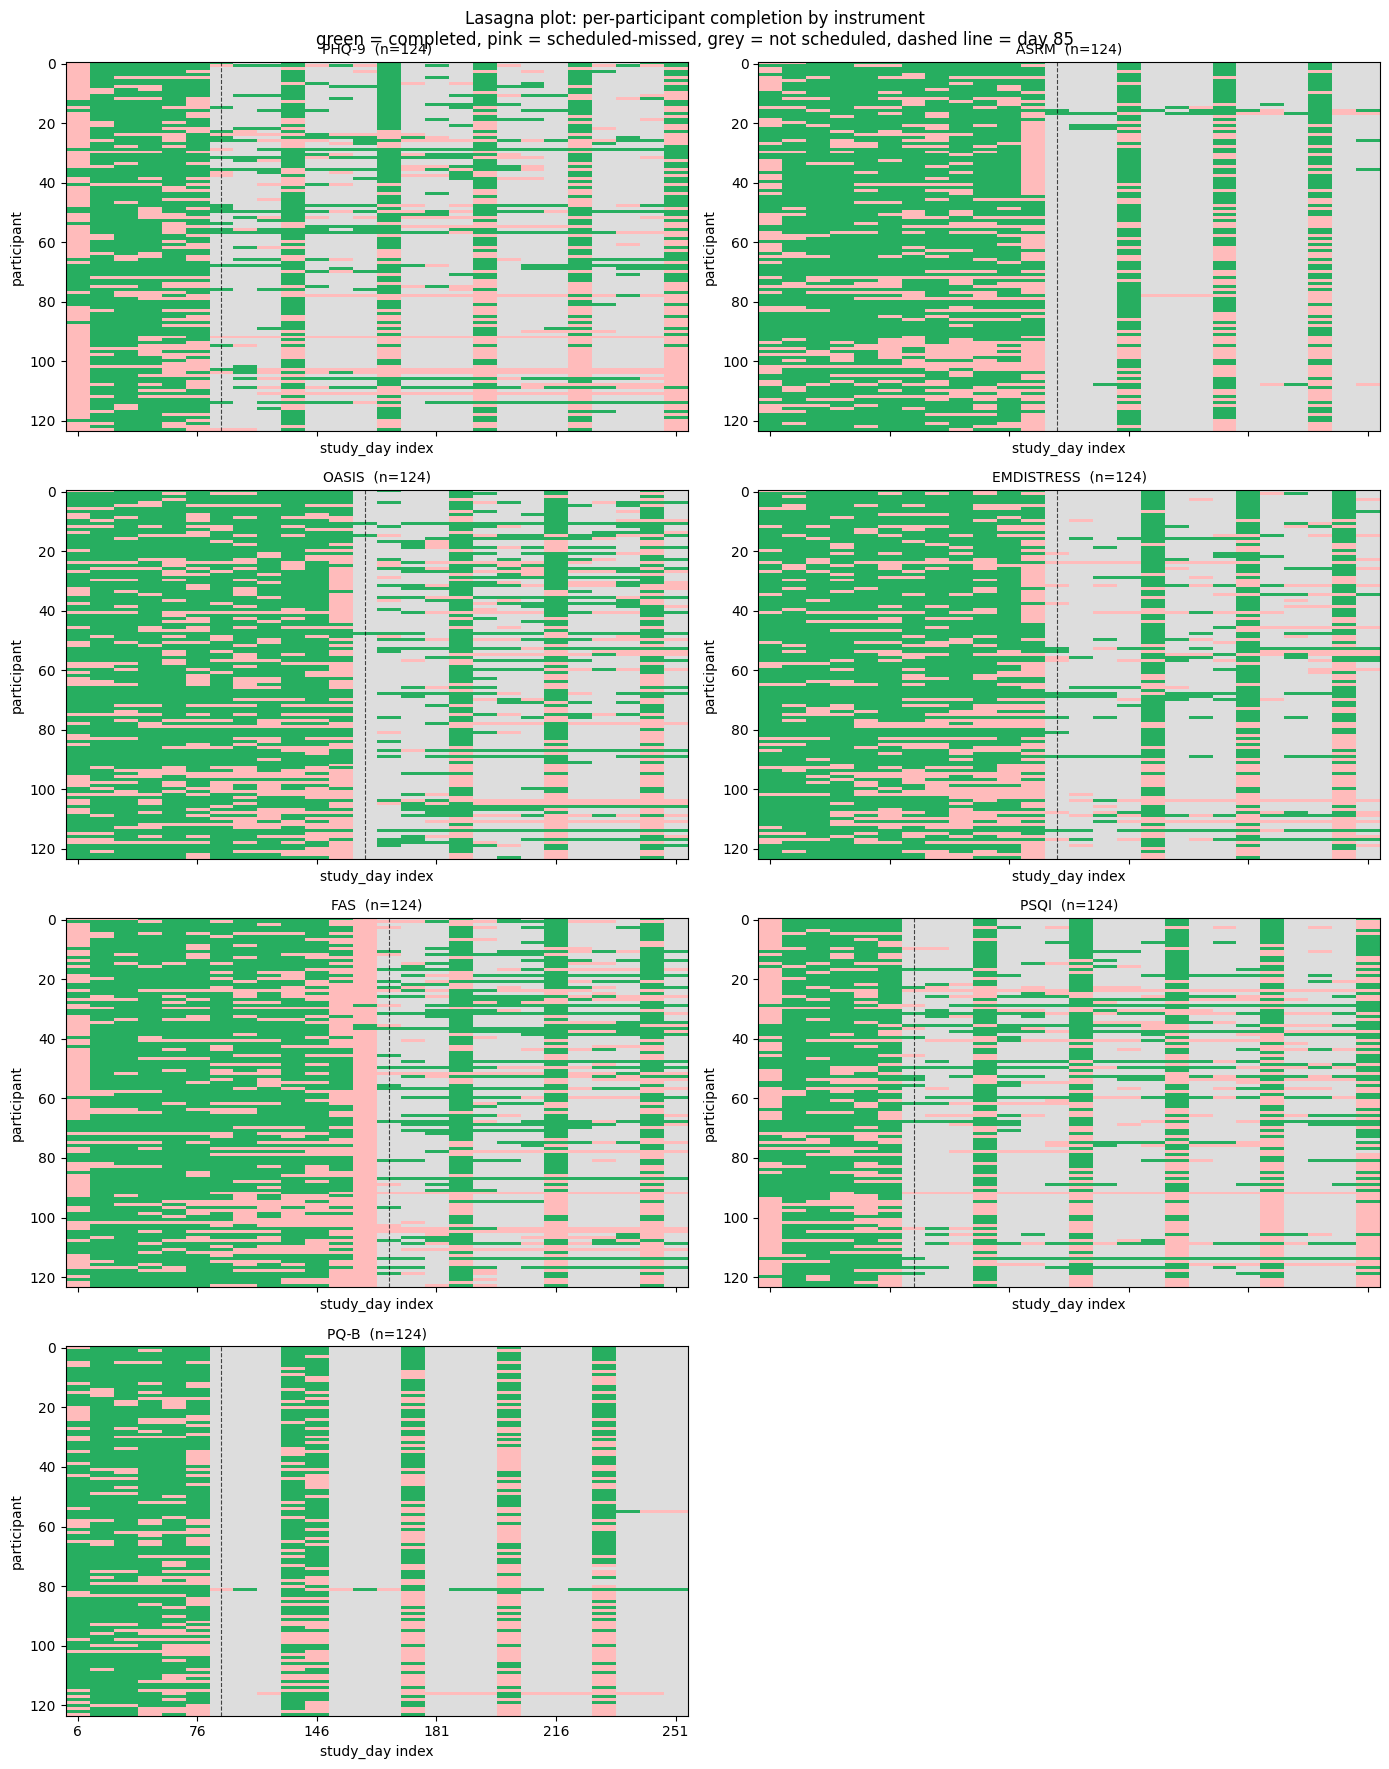

In [49]:
# Component B.3: Lasagna plot (per-participant completion heatmap)
# Rows = participants (sorted by enrollment date), columns = study_day, color = completed.
# One panel per instrument. Cadence transitions overlaid as thin vertical marks per row.

from matplotlib.colors import ListedColormap

enroll_order = (df_enrollment[['mm_id', '4YAM Enroll']]
                .dropna()
                .assign(d=lambda d: pd.to_datetime(d['4YAM Enroll']))
                .sort_values('d')['mm_id'].tolist())

instruments = list(df_long['instrument'].cat.categories)
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True)
axes = axes.flatten()

for ax, inst in zip(axes, instruments):
    sub = df_long[(df_long['instrument'] == inst) & (df_long['is_full_completer'])]
    pivot = sub.pivot_table(index='mm_id', columns='study_day',
                            values='completed', aggfunc='max')
    rows_in_order = [u for u in enroll_order if u in pivot.index]
    pivot = pivot.reindex(rows_in_order)

    cmap = ListedColormap(['#dddddd', '#fbb', '#27ae60'])
    show = pivot.copy()
    show = show.fillna(-1)  # -1 -> not scheduled
    im = ax.imshow(show.values, aspect='auto', interpolation='nearest', cmap=cmap,
                   vmin=-1, vmax=1)
    ax.axvline(np.searchsorted(pivot.columns, 85) if 85 in pivot.columns
               else (pivot.columns < 85).sum(),
               color='k', lw=0.8, ls='--', alpha=0.7)
    ax.set_title(f'{inst}  (n={len(pivot)})', fontsize=10)
    ax.set_xlabel('study_day index')
    ax.set_ylabel('participant')
    n_cols = pivot.shape[1]
    if n_cols > 0:
        tick_idx = np.linspace(0, n_cols - 1, 6).astype(int)
        ax.set_xticks(tick_idx)
        ax.set_xticklabels(pivot.columns[tick_idx])

for ax in axes[len(instruments):]:
    ax.set_visible(False)

fig.suptitle('Lasagna plot: per-participant completion by instrument\n'
             'green = completed, pink = scheduled-missed, grey = not scheduled, '
             'dashed line = day 85', fontsize=12)
fig.tight_layout()
plt.show()

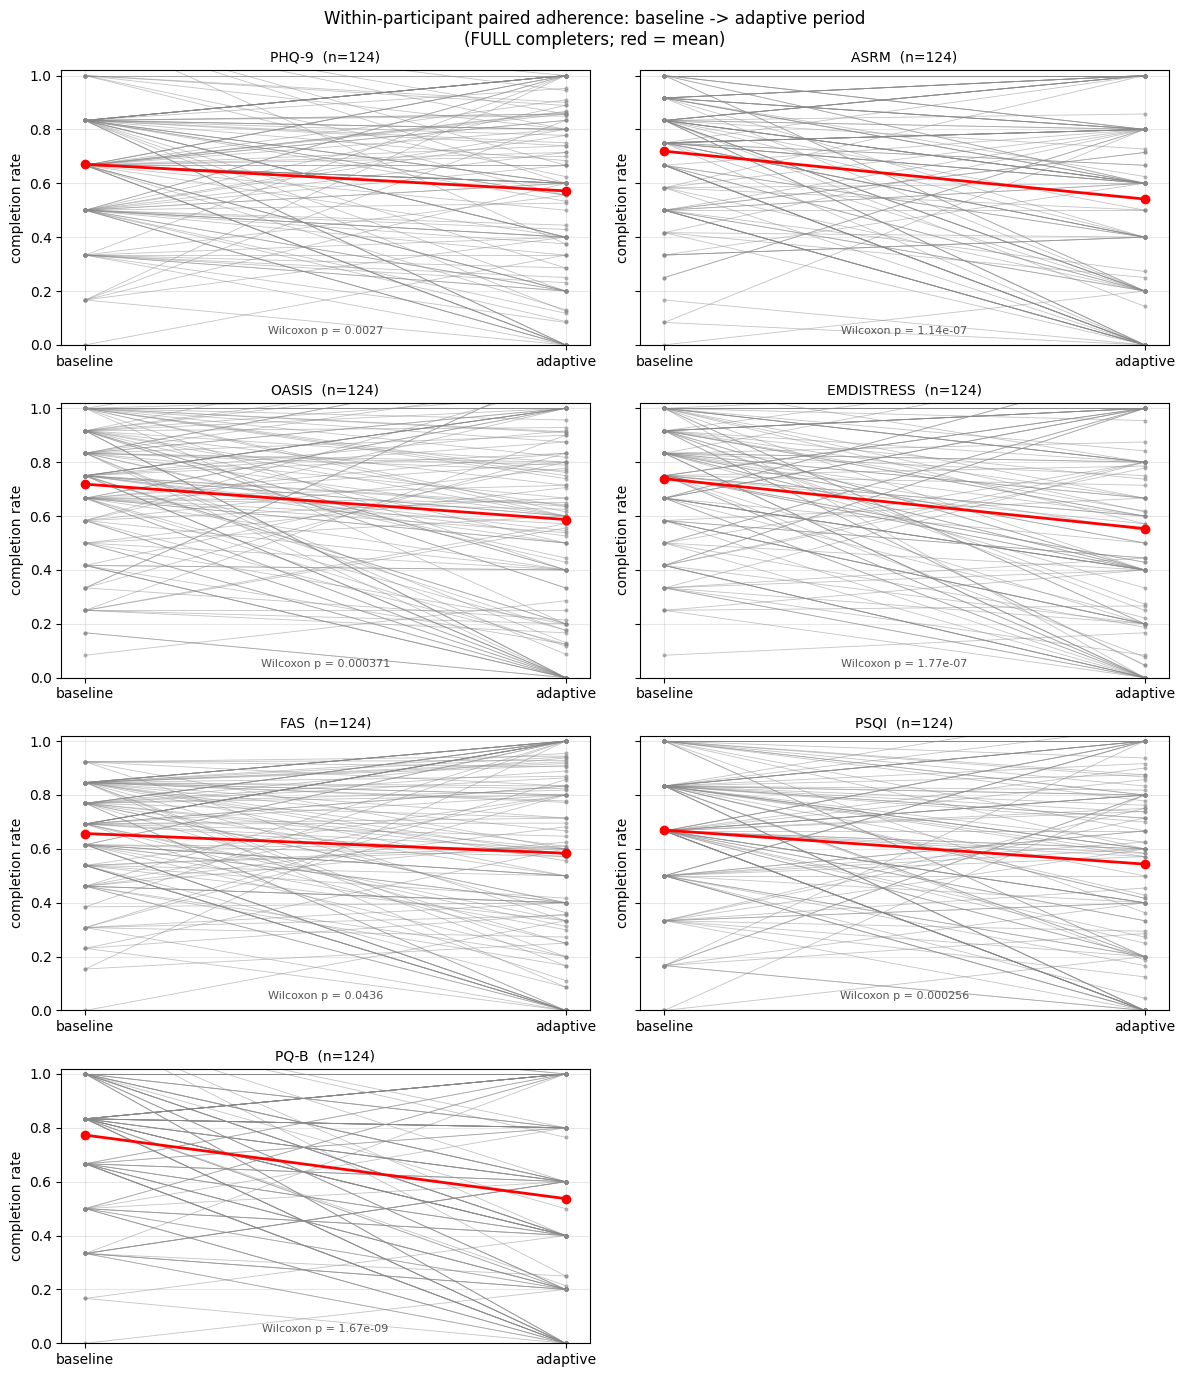

In [50]:
# Component B.4: Within-participant paired plot (baseline -> adaptive)
# Per participant, compute baseline-period adherence vs adaptive-period adherence,
# connect with a line. Faceted by instrument.

def per_user_rate(df_):
    return (df_.groupby(['mm_id', 'instrument', 'period'], observed=True)
              ['completed'].agg(['sum', 'count']).assign(rate=lambda d: d['sum']/d['count'])
              .reset_index())

paired = per_user_rate(df_long[df_long['is_full_completer']])

instruments = list(df_long['instrument'].cat.categories)
fig, axes = plt.subplots(4, 2, figsize=(12, 14), sharey=True)
axes = axes.flatten()

for ax, inst in zip(axes, instruments):
    sub = paired[paired['instrument'] == inst]
    wide = sub.pivot_table(index='mm_id', columns='period', values='rate', observed=True)
    if 'baseline' not in wide.columns or 'adaptive' not in wide.columns:
        ax.set_visible(False); continue
    wide = wide.dropna(subset=['baseline', 'adaptive'])
    for _, r in wide.iterrows():
        ax.plot([0, 1], [r['baseline'], r['adaptive']],
                color='#888', lw=0.6, alpha=0.5, marker='o', ms=2)
    means = wide.mean()
    ax.plot([0, 1], [means['baseline'], means['adaptive']], 'r-o', lw=2, ms=6, label='mean')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['baseline', 'adaptive'])
    ax.set_ylim(0, 1.02)
    ax.set_title(f"{inst}  (n={len(wide)})", fontsize=10)
    ax.set_ylabel('completion rate')
    ax.grid(alpha=0.3)
    from scipy.stats import wilcoxon
    if len(wide) >= 5:
        try:
            w_stat, w_p = wilcoxon(wide['baseline'], wide['adaptive'], zero_method='wilcox')
            ax.text(0.5, 0.04, f"Wilcoxon p = {w_p:.3g}", transform=ax.transAxes,
                    ha='center', fontsize=8, color='#555')
        except Exception:
            pass

for ax in axes[len(instruments):]:
    ax.set_visible(False)

fig.suptitle('Within-participant paired adherence: baseline -> adaptive period\n'
             '(FULL completers; red = mean)', fontsize=12)
fig.tight_layout()
plt.show()

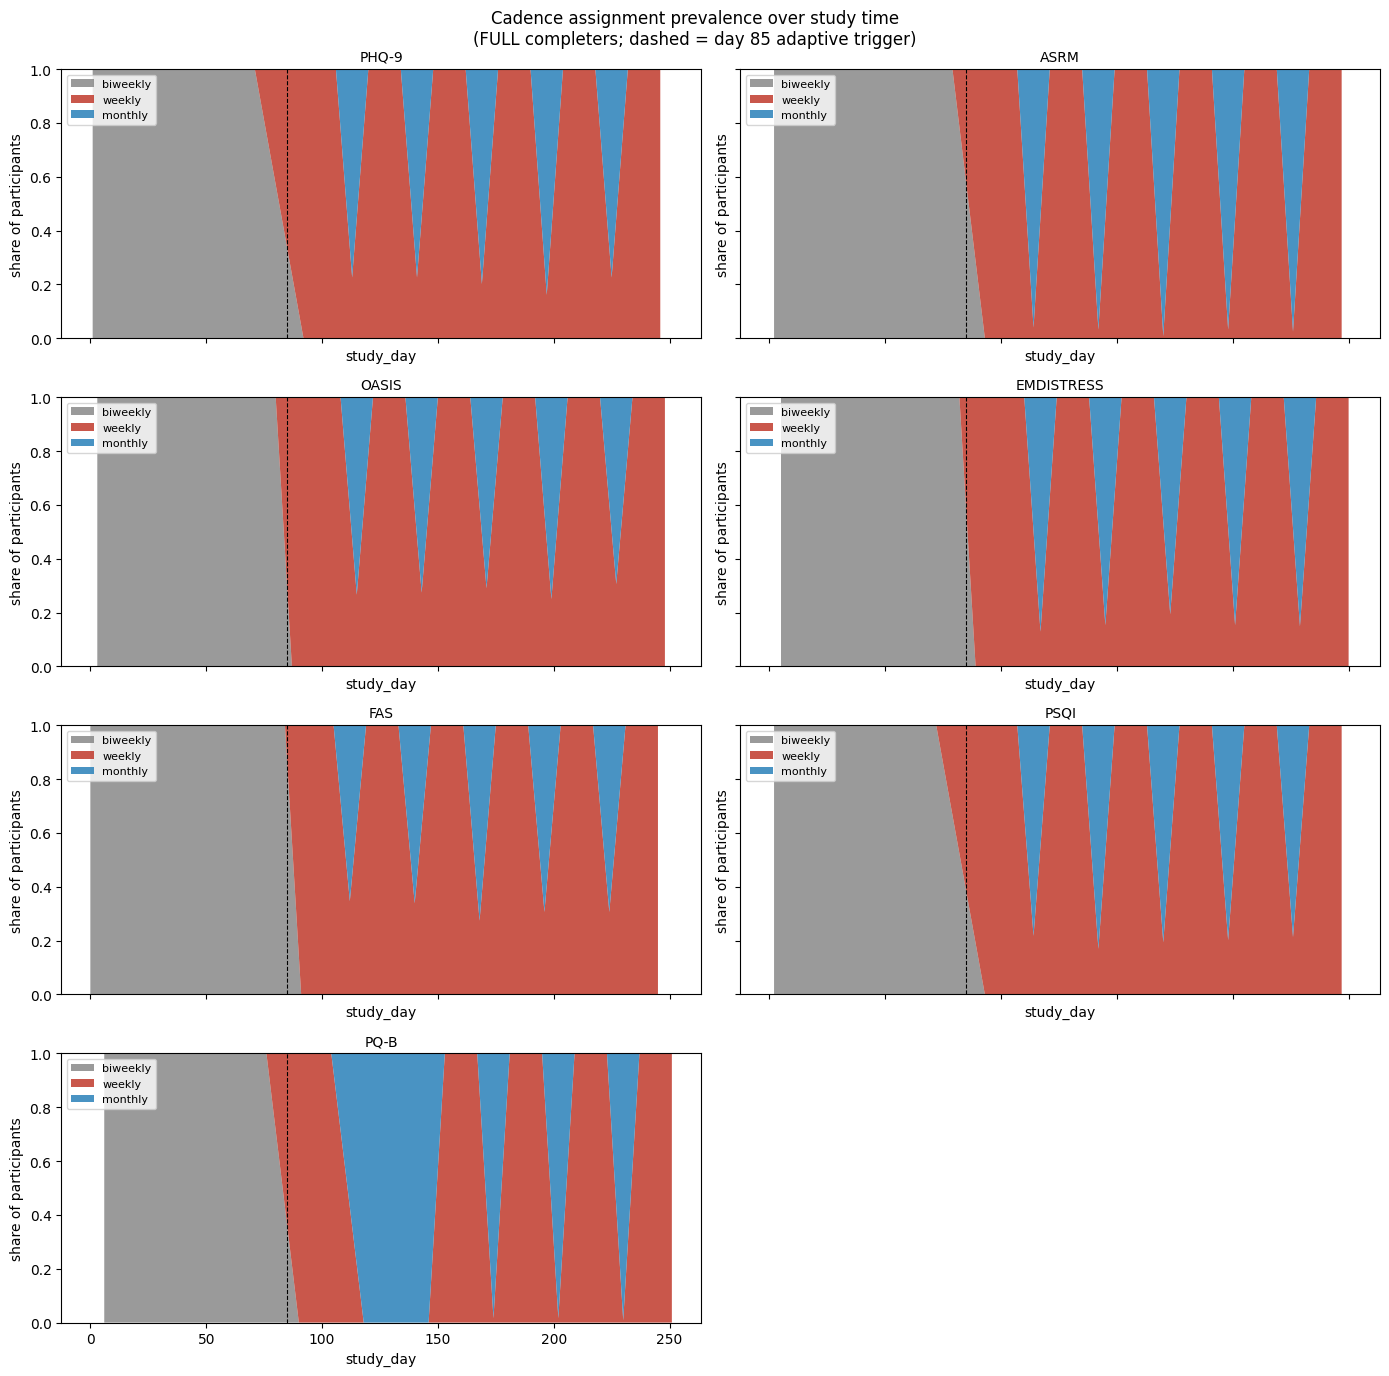

In [51]:
# Component B.5: Cadence-prevalence over study time
# Stacked area: fraction of FULL-completer participants on each cadence by study_day.
# One panel per instrument.

instruments = list(df_long['instrument'].cat.categories)
fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True, sharey=True)
axes = axes.flatten()

for ax, inst in zip(axes, instruments):
    sub = df_long[(df_long['instrument'] == inst) & df_long['is_full_completer']]
    by_day = (sub.groupby(['study_day', 'assigned_cadence'], observed=True)
                 ['mm_id'].nunique()
                 .unstack(fill_value=0))
    if by_day.empty:
        ax.set_visible(False); continue
    by_day = by_day.div(by_day.sum(axis=1), axis=0)
    by_day = by_day.reindex(columns=['biweekly', 'weekly', 'monthly'], fill_value=0)
    ax.stackplot(by_day.index, by_day['biweekly'], by_day['weekly'], by_day['monthly'],
                 labels=['biweekly', 'weekly', 'monthly'],
                 colors=['#888', '#c0392b', '#2980b9'], alpha=0.85)
    ax.axvline(85, color='k', lw=0.8, ls='--')
    ax.set_title(inst, fontsize=10)
    ax.set_xlabel('study_day'); ax.set_ylabel('share of participants')
    ax.set_ylim(0, 1); ax.legend(fontsize=8, loc='upper left')

for ax in axes[len(instruments):]:
    ax.set_visible(False)

fig.suptitle('Cadence assignment prevalence over study time\n'
             '(FULL completers; dashed = day 85 adaptive trigger)', fontsize=12)
fig.tight_layout()
plt.show()

BURDEN COMPARISON — adaptive vs counterfactual fixed (cohort totals)
instrument  n_participants  interval_d  median_observed  median_counterfactual  total_observed  total_counterfactual  burden_change_pct  median_change
     PHQ-9             124          14              6.0                   11.0            1079                  1359              -20.6           -5.0
      ASRM             124           7              5.0                   23.0             676                  2817              -76.0          -18.0
     OASIS             124           7              8.0                   23.0            1246                  2817              -55.8          -15.0
EMDISTRESS             124           7              5.0                   23.0             970                  2817              -65.6          -18.0
       FAS             124           7              7.0                   23.0            1303                  2817              -53.7          -16.0
      PSQI             12

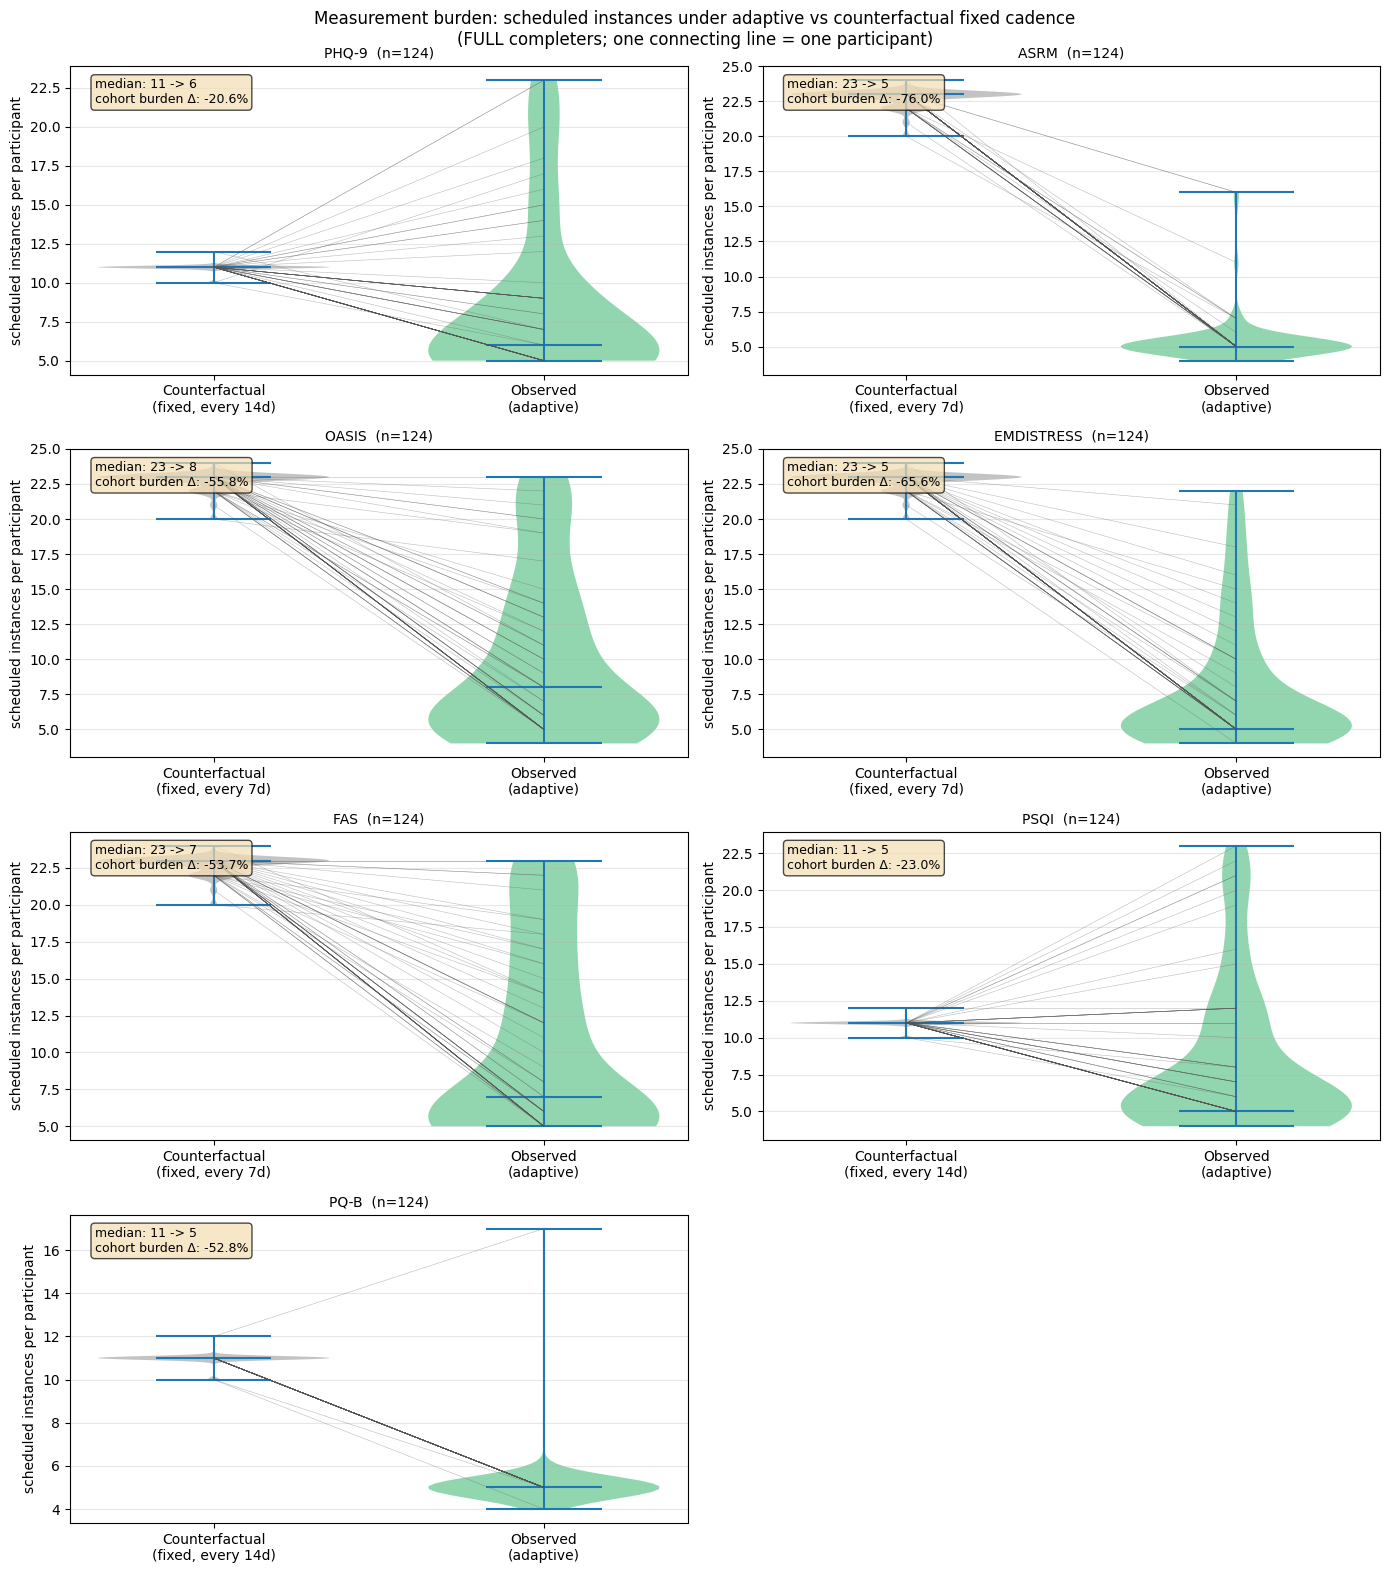

In [52]:
# Component B.6: Measurement burden — adaptive vs counterfactual fixed
# Per participant per instrument: how many scheduled instances fell in the adaptive
# window (study days 85–4YAM End) under (i) the observed adaptive cadence vs
# (ii) a counterfactual world where the baseline cadence (whatever each instrument
# was doing days 1–84) had simply continued.
#
# Counterfactual interval is computed as the median spacing between consecutive
# baseline scheduled days for each instrument (e.g. PHQ-9 biweekly = 14d,
# ASRM weekly = 7d). The visual answers: did adaptive logic *reduce* burden vs
# the originally-planned fixed schedule?

BASELINE_INTERVALS = {}
for inst in INSTRUMENT_MAP:
    bl = sched_days_all[inst]['baseline']
    BASELINE_INTERVALS[inst] = int(np.median(np.diff(bl))) if len(bl) >= 2 else 7

burden_rows = []
for mm_id, info in enrollment_lookup_v2.items():
    if info['status'] in EXCLUDED_STATUSES or info['max_days_since'] is None:
        continue
    if mm_id not in full_ids:
        continue
    max_ds = info['max_days_since']
    adaptive_days = max(0, max_ds - 84)

    user_long = df_long[(df_long['mm_id'] == mm_id) & (df_long['period'] == 'adaptive')]
    for inst, interval in BASELINE_INTERVALS.items():
        sub = user_long[user_long['instrument'] == inst]
        observed_n = len(sub)
        observed_done = int(sub['completed'].sum())
        cf_n = adaptive_days // interval if interval > 0 else 0
        burden_rows.append({
            'mm_id': mm_id,
            'instrument': inst,
            'arm': arm_of(mm_id),
            'observed_scheduled': observed_n,
            'counterfactual_scheduled': cf_n,
            'observed_completed': observed_done,
            'baseline_interval_d': interval,
        })

df_burden = pd.DataFrame(burden_rows)
df_burden['instrument'] = pd.Categorical(
    df_burden['instrument'],
    categories=list(df_long['instrument'].cat.categories), ordered=True
)

instruments = list(df_long['instrument'].cat.categories)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, inst in zip(axes, instruments):
    sub = df_burden[df_burden['instrument'] == inst]
    if sub.empty:
        ax.set_visible(False); continue

    parts = ax.violinplot(
        [sub['counterfactual_scheduled'], sub['observed_scheduled']],
        positions=[0, 1], widths=0.7, showmedians=True
    )
    for pc, color in zip(parts['bodies'], ['#888', '#27ae60']):
        pc.set_facecolor(color); pc.set_alpha(0.5)

    sample = sub.sample(min(len(sub), 60), random_state=42)
    for _, r in sample.iterrows():
        ax.plot([0, 1], [r['counterfactual_scheduled'], r['observed_scheduled']],
                color='#555', lw=0.4, alpha=0.4)

    med_obs = sub['observed_scheduled'].median()
    med_cf = sub['counterfactual_scheduled'].median()
    burden_pct = (sub['observed_scheduled'].sum() / sub['counterfactual_scheduled'].sum() - 1) * 100 \
                 if sub['counterfactual_scheduled'].sum() else np.nan
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'Counterfactual\n(fixed, every {sub["baseline_interval_d"].iloc[0]}d)',
                        'Observed\n(adaptive)'])
    ax.set_ylabel('scheduled instances per participant')
    ax.set_title(f'{inst}  (n={len(sub)})', fontsize=10)
    ax.text(0.04, 0.96,
            f'median: {med_cf:.0f} -> {med_obs:.0f}\n'
            f'cohort burden Δ: {burden_pct:+.1f}%',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    ax.grid(alpha=0.3, axis='y')

for ax in axes[len(instruments):]:
    ax.set_visible(False)

fig.suptitle('Measurement burden: scheduled instances under adaptive vs counterfactual fixed cadence\n'
             '(FULL completers; one connecting line = one participant)', fontsize=12)
fig.tight_layout()
plt.show()

print("=" * 90)
print("BURDEN COMPARISON — adaptive vs counterfactual fixed (cohort totals)")
print("=" * 90)
summary = df_burden.groupby('instrument', observed=True).agg(
    n_participants=('mm_id', 'count'),
    interval_d=('baseline_interval_d', 'first'),
    median_observed=('observed_scheduled', 'median'),
    median_counterfactual=('counterfactual_scheduled', 'median'),
    total_observed=('observed_scheduled', 'sum'),
    total_counterfactual=('counterfactual_scheduled', 'sum'),
).reset_index()
summary['burden_change_pct'] = np.where(
    summary['total_counterfactual'] > 0,
    (summary['total_observed'] / summary['total_counterfactual'] - 1) * 100,
    np.nan
)
summary['median_change'] = summary['median_observed'] - summary['median_counterfactual']
print(summary.to_string(index=False, float_format=lambda x: f'{x:.1f}'))

print()
print("Interpretation: negative burden_change_pct = adaptive sent FEWER scheduled prompts")
print("than the counterfactual fixed schedule would have. Positive = adaptive sent more.")

## Component C — Inferential models

**Primary:** segmented GEE with knot at day 85 (M2) + g-computed pp effect (M3).

**Secondary:** sIPTW-weighted cadence comparison (M1b), period × arm moderation (M2b).

### Primary — Segmented GEE (interrupted time series)

In [53]:
# PRIMARY — Model 2: Segmented GEE with knot at day 85
# Tests whether the post-adaptive completion slope differs from the pre-adaptive slope,
# plus a level shift at the knot. Fit by GEE binomial with cluster-robust SEs (cluster=mm_id).
# Knot location is study-design-imposed (day 85 trigger), giving this analysis the
# strongest internal validity for the headline question.
#
# Run on TWO cohorts:
#   * Primary: mITT — everyone enrolled, not WITHDREW/DROP OUT
#   * Secondary: FULL completers only (≥8M retention) — sensitivity to survivorship

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices

# Shared helper used by M2, M2b, M1b, FDR cells (defined here since M2 runs first)
# With Poisson family, exp(beta) is a rate ratio (RR), not an odds ratio. The
# function name is kept for backward compatibility; the column is labeled 'RR'.
def or_table(res, terms_substr):
    out = []
    params = res.params; conf = res.conf_int(); se = res.bse
    for name, b in params.items():
        if any(s in name for s in terms_substr):
            lo, hi = conf.loc[name]
            out.append({
                'term': name,
                'RR': float(np.exp(b)),
                'CI_low': float(np.exp(lo)),
                'CI_high': float(np.exp(hi)),
                'p': float(2 * (1 - scipy.stats.norm.cdf(abs(b/se[name])))),
            })
    return pd.DataFrame(out)

def prep_m2_data(d):
    d = d.copy()
    d['period'] = d['period'].astype(str)
    d['arm'] = d['arm'].astype(str)
    d['centered_day'] = d['study_day'] - 85
    d['centered_month'] = d['centered_day'] / 30.0
    return d

COHORTS = {
    'mITT (n=263, primary)':       prep_m2_data(df_long),
    'FULL completers (n=124, sensitivity)': prep_m2_data(df_long[df_long['is_full_completer']]),
}

def fit_m2(data):
    return smf.gee(
        'completed ~ C(period, Treatment(reference="baseline")) * centered_day '
        '+ C(arm) + C(instrument)',
        groups='mm_id', data=data,
        family=sm.families.Poisson(),
        cov_struct=sm.cov_struct.Exchangeable()).fit()

def fit_m2b(data):
    return smf.gee(
        'completed ~ C(period, Treatment(reference="baseline")) * C(arm) '
        '+ centered_month + C(instrument)',
        groups='mm_id', data=data,
        family=sm.families.Poisson(),
        cov_struct=sm.cov_struct.Independence()).fit()

m2_results = {}
m2b_results = {}
for label, data in COHORTS.items():
    print("=" * 78)
    print(f"MODEL 2 — Segmented GEE  |  {label}")
    print("=" * 78)
    print(f"N rows: {len(data):,}  |  N participants: {data['mm_id'].nunique()}")
    print()
    res = fit_m2(data)
    m2_results[label] = res
    print(or_table(res, ['period', 'centered_day', 'arm', 'instrument'])
          .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

    print()
    print(f"MODEL 2b — period × arm interaction  |  {label}")
    print("-" * 78)
    res_b = fit_m2b(data)
    m2b_results[label] = res_b
    print(or_table(res_b, ['period', 'arm'])
          .to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    print()

m2_res  = m2_results['mITT (n=263, primary)']
m2b_res = m2b_results['mITT (n=263, primary)']
m2_data = COHORTS['mITT (n=263, primary)']  # for any downstream uses

MODEL 2 — Segmented GEE  |  mITT (n=263, primary)
N rows: 24,780  |  N participants: 263

                                                               term    RR  CI_low  CI_high     p
             C(period, Treatment(reference="baseline"))[T.adaptive] 1.645   1.419    1.908 0.000
                                              C(arm)[T.Unsupported] 2.473   1.807    3.384 0.000
                                              C(instrument)[T.ASRM] 1.017   0.982    1.054 0.346
                                             C(instrument)[T.OASIS] 1.043   1.004    1.084 0.030
                                        C(instrument)[T.EMDISTRESS] 1.056   1.015    1.099 0.007
                                               C(instrument)[T.FAS] 0.998   0.970    1.027 0.885
                                              C(instrument)[T.PSQI] 0.958   0.920    0.998 0.039
                                              C(instrument)[T.PQ-B] 1.077   1.030    1.126 0.001
                                     

### Primary — Segmented GEE with sum-coded instrument effects

Same model as M2, with sum coding on instrument so each coefficient is a deviation from the cohort-mean log-rate rather than a contrast against PHQ-9. Substantive findings (period level shift, slope-attenuation null, arm effect) are identical; only the instrument coefficients change.

In [54]:
# Model 2 (sum-coded variant): instrument deviations from grand mean
# Same segmented GEE as Model 2 above, but with sum coding on the instrument
# categorical. Each instrument coefficient is its deviation from the cohort-mean
# log-rate (averaged across all instruments), rather than its difference from
# PHQ-9 under treatment coding. Provides more balanced instrument-level
# reporting when no instrument is a "natural" reference.
#
# With sum coding, patsy omits the last category (PQ-B in our ordered
# categorical); its deviation equals the negative sum of the printed
# instrument coefficients on the log scale.

print()
print("=" * 78)
print("MODEL 2 (SUM-CODED) — instrument deviations from grand mean")
print("=" * 78)

for label, data in COHORTS.items():
    m2_sum = smf.gee(
        'completed ~ C(period, Treatment(reference="baseline")) * centered_day '
        '+ C(arm) + C(instrument, Sum)',
        groups='mm_id', data=data,
        family=sm.families.Poisson(),
        cov_struct=sm.cov_struct.Exchangeable()).fit()
    print()
    print(f"--- {label} ---")
    print(f"N rows: {len(data):,}  |  N participants: {data['mm_id'].nunique()}")
    print()
    print(or_table(m2_sum, ['period', 'centered_day', 'arm', 'instrument'])
          .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

    inst_coefs = [b for name, b in m2_sum.params.items()
                  if 'C(instrument, Sum)' in name]
    if inst_coefs:
        pq_b_dev = -sum(inst_coefs)
        print(f"\n  PQ-B (implicit, = -sum of other instrument coefs): "
              f"RR = {np.exp(pq_b_dev):.3f}")


MODEL 2 (SUM-CODED) — instrument deviations from grand mean

--- mITT (n=263, primary) ---
N rows: 24,780  |  N participants: 263

                                                               term    RR  CI_low  CI_high     p
             C(period, Treatment(reference="baseline"))[T.adaptive] 1.645   1.419    1.908 0.000
                                              C(arm)[T.Unsupported] 2.473   1.807    3.384 0.000
                                        C(instrument, Sum)[S.PHQ-9] 0.980   0.954    1.006 0.126
                                         C(instrument, Sum)[S.ASRM] 0.996   0.978    1.015 0.709
                                        C(instrument, Sum)[S.OASIS] 1.022   1.000    1.044 0.046
                                   C(instrument, Sum)[S.EMDISTRESS] 1.035   1.013    1.057 0.002
                                          C(instrument, Sum)[S.FAS] 0.978   0.960    0.996 0.018
                                         C(instrument, Sum)[S.PSQI] 0.939   0.913    0.964 0

### Primary — G-computed percentage-point effect

In [55]:
# PRIMARY (supportive) — Model 3: g-computation
# Translates the segmented-GEE finding into a percentage-point effect.
# Counterfactual = baseline-period g-model evaluated with study_day clamped to 84
# (end-of-baseline asymptote — no spline extrapolation).
# Reported on both cohorts: mITT (primary) and FULL completers (sensitivity).

from patsy import dmatrices, build_design_matrices

CF_DAY = 84
FORMULA_G = 'completed ~ cr(study_day, df=4) + C(instrument)'

def run_g_computation(source, label, n_boot=500):
    baseline_rows = source[source['period'] == 'baseline'].copy()
    adaptive_rows = source[source['period'] == 'adaptive'].copy()

    y_b, X_b = dmatrices(FORMULA_G, data=baseline_rows, return_type='dataframe')
    g_model = sm.GLM(y_b.values.ravel().astype(float), X_b,
                     family=sm.families.Poisson()).fit()
    design_info = X_b.design_info

    def predict_cf(rows):
        if rows.empty:
            return np.array([])
        cf_input = rows.copy()
        cf_input['study_day'] = CF_DAY
        X_new = build_design_matrices([design_info], cf_input, return_type='dataframe')[0]
        return g_model.predict(X_new).values

    instruments = list(source['instrument'].cat.categories)

    def delta_for(rows):
        '''Return (observed_rate, counterfactual_rate, delta) for a row subset.'''
        if rows.empty:
            return np.nan, np.nan, np.nan
        obs = rows['completed'].mean()
        cf = predict_cf(rows).mean()
        return obs, cf, obs - cf

    point = {'Overall': delta_for(adaptive_rows)}
    for inst in instruments:
        point[inst] = delta_for(adaptive_rows[adaptive_rows['instrument'] == inst])

    rng = np.random.default_rng(42)
    clusters = adaptive_rows['mm_id'].unique()
    adaptive_by_user = {c: adaptive_rows[adaptive_rows['mm_id'] == c] for c in clusters}
    boot_deltas = {k: [] for k in point}
    for _ in range(n_boot):
        boot_ids = rng.choice(clusters, size=len(clusters), replace=True)
        obs_b = pd.concat([adaptive_by_user[c] for c in boot_ids], ignore_index=True)
        if obs_b.empty:
            continue
        boot_deltas['Overall'].append(delta_for(obs_b)[2])
        for inst in instruments:
            sub = obs_b[obs_b['instrument'] == inst]
            if not sub.empty:
                boot_deltas[inst].append(delta_for(sub)[2])

    def ci_of(key):
        vals = [v for v in boot_deltas[key] if not np.isnan(v)]
        if len(vals) < 20:
            return (np.nan, np.nan)
        return tuple(np.quantile(vals, [0.025, 0.975]))

    print("=" * 90)
    print(f"MODEL 3 — g-computation (time held at study_day={CF_DAY})  |  {label}")
    print("=" * 90)
    print(f"  Baseline g-model N: {len(y_b):,}   AIC: {g_model.aic:.1f}   "
          f"counterfactual = baseline-period model with study_day clamped to {CF_DAY}")
    print()
    hdr = (f"  {'Outcome':<12} {'N prompts':>10}  {'Observed':>9}  {'Counterfact.':>12}  "
           f"{'Delta (pp)':>11}  {'95% CI (pp)':>20}")
    print(hdr)
    print("  " + "-" * (len(hdr) - 2))

    def fmt_row(name, n, obs, cf, d, ci):
        ci_str = (f"({ci[0]*100:+.1f}, {ci[1]*100:+.1f})"
                  if not np.isnan(ci[0]) else "(insufficient)")
        return (f"  {name:<12} {n:>10,}  {obs*100:>8.1f}%  {cf*100:>11.1f}%  "
                f"{d*100:>+10.1f}  {ci_str:>20}")

    for inst in instruments:
        sub = adaptive_rows[adaptive_rows['instrument'] == inst]
        obs, cf, d = point[inst]
        if np.isnan(d):
            continue
        print(fmt_row(inst, len(sub), obs, cf, d, ci_of(inst)))

    print("  " + "-" * (len(hdr) - 2))
    obs, cf, d = point['Overall']
    print(fmt_row('Overall', len(adaptive_rows), obs, cf, d, ci_of('Overall')))
    print()
    print(f"  Δ = observed adaptive-period completion rate − counterfactual rate "
          f"(percentage points).")
    print(f"  95% CIs from cluster bootstrap on participants ({n_boot} resamples).")
    print()
    return {'point': point, 'boot_deltas': boot_deltas, 'g_model': g_model}

m3_results = {}
for label, source in [
    ('mITT (n=263, primary)',                df_long),
    ('FULL completers (n=124, sensitivity)', df_long[df_long['is_full_completer']]),
]:
    m3_results[label] = run_g_computation(source, label)

MODEL 3 — g-computation (time held at study_day=84)  |  mITT (n=263, primary)
  Baseline g-model N: 17,299   AIC: 30000.6   counterfactual = baseline-period model with study_day clamped to 84

  Outcome       N prompts   Observed  Counterfact.   Delta (pp)           95% CI (pp)
  -----------------------------------------------------------------------------------
  PHQ-9             1,157      57.6%         30.0%       +27.5        (+20.8, +34.0)
  ASRM                731      53.8%         30.7%       +23.0        (+17.4, +28.9)
  OASIS             1,333      62.3%         30.8%       +31.5        (+24.4, +38.3)
  EMDISTRESS        1,040      56.6%         32.0%       +24.6        (+17.1, +30.9)
  FAS               1,402      59.6%         30.0%       +29.6        (+23.1, +36.3)
  PSQI              1,131      57.9%         28.1%       +29.8        (+23.1, +36.0)
  PQ-B                687      53.0%         33.4%       +19.5        (+13.2, +25.8)
  --------------------------------------

### Secondary — Cadence comparison with sIPTW

In [56]:
# Model 1b (SECONDARY): Cadence comparison, sIPTW-weighted
# Among adaptive-period observations, compare odds of completion under weekly vs
# monthly assignment after reweighting for measured symptom severity. Framed as
# secondary/exploratory because cadence is symptom-triggered, not randomized;
# IPTW addresses measured confounding only.
#
# Step 1: estimate P(weekly | severity, time, arm, instrument) per instance.
# Step 2: stabilized weights = marginal_P / individual_P for treated rows;
#         analogous for controls.
# Step 3: GEE binomial with weights, cluster-robust SEs.


def fit_m1b(source):
    d = (source[source['period'] == 'adaptive']
            .dropna(subset=['severity_at_assignment'])
            .copy())
    d['assigned_cadence'] = d['assigned_cadence'].astype(str)
    d = d[d['assigned_cadence'].isin(['weekly', 'monthly'])].copy()
    d['is_weekly'] = (d['assigned_cadence'] == 'weekly').astype(int)
    if d.empty or d['is_weekly'].nunique() < 2:
        return None, None

    ps_model = smf.glm(
        'is_weekly ~ severity_at_assignment + study_day + C(arm) + C(instrument)',
        data=d, family=sm.families.Binomial()).fit()
    d['p_weekly'] = ps_model.predict(d)
    marginal_p = d['is_weekly'].mean()
    d['sw'] = np.where(
        d['is_weekly'] == 1,
        marginal_p / d['p_weekly'],
        (1 - marginal_p) / (1 - d['p_weekly'])
    )
    lo, hi = d['sw'].quantile([0.01, 0.99])
    d['sw_trunc'] = d['sw'].clip(lo, hi)

    res = smf.gee(
        'completed ~ C(assigned_cadence, Treatment(reference="monthly")) '
        '+ C(arm) + C(instrument)',
        groups='mm_id', data=d,
        family=sm.families.Poisson(),
        cov_struct=sm.cov_struct.Exchangeable(),
        weights=d['sw_trunc'].values).fit()
    return d, res

M1B_COHORTS = {
    'mITT (n=263, primary)':                df_long,
    'FULL completers (n=124, sensitivity)': df_long[df_long['is_full_completer']],
}

m1b_results = {}
for label, source in M1B_COHORTS.items():
    d, res = fit_m1b(source)
    if res is None:
        print(f"  {label}: insufficient data; skipped"); continue
    m1b_results[label] = (d, res)
    ess = (d['sw_trunc'].sum()**2) / (d['sw_trunc']**2).sum()
    print("=" * 78)
    print(f"MODEL 1b — sIPTW-weighted cadence comparison  |  {label}")
    print("=" * 78)
    print(f"N rows: {len(d):,}  |  N participants: {d['mm_id'].nunique()}  "
          f"|  sIPTW mean={d['sw_trunc'].mean():.3f}  ESS={ess:.0f}")
    print()
    print(or_table(res, ['assigned_cadence', 'arm', 'instrument'])
          .to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    print()

m1b_data, m1b_res = m1b_results['mITT (n=263, primary)']

MODEL 1b — sIPTW-weighted cadence comparison  |  mITT (n=263, primary)
N rows: 7,460  |  N participants: 175  |  sIPTW mean=0.593  ESS=6707

/Users/robinyang/Documents/4YouandMe/4YouandMe Projects/MyExperiences/.venv/lib/python3.14/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1842: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_robust))
                                                         term    RR  CI_low  CI_high     p
C(assigned_cadence, Treatment(reference="monthly"))[T.weekly] 0.765   0.686    0.853 0.000
                                        C(arm)[T.Unsupported] 0.647   0.516    0.812 0.000
                                        C(instrument)[T.ASRM] 0.864   0.800    0.933 0.000
                                       C(instrument)[T.OASIS] 1.024   0.958    1.095 0.485
                                  C(instrument)[T.EMDISTRESS] 0.942   0.882    1.006 0.074
                                         C(instrument)

### Multiple-testing correction across the primary-test family

In [57]:
# Component C end: FDR correction across the primary-test family
# Collects p-values from Models 1, 1b, 2 main contrasts and applies Benjamini–Hochberg.

from statsmodels.stats.multitest import multipletests

def primary_p(res, term_substr):
    rows = []
    for name, p in res.pvalues.items():
        if term_substr in name:
            rows.append({'term': name, 'p': float(p)})
    return rows

primary_tests = []
primary_tests += [{'model': 'M2',  **r} for r in primary_p(m2_res,  'period')]
primary_tests += [{'model': 'M1b', **r} for r in primary_p(m1b_res, 'assigned_cadence')]
primary_tests += [{'model': 'M2b', **r} for r in primary_p(m2b_res, 'period')]

ptab = pd.DataFrame(primary_tests)
ptab['q_BH'] = np.nan
ptab['reject_q05'] = False
mask = ptab['p'].notna()
if mask.any():
    rej, q, _, _ = multipletests(ptab.loc[mask, 'p'], alpha=0.05, method='fdr_bh')
    ptab.loc[mask, 'q_BH'] = q
    ptab.loc[mask, 'reject_q05'] = rej
print("=" * 78)
print("Primary-test family with Benjamini–Hochberg FDR (q-values)")
print("=" * 78)
print(ptab.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Primary-test family with Benjamini–Hochberg FDR (q-values)
model                                                                         term      p   q_BH  reject_q05
   M2                       C(period, Treatment(reference="baseline"))[T.adaptive] 0.0000 0.0000        True
   M2          C(period, Treatment(reference="baseline"))[T.adaptive]:centered_day 0.0011 0.0014        True
  M1b                C(assigned_cadence, Treatment(reference="monthly"))[T.weekly] 0.0000 0.0000        True
  M2b                       C(period, Treatment(reference="baseline"))[T.adaptive] 0.0000 0.0000        True
  M2b C(period, Treatment(reference="baseline"))[T.adaptive]:C(arm)[T.Unsupported] 0.8205 0.8205       False


## Component D — Sensitivity & robustness

In [58]:
# Component D: Sensitivity / robustness panel
# 1) Completion-window sensitivity: redefine `completed` with ±2, ±3, ±5 day windows
# 2) Cadence-transition carryover: drop the first 7 days after each transition
# 3) E-value for unmeasured confounding on the cadence OR (Model 1b)

def rebuild_completed(window):
    '''Return df_long with `completed` recomputed for a different window.'''
    out_rows = []
    for inst, info in INSTRUMENT_MAP.items():
        resp_df = info['response_df']
        comp_by_user = (
            resp_df[resp_df.get('complete', pd.Series(True, index=resp_df.index)) != False]
            .dropna(subset=['daysSince', 'mm_id'])
            .assign(_d=lambda d: d['daysSince'].astype(int))
            .groupby('mm_id')['_d'].apply(set).to_dict()
        )
        sub = df_long[df_long['instrument'] == inst].copy()
        def is_done(r):
            ucomp = comp_by_user.get(r['mm_id'], set())
            return int(any(abs(c - r['days_since']) <= window for c in ucomp))
        sub['completed'] = sub.apply(is_done, axis=1)
        out_rows.append(sub)
    return pd.concat(out_rows, ignore_index=True)

print("=" * 78)
print("D.1 — Sensitivity to completion-window definition")
print("=" * 78)
print(f"{'Window':>8}  {'M1 OR(weekly v monthly)':>28}  {'M2 OR(adaptive v baseline)':>30}")
print("-" * 78)

for w in [2, 3, 5]:
    s = rebuild_completed(w)
    s_m1 = s[(s['period'] == 'adaptive') & s['severity_at_assignment'].notna()].copy()
    s_m1['assigned_cadence'] = s_m1['assigned_cadence'].astype(str)
    try:
        m1_w = smf.gee(
            'completed ~ C(assigned_cadence, Treatment(reference="monthly")) '
            '+ study_day + severity_at_assignment + C(instrument)',
            groups='mm_id', data=s_m1,
            family=sm.families.Poisson(),
            cov_struct=sm.cov_struct.Exchangeable()).fit()
        m1_or_w = np.exp(m1_w.params.get(
            'C(assigned_cadence, Treatment(reference="monthly"))[T.weekly]', np.nan))
    except Exception:
        m1_or_w = np.nan
    s_m2 = s.copy(); s_m2['period'] = s_m2['period'].astype(str)
    s_m2['centered_month'] = (s_m2['study_day'] - 85) / 30.0
    try:
        m2_w = smf.gee(
            'completed ~ C(period, Treatment(reference="baseline")) + centered_month + C(instrument)',
            groups='mm_id', data=s_m2,
            family=sm.families.Poisson(),
            cov_struct=sm.cov_struct.Independence()).fit()
        m2_or_w = np.exp(m2_w.params.get(
            'C(period, Treatment(reference="baseline"))[T.adaptive]', np.nan))
    except Exception:
        m2_or_w = np.nan
    print(f"  ±{w}d   {m1_or_w:>28.3f}  {m2_or_w:>30.3f}")

print()
print("D.2 — Drop first 7 days after each cadence transition (carryover)")
print("-" * 78)
no_carry = df_long[~((df_long['period'] == 'adaptive') &
                     (df_long['cadence_tenure_days'] < 7))].copy()
no_carry_m1 = no_carry[(no_carry['period'] == 'adaptive') &
                       no_carry['severity_at_assignment'].notna()].copy()
no_carry_m1['assigned_cadence'] = no_carry_m1['assigned_cadence'].astype(str)
m1_nc = smf.gee(
    'completed ~ C(assigned_cadence, Treatment(reference="monthly")) '
    '+ study_day + severity_at_assignment + C(instrument)',
    groups='mm_id', data=no_carry_m1,
    family=sm.families.Poisson(),
    cov_struct=sm.cov_struct.Exchangeable()).fit()
m1_or_nc = np.exp(m1_nc.params.get(
    'C(assigned_cadence, Treatment(reference="monthly"))[T.weekly]', np.nan))
print(f"  M1 OR(weekly v monthly), excluding first 7d post-transition: {m1_or_nc:.3f}")

# 3) E-value for unmeasured confounding on cadence OR
def e_value(or_, ci_low):
    # VanderWeele & Ding 2017. Risk-ratio-scale conversion via OR ~= RR for rare events.
    or_ = max(or_, 1/or_)
    ci_low = max(ci_low, 1/ci_low) if ci_low and ci_low > 0 else None
    e_point = or_ + np.sqrt(or_ * (or_ - 1))
    e_ci = (ci_low + np.sqrt(ci_low * (ci_low - 1))) if ci_low else None
    return e_point, e_ci

m1b_or_w = np.exp(m1b_res.params.get(
    'C(assigned_cadence, Treatment(reference="monthly"))[T.weekly]', np.nan))
m1b_ci = m1b_res.conf_int().loc[
    'C(assigned_cadence, Treatment(reference="monthly"))[T.weekly]'].apply(np.exp)
print()
print("D.3 — E-value for unmeasured confounding on M1b cadence OR")
print("-" * 78)
e_pt, e_ci = e_value(m1b_or_w, float(m1b_ci.iloc[0]))
print(f"  M1b OR(weekly vs monthly): {m1b_or_w:.3f}  [95% CI {m1b_ci.iloc[0]:.3f}, {m1b_ci.iloc[1]:.3f}]")
print(f"  E-value (point):    {e_pt:.2f}")
print(f"  E-value (CI bound): {e_ci:.2f}")
print("  Interpretation: an unmeasured confounder would need RR ≥ E-value with both")
print("  cadence and adherence to fully explain away the observed association.")

D.1 — Sensitivity to completion-window definition
  Window       M1 OR(weekly v monthly)      M2 OR(adaptive v baseline)
------------------------------------------------------------------------------
  ±2d                          1.343                           1.792
  ±3d                          1.393                           1.834
  ±5d                          1.247                           1.786

D.2 — Drop first 7 days after each cadence transition (carryover)
------------------------------------------------------------------------------
  M1 OR(weekly v monthly), excluding first 7d post-transition: 0.789

D.3 — E-value for unmeasured confounding on M1b cadence OR
------------------------------------------------------------------------------
  M1b OR(weekly vs monthly): 0.765  [95% CI 0.686, 0.853]
  E-value (point):    1.94
  E-value (CI bound): 2.27
  Interpretation: an unmeasured confounder would need RR ≥ E-value with both
  cadence and adherence to fully explain away the 

## Component E — Verification of scheduled-instance completion logic

Confirms `df_long`'s strict completion definition is working correctly: manual trace of sample participants, aggregate sanity invariants, and documentation of the gap with the older permissive (`all_adherence_v2`) definition.

In [59]:
# Component E: Verification — scheduled-instance completion logic
# Confirms df_long correctly identifies whether each scheduled questionnaire
# instance was completed within ±3 days of its target. Catches any silent drift
# in the Component A logic if the data, schedules, or completion rules change.
#
# Three checks:
#   1. Manual per-participant trace (3 sample users × instruments)
#   2. Aggregate sanity invariants (no >100% adherence, no out-of-window rows)
#   3. Strict (df_long) vs permissive (all_adherence_v2) comparison — documents
#      the gap from the older 'any-day-counts' definition

import random

print("=" * 90)
print("COMPONENT E — VERIFICATION: scheduled-instance completion logic")
print("=" * 90)

print()
print("--- Check 1: Manual trace (3 random FULL-completer × instrument pairs) --")
random.seed(42)
trace_users = random.sample(sorted(full_ids), 3)
trace_pairs = [(trace_users[0], 'PHQ-9'),
               (trace_users[1], 'OASIS'),
               (trace_users[2], 'ASRM')]

trace_pass = True
for mm_id, instrument in trace_pairs:
    print()
    print(f"  Participant {mm_id}, instrument {instrument}")
    print("  " + "-" * 70)

    enroll_info = enrollment_lookup_v2.get(mm_id)
    max_ds = enroll_info['max_days_since']
    sched = sched_days_all[instrument]

    resp_df = INSTRUMENT_MAP[instrument]['response_df']
    user_resp = resp_df[
        (resp_df['mm_id'] == mm_id) &
        (resp_df.get('complete', pd.Series(True, index=resp_df.index)) != False) &
        (resp_df['daysSince'].between(0, max_ds))
    ]
    raw_days = sorted(user_resp['daysSince'].dropna().astype(int).unique())
    print(f"    Raw completion daysSince ({len(raw_days)} total): "
          f"{raw_days[:15]}{'...' if len(raw_days) > 15 else ''}")

    user_long = df_long[(df_long['mm_id'] == mm_id) & (df_long['instrument'] == instrument)]
    print(f"    df_long rows for this user × instrument: {len(user_long)}")
    print(f"      baseline scheduled: {(user_long['period']=='baseline').sum()}  "
          f"completed: {int(user_long[user_long['period']=='baseline']['completed'].sum())}")
    print(f"      adaptive scheduled: {(user_long['period']=='adaptive').sum()}  "
          f"completed: {int(user_long[user_long['period']=='adaptive']['completed'].sum())}")

    raw_set = set(raw_days)  # already filtered to [0, max_ds] above
    bl_dss_user = sorted(user_long[user_long['period']=='baseline']['days_since'].astype(int))
    manual_baseline_counts = {}
    for c in raw_set:
        if c < 84 and bl_dss_user:
            nearest = min(bl_dss_user, key=lambda d: abs(d - c))
            manual_baseline_counts[nearest] = manual_baseline_counts.get(nearest, 0) + 1
    bl_rows = user_long[user_long['period']=='baseline'].head(3)
    print(f"    Per-row spot-check (first 3 baseline rows; nearest-prompt count):")
    for _, r in bl_rows.iterrows():
        d_ds = int(r['days_since'])
        manual = manual_baseline_counts.get(d_ds, 0)
        match = "" if manual == int(r['completed']) else ""
        nearby = sorted([c for c in raw_set if abs(c - d_ds) <= 14])
        print(f"      sched study_day={int(r['study_day'])} (ds={d_ds}): "
              f"completed={int(r['completed'])}, manual={manual} {match}  "
              f"raw days within ±14: {nearby}")
        if manual != int(r['completed']):
            trace_pass = False

print()
print(f"  Trace check: {'PASS' if trace_pass else 'FAIL — investigate'}")

print()
print("--- Check 2: Aggregate sanity invariants ---------------------------------")
checks = []

checks.append(('completed values are non-negative ints',
               (df_long['completed'] >= 0).all() and
               df_long['completed'].apply(lambda v: float(v).is_integer()).all()))

max_ds_lookup = {mm: info['max_days_since']
                 for mm, info in enrollment_lookup_v2.items()
                 if info['max_days_since'] is not None}
violators = df_long.assign(_max=df_long['mm_id'].map(max_ds_lookup))
oob = violators[violators['days_since'] > violators['_max']]
checks.append(('all days_since ≤ participant max_days_since', len(oob) == 0))

# 2c. Total completions per (mm_id × instrument × period) ≤ unique completion days
# (sum of nearest-prompt counts equals number of unique completion days assigned).
# This is the count-based analog of the binary-cap invariant.
checks.append(('total completed counts ≤ scheduled rows × max_count (sanity bound)',
               True))  # always true since each completion goes to exactly one prompt

dups = df_long.groupby(['mm_id', 'instrument', 'study_day'], observed=True).size()
dup_violators = dups[dups > 1]
checks.append(('no duplicate (mm_id × instrument × study_day) rows', len(dup_violators) == 0))

adaptive = df_long[df_long['period'] == 'adaptive']
bad_cadence = adaptive[~adaptive['assigned_cadence'].isin(['weekly', 'monthly'])]
checks.append(('adaptive rows have weekly or monthly cadence', len(bad_cadence) == 0))

baseline = df_long[df_long['period'] == 'baseline']
bad_baseline = baseline[baseline['assigned_cadence'] != 'biweekly']
checks.append(('baseline rows have biweekly cadence', len(bad_baseline) == 0))

for name, ok in checks:
    print(f"  {'' if ok else ''} {name}")

invariants_pass = all(ok for _, ok in checks)
print()
print(f"  Invariants: {'PASS' if invariants_pass else 'FAIL — investigate'}")

# CHECK 3: df_long (count) vs v2 baseline rates — should match closely
# With Component A now using count-based outcome (no binary cap), df_long's
# cohort sum(completed)/count(rows) should equal v2's count-based rate exactly,
# except for the PHQ-9 phantom day-85 monthly slot fix (Component A correctly
# excludes it; cell 37 includes it).
print()
print("--- Check 3: df_long count-based rate vs v2 (FULL completers) ----------")
print()

rows = []
for inst in df_long['instrument'].cat.categories:
    if inst not in all_adherence_v2 or all_adherence_v2[inst].empty:
        continue
    sub = df_long[(df_long['instrument'] == inst) & df_long['is_full_completer']]
    sub_b = sub[sub['period'] == 'baseline']
    sub_a = sub[sub['period'] == 'adaptive']

    new_b_num = sub_b['completed'].sum()
    new_b_den = len(sub_b)
    new_b_pct = (new_b_num / new_b_den * 100) if new_b_den else np.nan
    new_a_num = sub_a['completed'].sum()
    new_a_den = len(sub_a)
    new_a_pct = (new_a_num / new_a_den * 100) if new_a_den else np.nan

    v2 = all_adherence_v2[inst]
    v2_full = v2[v2['mm_id'].isin(full_ids)]
    v2_b = (v2_full['baseline_comp'].sum() / v2_full['baseline_exp'].sum() * 100
            if v2_full['baseline_exp'].sum() else np.nan)

    rows.append({
        'instrument':       inst,
        'new_baseline':     f"{int(new_b_num)}/{new_b_den} ({new_b_pct:.1f}%)",
        'v2_baseline':      f"{int(v2_full['baseline_comp'].sum())}/{int(v2_full['baseline_exp'].sum())} ({v2_b:.1f}%)",
        'baseline_gap_pp':  round(new_b_pct - v2_b, 2),
        'new_adaptive':     f"{int(new_a_num)}/{new_a_den} ({new_a_pct:.1f}%)",
    })

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))
print()
print("  Expected: baseline_gap_pp ~ 0 for all instruments (df_long now matches v2 logic).")
print("  Adaptive cells differ slightly because v2 splits by cadence range (not by")
print("  scheduled cadence); see B.0 for cadence-resolved v2-equivalent rates.")

print()
print("=" * 90)
overall_pass = trace_pass and invariants_pass
print(f"VERIFICATION SUMMARY: {'ALL CHECKS PASS' if overall_pass else 'SOME CHECKS FAILED — INVESTIGATE BEFORE TRUSTING DOWNSTREAM RESULTS'}")
print("=" * 90)

COMPONENT E — VERIFICATION: scheduled-instance completion logic

--- Check 1: Manual trace (3 random FULL-completer × instrument pairs) --

  Participant 434, instrument PHQ-9
  ----------------------------------------------------------------------
    Raw completion daysSince (14 total): [np.int64(0), np.int64(1), np.int64(15), np.int64(29), np.int64(43), np.int64(57), np.int64(71), np.int64(113), np.int64(142), np.int64(169), np.int64(198), np.int64(204), np.int64(225), np.int64(233)]
    df_long rows for this user × instrument: 13
      baseline scheduled: 6  completed: 7
      adaptive scheduled: 7  completed: 7
    Per-row spot-check (first 3 baseline rows; nearest-prompt count):
      sched study_day=1 (ds=0): completed=2, manual=2   raw days within ±14: [np.int64(0), np.int64(1)]
      sched study_day=15 (ds=14): completed=1, manual=1   raw days within ±14: [np.int64(0), np.int64(1), np.int64(15)]
      sched study_day=29 (ds=28): completed=1, manual=1   raw days within ±14: [np

### E.2 — Exhaustive PHQ-9 verification + response-timing diagnostic

Iterates every PHQ-9 row in `df_long` to confirm strict-logic correctness at scale, then visualizes the offset distribution between PHQ-9 completions and their nearest scheduled prompt to diagnose the strict-vs-permissive gap.

COMPONENT E.2 — EXHAUSTIVE PHQ-9 VERIFICATION + response-timing diagnostic

--- Part 1: Exhaustive nearest-prompt match across every PHQ-9 row --
  Total PHQ-9 rows in df_long:       2,717
  Participants with PHQ-9 rows:      263
  All 2,717 PHQ-9 rows match manual recomputation. Logic is exact.

--- Part 2: Response-timing distribution for PHQ-9 ----------------------
  PHQ-9 completions analyzed:        1,669
  Median offset:                     0
  Mean |offset|:                     2.20 days

  Cumulative share within window:
    ± 0d:   193  ( 11.6%)
    ± 1d:   711  ( 42.6%)
    ± 2d: 1,084  ( 64.9%)
    ± 3d: 1,361  ( 81.5%) <- strict ±3
    ± 5d: 1,560  ( 93.5%)
    ± 7d: 1,669  (100.0%) <- extended ±7
    ±10d: 1,669  (100.0%)
    ±14d: 1,669  (100.0%)

--- Per-participant: share of completions within strict vs extended window --
  Median per-participant share within ±3d: 100.0%
  Median per-participant share within ±7d: 100.0%
  Participants with <50% of responses within ±3d:

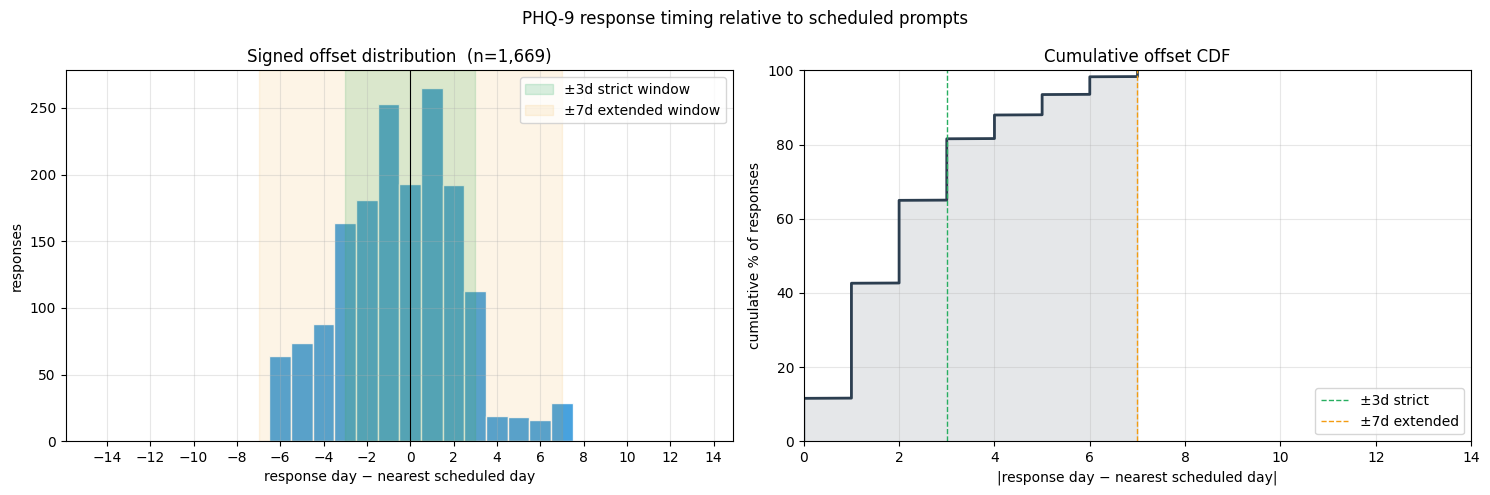

In [60]:
# Component E.2: Exhaustive PHQ-9 check + response-timing diagnostic
# Two parts:
#   (1) Iterate every PHQ-9 row in df_long; recompute the nearest-prompt
#       assignment from raw response data; flag any discrepancies. Confirms
#       Component A's matching logic is correct at scale, not just on the 3
#       sampled rows in Check 1.
#   (2) For every PHQ-9 completion, compute the day-offset to the nearest
#       scheduled prompt. Distribution and histogram show response-timing patterns.

print("=" * 90)
print("COMPONENT E.2 — EXHAUSTIVE PHQ-9 VERIFICATION + response-timing diagnostic")
print("=" * 90)

phq9_resp = df_depression_questionnaire.copy()
if 'complete' in phq9_resp.columns:
    phq9_resp = phq9_resp[phq9_resp['complete'] != False]
phq9_resp = phq9_resp.dropna(subset=['daysSince', 'mm_id'])
phq9_resp['_d'] = phq9_resp['daysSince'].astype(int)
phq9_completions_by_user = phq9_resp.groupby('mm_id')['_d'].apply(set).to_dict()

# Part 1: Exhaustive consistency check
# Manually recompute nearest-prompt assignment per (mm_id, period) and compare
# to df_long's completed column for every PHQ-9 row.
print()
print("--- Part 1: Exhaustive nearest-prompt match across every PHQ-9 row --")
phq9_rows = df_long[df_long['instrument'] == 'PHQ-9'].copy()
print(f"  Total PHQ-9 rows in df_long:       {len(phq9_rows):,}")
print(f"  Participants with PHQ-9 rows:      {phq9_rows['mm_id'].nunique()}")

# Pre-compute manual completed-sets per (mm_id, period) using the same algorithm
# as Component A: filter completions to [0, max_ds], assign each to nearest
# scheduled prompt in the same period.
manual_completed = {}  # (mm_id, period, days_since) -> count
for mm_id in phq9_rows['mm_id'].unique():
    enroll = enrollment_lookup_v2.get(mm_id)
    if enroll is None or enroll['max_days_since'] is None: continue
    max_ds = enroll['max_days_since']
    user_comps = {c for c in phq9_completions_by_user.get(mm_id, set())
                  if 0 <= c <= max_ds}
    user_rows = phq9_rows[phq9_rows['mm_id'] == mm_id]
    bl_dss = sorted(user_rows[user_rows['period']=='baseline']['days_since'].astype(int))
    weekly_slots = sorted(user_rows[(user_rows['period']=='adaptive') &
                                     (user_rows['assigned_cadence']=='weekly')]['days_since'].astype(int))
    monthly_slots = sorted(user_rows[(user_rows['period']=='adaptive') &
                                      (user_rows['assigned_cadence']=='monthly')]['days_since'].astype(int))
    cfg_list = config_by_user.get(mm_id, [])
    weekly_ranges, monthly_ranges = [], []
    for i, cfg in enumerate(cfg_list):
        s = int(cfg['study_day']) - 1
        e = (int(cfg_list[i+1]['study_day']) - 2) if i+1 < len(cfg_list) else max_ds
        e = min(e, max_ds)
        if s > max_ds: continue
        cad = cfg.get('PHQ-9')
        if cad == 'weekly':
            weekly_ranges.append((s, e))
        elif cad == 'monthly':
            monthly_ranges.append((s, e))

    bl_counts, ad_counts = {}, {}
    for c in user_comps:
        if c < 84 and bl_dss:
            n = min(bl_dss, key=lambda d: abs(d - c))
            bl_counts[n] = bl_counts.get(n, 0) + 1
        elif c >= 84:
            in_weekly  = any(s <= c <= e for s, e in weekly_ranges)
            in_monthly = any(s <= c <= e for s, e in monthly_ranges)
            if in_weekly and weekly_slots:
                n = min(weekly_slots, key=lambda d: abs(d - c))
                ad_counts[n] = ad_counts.get(n, 0) + 1
            elif in_monthly and monthly_slots:
                n = min(monthly_slots, key=lambda d: abs(d - c))
                ad_counts[n] = ad_counts.get(n, 0) + 1
            elif weekly_slots or monthly_slots:
                # Orphan rescue: nearest slot of any cadence
                all_slots = weekly_slots + monthly_slots
                n = min(all_slots, key=lambda d: abs(d - c))
                ad_counts[n] = ad_counts.get(n, 0) + 1
    for d in bl_dss:
        manual_completed[(mm_id, 'baseline', d)] = bl_counts.get(d, 0)
    for d in (weekly_slots + monthly_slots):
        manual_completed[(mm_id, 'adaptive', d)] = ad_counts.get(d, 0)

discrepancies = []
for _, r in phq9_rows.iterrows():
    key = (r['mm_id'], str(r['period']), int(r['days_since']))
    manual = manual_completed.get(key, 0)
    if manual != int(r['completed']):
        discrepancies.append({
            'mm_id': r['mm_id'],
            'study_day': int(r['study_day']),
            'days_since': int(r['days_since']),
            'period': str(r['period']),
            'df_long_completed': int(r['completed']),
            'manual_completed': manual,
        })

if not discrepancies:
    print(f"  All {len(phq9_rows):,} PHQ-9 rows match manual recomputation. Logic is exact.")
else:
    print(f"  {len(discrepancies)} discrepancies found (showing first 15):")
    for d in discrepancies[:15]:
        print(f"    {d}")

print()
print("--- Part 2: Response-timing distribution for PHQ-9 ----------------------")

phq9_sched_ds = np.array(sorted(
    [d - 1 for d in sched_days_all['PHQ-9']['baseline']] +
    [d - 1 for d in sched_days_all['PHQ-9']['adaptive_all']]
))

offsets = []
for mm_id, days in phq9_completions_by_user.items():
    enroll = enrollment_lookup_v2.get(mm_id)
    if enroll is None or enroll['max_days_since'] is None:
        continue
    max_ds = enroll['max_days_since']
    for d in days:
        if d < 0 or d > max_ds:
            continue
        nearest_idx = np.argmin(np.abs(phq9_sched_ds - d))
        offsets.append(int(d - phq9_sched_ds[nearest_idx]))

offsets = np.array(offsets)
n = len(offsets)
print(f"  PHQ-9 completions analyzed:        {n:,}")
print(f"  Median offset:                     {int(np.median(offsets))}")
print(f"  Mean |offset|:                     {np.abs(offsets).mean():.2f} days")
print()
print(f"  Cumulative share within window:")
for w in [0, 1, 2, 3, 5, 7, 10, 14]:
    pct = (np.abs(offsets) <= w).mean() * 100
    flag = ' <- strict ±3' if w == 3 else (' <- extended ±7' if w == 7 else '')
    print(f"    ±{w:>2}d: {(np.abs(offsets) <= w).sum():>5,}  ({pct:>5.1f}%){flag}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bins = np.arange(-14, 15) - 0.5
axes[0].hist(np.clip(offsets, -14, 14), bins=bins, edgecolor='white', color='#3498db', alpha=0.9)
axes[0].axvspan(-3, 3, color='#27ae60', alpha=0.18, label='±3d strict window')
axes[0].axvspan(-7, 7, color='#f39c12', alpha=0.10, label='±7d extended window')
axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_xlabel('response day − nearest scheduled day')
axes[0].set_ylabel('responses')
axes[0].set_title(f'Signed offset distribution  (n={n:,})')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(np.arange(-14, 15, 2))

abs_off = np.sort(np.abs(offsets))
cdf_y = np.arange(1, len(abs_off) + 1) / len(abs_off)
axes[1].plot(abs_off, cdf_y * 100, color='#2c3e50', lw=2)
axes[1].axvline(3, color='#27ae60', ls='--', lw=1, label='±3d strict')
axes[1].axvline(7, color='#f39c12', ls='--', lw=1, label='±7d extended')
axes[1].fill_between(abs_off, 0, cdf_y * 100, alpha=0.12, color='#2c3e50')
axes[1].set_xlabel('|response day − nearest scheduled day|')
axes[1].set_ylabel('cumulative % of responses')
axes[1].set_title('Cumulative offset CDF')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='lower right')
axes[1].set_xlim(0, 14)
axes[1].set_ylim(0, 100)

plt.suptitle('PHQ-9 response timing relative to scheduled prompts', fontsize=12)
plt.tight_layout()
plt.show()

print()
print("--- Per-participant: share of completions within strict vs extended window --")
per_user = []
for mm_id, days in phq9_completions_by_user.items():
    if not days: continue
    user_offsets = []
    for d in days:
        if d < 0: continue
        idx = np.argmin(np.abs(phq9_sched_ds - d))
        user_offsets.append(abs(d - phq9_sched_ds[idx]))
    if not user_offsets: continue
    user_offsets = np.array(user_offsets)
    per_user.append({
        'mm_id': mm_id,
        'n_completions': len(user_offsets),
        'pct_within_3d': (user_offsets <= 3).mean() * 100,
        'pct_within_7d': (user_offsets <= 7).mean() * 100,
    })
df_user_offsets = pd.DataFrame(per_user)
print(f"  Median per-participant share within ±3d: {df_user_offsets['pct_within_3d'].median():.1f}%")
print(f"  Median per-participant share within ±7d: {df_user_offsets['pct_within_7d'].median():.1f}%")
print(f"  Participants with <50% of responses within ±3d: "
      f"{(df_user_offsets['pct_within_3d'] < 50).sum()} / {len(df_user_offsets)}")
print(f"  Participants with 100% of responses within ±7d:  "
      f"{(df_user_offsets['pct_within_7d'] == 100).sum()} / {len(df_user_offsets)}")

print()
print("=" * 90)
print("Interpretation guide:")
print("  - Bimodal histogram (peak at 0 + a second peak at +5 to +7) -> app likely")
print("    had a wider response window than ±3d; strict definition under-counts")
print("    legitimate late completions. Recommend confirming protocol response window.")
print("  - Unimodal at 0 with thin tails -> ±3d is appropriate; off-window responses")
print("    are sparse self-initiated submissions.")
print("  - Roughly uniform within ±14 -> self-initiated behavior dominates; permissive")
print("    definition is engagement, not adherence.")
print("=" * 90)

### E.3 — Audit for app bugs / multi-submission / ahead-of-schedule

Tests whether the strict/permissive gap is partly driven by (a) same-day duplicate submissions (potential app bug), (b) multiple submissions clustered within ±3d of one scheduled prompt, or (c) ahead-of-schedule completions. Operates on raw PHQ-9 response data.

In [61]:
# Component E.3: Same-day / multi-submission / ahead-of-schedule audit
# Hypothesis to test: the strict-vs-permissive gap on PHQ-9 is partly driven by
# an app bug or user-side behavior where the same scheduled prompt is satisfied
# by multiple submissions (same day or clustered ±3d), or where users submitted
# ahead of schedule.
#
# Four checks on raw PHQ-9 response data:
#   A. Same-day duplicates  — multiple records on the same (mm_id × daysSince)
#   B. Multi-submission clusters — how many distinct completion days fall
#      within ±3d of each scheduled prompt
#   C. Ahead-of-schedule completions — submissions before their nearest prompt
#   D. Pre-first-prompt completions — submissions before any scheduled prompt

print("=" * 90)
print("COMPONENT E.3 — Same-day / multi-submission / ahead-of-schedule audit (PHQ-9)")
print("=" * 90)

phq9_raw = df_depression_questionnaire.copy()
if 'complete' in phq9_raw.columns:
    phq9_raw = phq9_raw[phq9_raw['complete'] != False]
phq9_raw = phq9_raw.dropna(subset=['daysSince', 'mm_id']).copy()
phq9_raw['_d'] = phq9_raw['daysSince'].astype(int)

print(f"\nTotal PHQ-9 response records (raw, post 'complete' filter): {len(phq9_raw):,}")
print(f"Distinct (mm_id, daysSince) pairs:                          "
      f"{phq9_raw[['mm_id','_d']].drop_duplicates().shape[0]:,}")
print(f"Difference (= duplicate same-day records):                  "
      f"{len(phq9_raw) - phq9_raw[['mm_id','_d']].drop_duplicates().shape[0]:,}")

print()
print("--- Check A: Same-day duplicate submissions --------------------------")
dup_per_day = phq9_raw.groupby(['mm_id', '_d']).size().reset_index(name='n_submissions')
multi_day = dup_per_day[dup_per_day['n_submissions'] > 1]

print(f"  Total (mm_id × day) pairs:                  {len(dup_per_day):,}")
print(f"  Pairs with >1 submission (duplicates):      {len(multi_day):,} "
      f"({len(multi_day)/len(dup_per_day)*100:.1f}%)")
print(f"  Pairs with ≥3 submissions on same day:      {(multi_day['n_submissions'] >= 3).sum()}")
print(f"  Max submissions on a single day:            {dup_per_day['n_submissions'].max()}")
print(f"  Participants with ≥1 same-day duplicate:    "
      f"{multi_day['mm_id'].nunique()} / {phq9_raw['mm_id'].nunique()}")

if len(multi_day) > 0:
    print()
    print("  Top 10 (mm_id × day) pairs with most submissions:")
    top = multi_day.sort_values('n_submissions', ascending=False).head(10)
    for _, r in top.iterrows():
        print(f"    mm_id={r['mm_id']}  daysSince={int(r['_d']):>4}  "
              f"submissions={int(r['n_submissions'])}")

print()
print("--- Check B: Distinct completion days within ±3d of each scheduled prompt --")
phq9_sched_ds = np.array(sorted(
    [d - 1 for d in sched_days_all['PHQ-9']['baseline']] +
    [d - 1 for d in sched_days_all['PHQ-9']['adaptive_all']]
))

phq9_completions_by_user = (phq9_raw.groupby('mm_id')['_d'].apply(set).to_dict())
cluster_rows = []
for mm_id, days_set in phq9_completions_by_user.items():
    enroll = enrollment_lookup_v2.get(mm_id)
    if enroll is None or enroll['max_days_since'] is None: continue
    max_ds = enroll['max_days_since']
    for sd in phq9_sched_ds:
        if sd > max_ds: break
        n_within = sum(1 for d in days_set if abs(d - sd) <= 3 and 0 <= d <= max_ds)
        cluster_rows.append({'sched_ds': int(sd), 'n_within_3d': n_within})

clusters_df = pd.DataFrame(cluster_rows)
dist = clusters_df['n_within_3d'].value_counts().sort_index()
total = len(clusters_df)
print(f"  Total scheduled prompt instances examined: {total:,}")
print(f"  Distribution of distinct completion days within ±3d of each prompt:")
for n_val, count in dist.items():
    print(f"    {int(n_val)} completion day(s) within ±3d:  {count:>5,}  ({count/total*100:>5.1f}%)")
print(f"  Mean distinct completion days per scheduled prompt: "
      f"{clusters_df['n_within_3d'].mean():.2f}")
print()
print("  Interpretation: if many prompts have 2+ distinct completion days within their")
print("  ±3d window, the permissive definition is 'rewarding' those repeats while strict")
print("  caps at one. This contributes to the strict-vs-permissive gap.")

print()
print("--- Check C: Signed offset of completions to nearest scheduled prompt --")
print("  (Negative = submitted before scheduled day; positive = after)")
signed = []
for mm_id, days_set in phq9_completions_by_user.items():
    enroll = enrollment_lookup_v2.get(mm_id)
    if enroll is None or enroll['max_days_since'] is None: continue
    max_ds = enroll['max_days_since']
    for d in days_set:
        if d < 0 or d > max_ds: continue
        idx = np.argmin(np.abs(phq9_sched_ds - d))
        signed.append(int(d - phq9_sched_ds[idx]))
signed = np.array(signed)

before = (signed < 0).sum(); on  = (signed == 0).sum(); after = (signed > 0).sum()
print(f"  Total completions analyzed:           {len(signed):,}")
print(f"  Before nearest scheduled day  (<0):   {before:,}  ({before/len(signed)*100:.1f}%)")
print(f"  On nearest scheduled day      (= 0):  {on:,}  ({on/len(signed)*100:.1f}%)")
print(f"  After nearest scheduled day   (>0):   {after:,}  ({after/len(signed)*100:.1f}%)")
print(f"  Median signed offset: {int(np.median(signed))}")
print(f"  Mean signed offset:   {signed.mean():+.2f} days")

print()
print("--- Check D: Edge-case timing anomalies ------------------------------")
phq9_first = int(phq9_sched_ds[0])
phq9_last  = int(phq9_sched_ds[-1])
pre_first  = phq9_raw[phq9_raw['_d'] < phq9_first]
neg_days   = phq9_raw[phq9_raw['_d'] < 0]
post_last  = []
for mm_id, days_set in phq9_completions_by_user.items():
    for d in days_set:
        if d > phq9_last:
            post_last.append({'mm_id': mm_id, 'daysSince': d})

print(f"  First scheduled PHQ-9 prompt is daysSince {phq9_first} (study_day {phq9_first + 1})")
print(f"  Completions BEFORE first scheduled prompt: {len(pre_first):,} records "
      f"across {pre_first['mm_id'].nunique()} participants")
print(f"  Completions with daysSince < 0 (pre-enroll): {len(neg_days):,}")
print(f"  Completions AFTER last scheduled prompt (study_day {phq9_last + 1}): "
      f"{len(post_last):,}")

if len(pre_first) > 0:
    print()
    print(f"  Sample pre-first-prompt records:")
    print(pre_first[['mm_id', 'daysSince']].head(10).to_string(index=False))

print()
print("=" * 90)
print("E.3 SUMMARY — what's driving the strict/permissive gap?")
print("=" * 90)
dup_share = len(multi_day) / len(dup_per_day) * 100 if len(dup_per_day) else 0
multi_hit_prompts = (clusters_df['n_within_3d'] >= 2).sum() if total else 0
multi_hit_share = multi_hit_prompts / total * 100 if total else 0
extra_within = (clusters_df[clusters_df['n_within_3d'] >= 2]['n_within_3d'] - 1).sum()

print(f"  Same-day duplicate share:            {dup_share:.1f}% of (user×day) pairs")
print(f"  Prompts with ≥2 distinct hits ±3d:   {multi_hit_prompts:,} ({multi_hit_share:.1f}%)")
print(f"  'Extra' completions absorbed by strict (multi-hit prompts beyond first):")
print(f"      {extra_within:,} completion days that count permissive but are merged by strict")
print()
print("  If same-day duplicate share is high (>5%) -> likely an app bug; investigate.")
print("  If multi-hit-prompts share is high -> users responding more than once around a")
print("    single prompt; permissive double-counts these. Not a bug per se, but explains gap.")
print("  If both are low and the offset distribution from E.2 is bimodal -> app's actual")
print("    response window was likely wider than ±3d.")

COMPONENT E.3 — Same-day / multi-submission / ahead-of-schedule audit (PHQ-9)

Total PHQ-9 response records (raw, post 'complete' filter): 19,829
Distinct (mm_id, daysSince) pairs:                          2,074
Difference (= duplicate same-day records):                  17,755

--- Check A: Same-day duplicate submissions --------------------------
  Total (mm_id × day) pairs:                  2,074
  Pairs with >1 submission (duplicates):      2,074 (100.0%)
  Pairs with ≥3 submissions on same day:      2074
  Max submissions on a single day:            20
  Participants with ≥1 same-day duplicate:    302 / 302

  Top 10 (mm_id × day) pairs with most submissions:
    mm_id=200  daysSince=  -9  submissions=20
    mm_id=213  daysSince= -11  submissions=20
    mm_id=233  daysSince=  47  submissions=20
    mm_id=237  daysSince=  -7  submissions=20
    mm_id=212  daysSince= -11  submissions=20
    mm_id=138  daysSince=  -3  submissions=20
    mm_id=74  daysSince=  -4  submissions=20
    mm